In [3]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# change current working directory
import os
os.chdir('/content/drive/MyDrive/AI/1CWK100/')

In [5]:
# check we can see the dataset
os.path.isfile('pneumonia_raw.csv')

True

# Task 1

## Basic structure

Please use the structure below as your starting point. Once you are up and running then you are free to adjust it, but try to stick to the following basic approach: i) divide your investigation up into smaller code cells; ii) have text cells above each code cell briefly describing what is happening in the code, along with any relevant findings it produces.

Relatively quickly, you should be able to reuse some code from the labs to prepare the assignment dataset and evaluate at least one model with a basic holdout recipe. This would get you a pass. Ask for help if you're struggling, and read the later sections once you're ready to start aiming for higher marks. Good luck!

# cleaning data for preparation

This section reperesents the process of cleanning the data to be used for trainning and testing the models. In the output you can see that we have droped the Patient_ID and taken out errors of numercail data. In addttion to this we have droped duplicate values and missing values.



In [7]:
#data cleanning section
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
observations = pd.read_csv('pneumonia_raw.csv')
observations_cleaning = pd.DataFrame(observations) # set the data in a new varible
observations_cleaning = observations_cleaning.dropna() # drops null valus
observations_cleaning = observations_cleaning.drop_duplicates() # drops duplicate valurs
observations_cleaning = observations_cleaning.drop(columns='Patient_ID') # drops Patient_ID colume
observations_cleaning = observations_cleaning[observations_cleaning['Max_Consolidation_Width'] >= 0] # gets ride of values less than 0
observations_cleaning = observations_cleaning[observations_cleaning['Max_Consolidation_Height'] >= 0] # gets ride of values less than 0
observations_cleaning['Pneumonia'] = observations_cleaning['Pneumonia'].replace('np', 'no') # replaces typos
observations_cleaning['Pneumonia'] = observations_cleaning['Pneumonia'].replace({'no':0, 'yes': 1}) # converts categorical labels to binary values
#displayes the clean data
print(observations_cleaning.info())
print(observations_cleaning.describe())
print(observations_cleaning.shape)
print(observations_cleaning['Pneumonia'].value_counts())
print("--------------------OLD OBSERVATION DATA AT THE BOTTOM---------------------------------")
#displayes unclean data
print(observations.info())
print(observations.describe())
print(observations.shape)
print(observations['Pneumonia'].value_counts())



<class 'pandas.core.frame.DataFrame'>
Index: 581 entries, 0 to 583
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_Age               581 non-null    int64  
 1   Male                      581 non-null    float64
 2   Xray_Brightness           581 non-null    float64
 3   Xray_Contrast             581 non-null    float64
 4   Silhouette_Sign           581 non-null    int64  
 5   Max_Consolidation_Width   581 non-null    int64  
 6   Max_Consolidation_Height  581 non-null    int64  
 7   Cavity_Presence           581 non-null    float64
 8   Fluid_Level               581 non-null    float64
 9   Air_Bronchograms          581 non-null    float64
 10  Pneumonia                 581 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 54.5 KB
None
       Patient_Age        Male  Xray_Brightness  Xray_Contrast  \
count   581.000000  581.000000       581.000000     581.000000 

/tmp/ipython-input-2837733058.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observations_cleaning['Pneumonia'] = observations_cleaning['Pneumonia'].replace({'no':0, 'yes': 1}) # converts categorical labels to binary values


**The reason this was implemented:** The reason that we implemented clean data to is so we eliminate noise, numerical errors, duplicates, and missing values, which can cause setbacks to the model's overall accuracy. By pre-processing the data, the models have a higher chance of producing higher accuracy.

## Dataset preparation
Example text: The following code prepares the data using a simple 60/40 holdout approach with shuffling.

In [8]:
# data preparation steps

# Importing the packages we use
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
# ...
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

# ...
target_feature = 'Pneumonia'
# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True,
    #stratify= labels
)


## Model 1: evaluation (DecisionTreeClassifier)
Example text: The following code cell evaluates a Decision Tree model. The resulting [insert name of performance metric] is ##.

Answer: the follwoing code cell evaluates Decision Tree classifer  modle. This gave an  accuracy of 0.564 or (56.4%).  

**Note that completing these first two sections ("Dataset preparation" and "Model 1 evaluation") would be enough for a pass mark :)**

In [ ]:

model = DecisionTreeClassifier(random_state=99)
# <Fit the model to our training data>
model.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = model.predict(test_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.5641025641025641 (or 56.4 %)


## Stratified sampling with validation and clean data for DecisionTreeClassifier Model

The code cell calculates and evaluates a DecisionTreeClassifier that implements validation, stratifying and cleaning data with the additional 60/20 split and shuffle, resulting in an accuracy of 0.647 or (64.7%).


In [ ]:

# Importing the packages we use
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
# ...
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

# ...
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)
model = DecisionTreeClassifier(random_state=99)
# <Fit the model to our training data>
model.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = model.predict(validate_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(validate_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.646551724137931 (or 64.7 %)


**The reason this was implemented:** The reason this was implemented is that we used stratified sampling, as it allows us to preserve the different labels across both partitions by dividing the examples based on their associated labels. Additionally, this was implemented because the dataset is unbalanced, with a disproportionate number of instances labelled with one particular label.

Additionally, validation was implemented so that we can prevent data leaks. Therefore, these are the reasons we had to implement stratified sampling and validation into the model recipe.

## Pipeline for DecisoinTreeclassifier

The code cell calculates and evaluates a DecisionTreeClassifier that implements pipline with the additional 60/20 split and shuffle, resulting in an accuracy of 0.65 or (65.0%).

In [ ]:
# Evaluate model 1(DecisionTreeClassifier)(pipline):

pipeline = Pipeline([('scaler', StandardScaler()), ('model',DecisionTreeClassifier(random_state=99))])
#model = DecisionTreeClassifier(random_state=99)
# <Fit the model to our training data>
pipeline.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = pipeline.predict(test_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")
# ...

Accuracy: 0.6495726495726496 (or 65.0 %)


**The reason this was implemented:**  Pipeline was implemented is that it allows us to chain together data preprocessing steps, such as StandardScaler, with the models. Furthermore, the pipeline prevents data leakage by allowing transformation to be learned only from the training data, as data leakage can make a model unreliable in real-world scenarios.


##K-fold cross-validation for DecisionTreeClassifier

The code cell calculates and evaluates a DecisionTreeClassifier that implements validation, K-fold cross-validation (5 folds), and cleaned data, together with an 80/20 split and shuffling, resulting in an average accuracy of 0.625 (62.5%).

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True
    #stratify=labels  # notice the new final argument
)
# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds,
skf = StratifiedKFold(n_splits=5)
# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

model = DecisionTreeClassifier(random_state=99)
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.56989247 0.70967742 0.6344086  0.55913978 0.65217391]
Average accuracy: 0.625 (or 62.5%)


**The reason this was implemented:** The reason K-fold cross-validation was implemented is that it is more robust and reliable, as it allows the model to generalise well to unseen data by ensuring each example/label pair is equally important in both training and validation of the models.

##  Pipeline and Validation, and stratifying with clean data in the decision tree model with K-fold cross-validation

The code cell calculates and evaluates a DecisionTreeClassifier that implements validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying together with an 80/20 split and shuffling, resulting in an average accuracy of 0.651 (65.1%).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")





[0.58064516 0.65591398 0.68817204 0.62365591 0.70652174]
Average accuracy: 0.651 (or 65.1%)


## Precision and Recall Score for DecisionTreeClassifier

The following shows the Precision and recall scores for the decision tree classifier.The precision score indcates that 80% of the modles 'yes' predictions were correct.

The Recall score correctly idetrified  73% of the actual yes cases.



In [ ]:
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (e.g., "1")
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")


Precision: 0.80
Recall Score: 0.73


**The reason this was implemented:** The reason precision and recall were implemented is that precision measures, out of all the predicted positives the model has found, how many are actually positive. This is necessary in the recipe, as accuracy does not show how many of the positive cases were predicted correctly.

 In contrast, recall represents the percentage of positives we correctly identified. This is important because accuracy does not necessarily indicate the number of positives that have been identified. This demonstrates why precision and recall are essential metrics within the recipe.

## Visualisation of the Confusion Matrix for DecisionTreeClassifier

This is the confusion matrix of the final version of the base DecisionTreeClassifier model with the implementation of pipeline, K-fold cross-validation (5-fold),stratifying, clean data, and validation.

**The reason this was implemented:** The reason the confusion matrix is being implemented is to assess the model's prediction accuracy, as accuracy alone is not enough to account for any of the false positives or false negatives that the confusion matrix can show. This critical information tells us if the model's accuracy is genuinely reliable for our model or if it is genuinely a misleading accuracy. Furthermore, it gives us insight into any imbalanced data, as accuracy normally gives a high figure accuracy when it's unbalanced, which a confusion matrix can find with tools such as precision and recall score.




Confusion Matrix:
[[19 15]
 [22 61]]


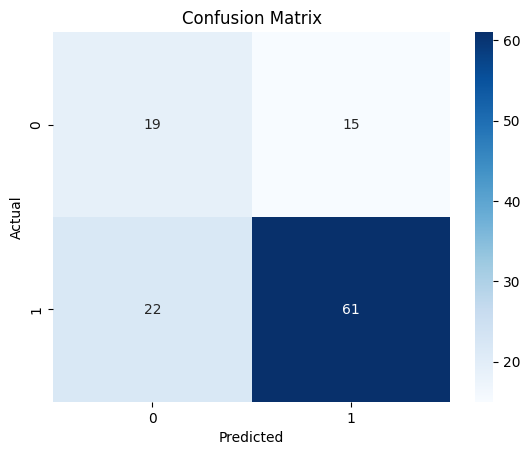

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')



# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

As we can see confusion matrix shows that the model correctly predicted 61 negative cases and 19 positive cases. It also misclassified 22 positive cases as negative and 15 negative cases as positive. Overall, the model performs better at identifying negative cases than positive ones.

## Visualisation of the ROC curve for DecisionTreeClassifier

 Below is the percentage accurcy  of the ROC curve for the DecisonTreeClassifier.

This is the ROC of the final version of the DecisionTree classifier with a ROC accuracy score of 0.65. is this correct for the powerpoint

-------------------------------------------------------------------
ROC AUC: 0.65


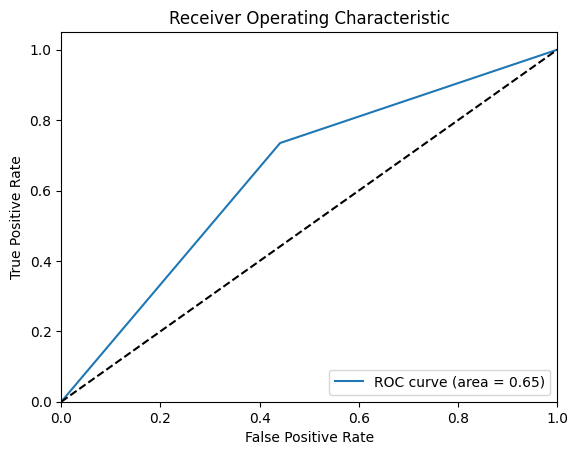

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
print("-------------------------------------------------------------------")
# Generate predicted probabilities for the positive class
pipeline.fit(non_test_examples,non_test_labels) # fitting the 20% testing for finding the ROC curve
y_prob = pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.2f}")
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

Here, we can see that the ROC curve of the Decision Tree is at 0.65. This means that the model is not guessing but is still underperforming in general.

**The reason this was implemented:** The reason the ROC curve is implemented is that it focuses on finding errors by comparing the performance of two classes by plotting true positive and false positive rates on the graph at different intervals. However, accuracy does not indicate the true positive or false positive rate, because it only shows the proportion of correct predictions, which is why the ROC curve is an important addition to the recipe.

# Investigating Hyperparameter settings for DecisionTreeClassifier (min_samples_split)



The code cell calculates and evaluates a DecisionTreeClassifier using a min_samples_split hyperparameter and a 60/40 split with shuffle, resulting in the highest accuracy of 68% when min_samples_split was between 80 and 100.

Accuracy: 0.5598290598290598 (or 56.0 %)
Accuracy: 0.5854700854700855 (or 58.5 %)
Accuracy: 0.5769230769230769 (or 57.7 %)
Accuracy: 0.5769230769230769 (or 57.7 %)
Accuracy: 0.5769230769230769 (or 57.7 %)
Accuracy: 0.6111111111111112 (or 61.1 %)
Accuracy: 0.6153846153846154 (or 61.5 %)
Accuracy: 0.6025641025641025 (or 60.3 %)
Accuracy: 0.6367521367521367 (or 63.7 %)
Accuracy: 0.6410256410256411 (or 64.1 %)
Accuracy: 0.6410256410256411 (or 64.1 %)
Accuracy: 0.6410256410256411 (or 64.1 %)
Accuracy: 0.6410256410256411 (or 64.1 %)
Accuracy: 0.6410256410256411 (or 64.1 %)
Accuracy: 0.6752136752136753 (or 67.5 %)
Accuracy: 0.6752136752136753 (or 67.5 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.6794871794871795 (or 67.9 %)


Text(0, 0.5, 'Accuracy in %')

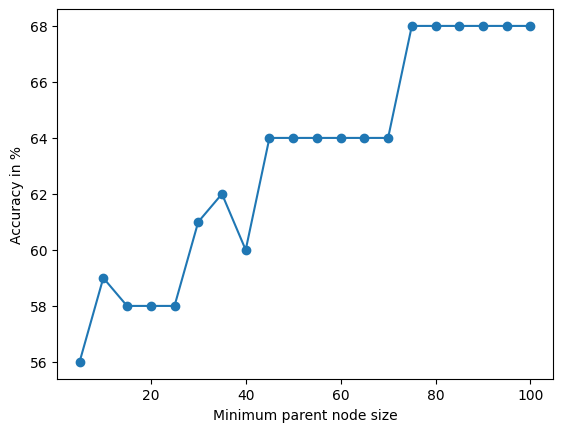

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
# Define the range of hyperparameter values we're interested in
min_parent_sizes = list(range(5, 101, 5))
# And a list to hold the resulting accuracies
accuracies = []

# Create a decision tree classifier model object
model = DecisionTreeClassifier(random_state=99)
for min_parent_size in min_parent_sizes:

  # Change the minimum parent size
  model.set_params(min_samples_split=min_parent_size)


  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(test_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(test_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100))

# Show evaluation results graphically
plt.figure()
plt.plot(min_parent_sizes, accuracies, marker='o', linestyle='-')
plt.xlabel('Minimum parent node size')
plt.ylabel('Accuracy in %')


## Investigating Hyperparameter settings for DecisionTreeClassifier (min_samples_split) with clean data, validation, and stratifying.

This shows the percentage accuracy calculated at different minimum parent node sizes with the implementation of clean data, validation, stratification and shuffle. The highest accuracy, around 75%, was observed between 40 and 100.

Accuracy: 0.5258620689655172 (or 52.6 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.5689655172413793 (or 56.9 %)
Accuracy: 0.5689655172413793 (or 56.9 %)
Accuracy: 0.5689655172413793 (or 56.9 %)
Accuracy: 0.5689655172413793 (or 56.9 %)
Accuracy: 0.5689655172413793 (or 56.9 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.5689655172413793 (or 56.9 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.5689655172413793 (or 56.9 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)


Text(0, 0.5, 'Accuracy in %')

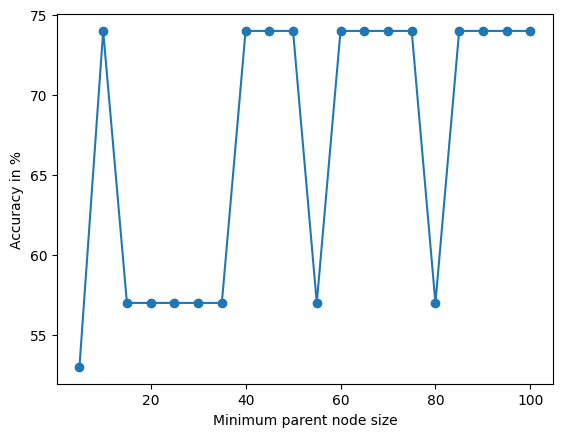

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)

scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
# Define the range of hyperparameter values we're interested in
min_parent_sizes = list(range(5, 101, 5))
# And a list to hold the resulting accuracies
accuracies = []

# Create a decision tree classifier model object
model = DecisionTreeClassifier(random_state=99)
for min_parent_size in min_parent_sizes:

  # Change the minimum parent size
  model.set_params(min_samples_split=min_parent_size)


  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(validate_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100))

# Show evaluation results graphically
plt.figure()
plt.plot(min_parent_sizes, accuracies, marker='o', linestyle='-')
plt.xlabel('Minimum parent node size')
plt.ylabel('Accuracy in %')

## Investigating Hyperparameter settings for DecisionTreeClassifier (min_samples_split) with pipeline.

This shows the percentage accuracy calculated at different minimum parent node sizes with the implementation of the pipeline and shuffle, with the highest accuracy, around 68%, observed between 80 and 100.

Accuracy: 0.5598290598290598 (or 56.0 %)
Accuracy: 0.5854700854700855 (or 58.5 %)
Accuracy: 0.5769230769230769 (or 57.7 %)
Accuracy: 0.5769230769230769 (or 57.7 %)
Accuracy: 0.5769230769230769 (or 57.7 %)
Accuracy: 0.6111111111111112 (or 61.1 %)
Accuracy: 0.6153846153846154 (or 61.5 %)
Accuracy: 0.6025641025641025 (or 60.3 %)
Accuracy: 0.6367521367521367 (or 63.7 %)
Accuracy: 0.6410256410256411 (or 64.1 %)
Accuracy: 0.6410256410256411 (or 64.1 %)
Accuracy: 0.6410256410256411 (or 64.1 %)
Accuracy: 0.6410256410256411 (or 64.1 %)
Accuracy: 0.6410256410256411 (or 64.1 %)
Accuracy: 0.6752136752136753 (or 67.5 %)
Accuracy: 0.6752136752136753 (or 67.5 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.6794871794871795 (or 67.9 %)


Text(0, 0.5, 'Accuracy in %')

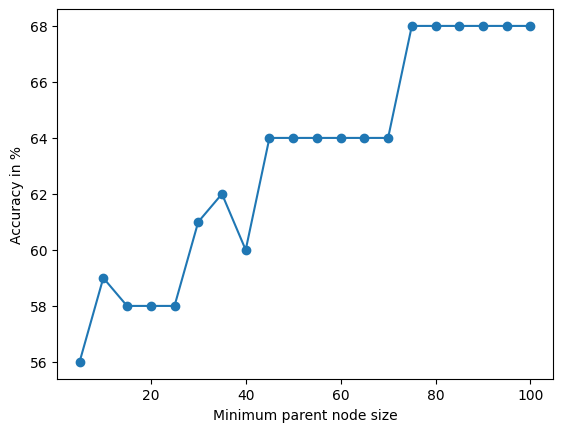

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True,
)

# Define the range of hyperparameter values we're interested in
min_parent_sizes = list(range(5, 101, 5))
# And a list to hold the resulting accuracies
accuracies = []

# Create a decision tree classifier model object
pipeline = Pipeline([('scaler', StandardScaler()), ('model',DecisionTreeClassifier(random_state=99))])
#model = DecisionTreeClassifier(random_state=99)
for min_parent_size in min_parent_sizes:

  # Change the minimum parent size
  pipeline.set_params(model__min_samples_split=min_parent_size)


  # Fit the model to our training data
  pipeline.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = pipeline.predict(test_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(test_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100))

# Show evaluation results graphically
plt.figure()
plt.plot(min_parent_sizes, accuracies, marker='o', linestyle='-')
plt.xlabel('Minimum parent node size')
plt.ylabel('Accuracy in %')

## Investigating Hyperparameter settings for DecisionTreeClassifier (min_samples_split) with k-fold cross-validation.


This shows the percentage accuracy calculated at different minimum parent node sizes with the implementation of the K-fold cross valdiation(5 folds) and shuffle, with the highest accuracy, around 70+%, observed between 80 and 100  at fold one.

Average accuracy: 0.621 (or 62.1%)
Average accuracy: 0.587 (or 58.7%)
Average accuracy: 0.593 (or 59.3%)
Average accuracy: 0.608 (or 60.8%)
Average accuracy: 0.600 (or 60.0%)
Average accuracy: 0.606 (or 60.6%)
Average accuracy: 0.617 (or 61.7%)
Average accuracy: 0.636 (or 63.6%)
Average accuracy: 0.634 (or 63.4%)
Average accuracy: 0.640 (or 64.0%)
Average accuracy: 0.657 (or 65.7%)
Average accuracy: 0.659 (or 65.9%)
Average accuracy: 0.662 (or 66.2%)
Average accuracy: 0.653 (or 65.3%)
Average accuracy: 0.651 (or 65.1%)
Average accuracy: 0.653 (or 65.3%)
Average accuracy: 0.666 (or 66.6%)
Average accuracy: 0.666 (or 66.6%)
Average accuracy: 0.666 (or 66.6%)
Average accuracy: 0.689 (or 68.9%)


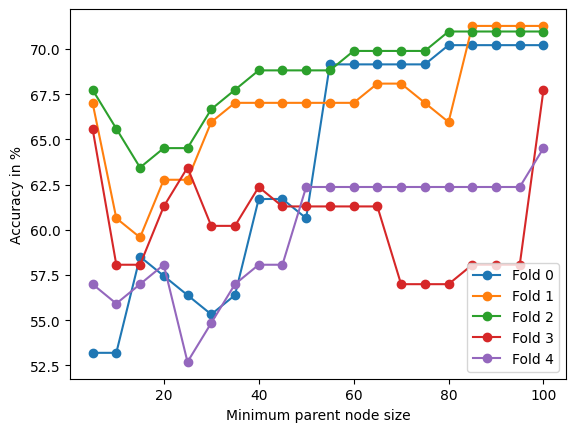

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True
)

min_parent_sizes = list(range(5, 101, 5))
# And a list to hold the resulting accuracies
accuracies_result = []
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
skf = StratifiedKFold(n_splits=5)
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}
# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))
model = DecisionTreeClassifier(random_state=99)

# Create a decision tree classifier model object

for min_parent_size in min_parent_sizes:

  # Change the minimum parent size
  model.set_params(min_samples_split=min_parent_size)
  accuracies = cross_val_score(model,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

  print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

  for fold_i, accuracies_result in enumerate(accuracies):
    fold_accuracies[fold_i].append(accuracies_result * 100)
# Add legend entries for each split
plt.figure()
lines = []
labels = []

for i in number_splits_fold:
    line, = plt.plot(min_parent_sizes,
                     fold_accuracies[i],
                     marker='o',
                     linestyle='-')
    lines.append(line)
    labels.append(f"Fold {i}")

# Show evaluation results graphically
plt.legend(lines, labels, loc="lower right") #
plt.xlabel("Minimum parent node size")
plt.ylabel("Accuracy in %")
plt.show()


## Investigating Hyperparameter settings for DecisionTreeClassifier (min_samples_split) with clean data, validation, stratifying and pipeline and K-fold cross-validation.

This shows the percentage accuracy calculated at different minimum parent node sizes with the implementation of K-fold cross-validation (5 folds), clean data, validation, stratifying, a pipeline, and shuffling. The highest accuracy, around 72%, was observed between 60 and 100 at  fold four.

Average accuracy: 0.664 (or 66.4%)
Average accuracy: 0.632 (or 63.2%)
Average accuracy: 0.612 (or 61.2%)
Average accuracy: 0.616 (or 61.6%)
Average accuracy: 0.638 (or 63.8%)
Average accuracy: 0.647 (or 64.7%)
Average accuracy: 0.638 (or 63.8%)
Average accuracy: 0.638 (or 63.8%)
Average accuracy: 0.642 (or 64.2%)
Average accuracy: 0.638 (or 63.8%)
Average accuracy: 0.640 (or 64.0%)
Average accuracy: 0.647 (or 64.7%)
Average accuracy: 0.647 (or 64.7%)
Average accuracy: 0.651 (or 65.1%)
Average accuracy: 0.647 (or 64.7%)
Average accuracy: 0.640 (or 64.0%)
Average accuracy: 0.640 (or 64.0%)
Average accuracy: 0.636 (or 63.6%)
Average accuracy: 0.638 (or 63.8%)
Average accuracy: 0.640 (or 64.0%)


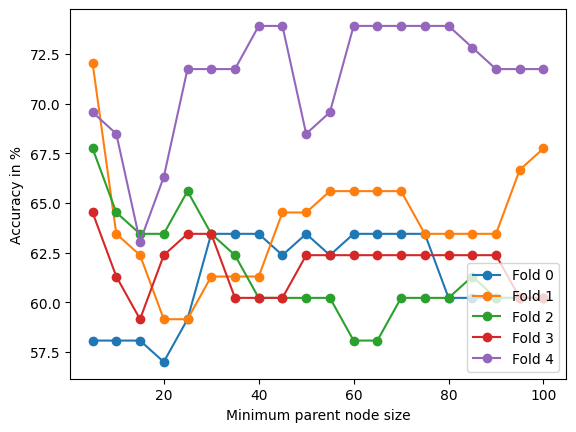

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument

)

min_parent_sizes = list(range(5, 101, 5))
# And a list to hold the resulting accuracies
accuracies_result = []
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
skf = StratifiedKFold(n_splits=5)
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}
# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))
pipeline = Pipeline([('scaler', StandardScaler()), ('model',DecisionTreeClassifier(random_state=99))])

# Create a decision tree classifier model object

for min_parent_size in min_parent_sizes:

  # Change the minimum parent size
  pipeline.set_params(model__min_samples_split=min_parent_size)
  accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

  print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

  for fold_i, accuracies_result in enumerate(accuracies):
    fold_accuracies[fold_i].append(accuracies_result * 100)
# Add legend entries for each split
plt.figure()
lines = []
labels = []

for i in number_splits_fold:
    line, = plt.plot(min_parent_sizes,
                     fold_accuracies[i],
                     marker='o',
                     linestyle='-')
    lines.append(line)
    labels.append(f"Fold {i}")
# Show evaluation results graphically
plt.legend(lines, labels, loc="lower right")
plt.xlabel("Minimum parent node size")
plt.ylabel("Accuracy in %")
plt.show()



##  The Precision and Recall Score  for the DecisionTree classifier Hyperparameter (min_samples_split)

This illustrates the precision and recall scores of the decision tree classifier with the min_samples_split hyperparameter. The recall is at 73%, and the precision is at 80%.

In [ ]:
from sklearn.metrics import precision_score, recall_score
# Calculate precision and recall, specifying the positive class (e.g., "")
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")


Precision: 0.74
Recall Score: 0.87


##Visualisation of the Confusion Matrix for Hyperparameter of the DecisionTree Classifiier

This is the confusion matrix for the min_samples_split hyperparameter of the DecisionTreeClassifier model.



Confusion Matrix:
[[ 9 25]
 [11 72]]


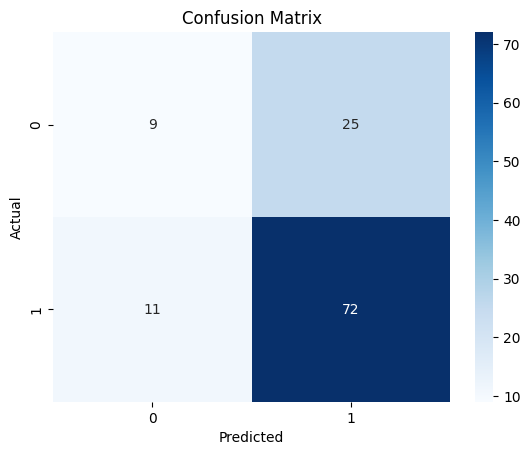

In [ ]:
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument

)

min_parent_sizes = list(range(5, 101, 5))
# And a list to hold the resulting accuracies
accuracies_result = []
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
skf = StratifiedKFold(n_splits=5)
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}
# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(test_examples,test_labels))
pipeline = Pipeline([('scaler', StandardScaler()), ('model',DecisionTreeClassifier(random_state=99))])

# Create a decision tree classifier model object

for min_parent_size in min_parent_sizes:

  # Change the minimum parent size
  pipeline.set_params(model__min_samples_split=min_parent_size)
  accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

  #print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

# Train the model
pipeline.fit(non_test_examples,non_test_labels)

# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix indicates that the model correctly identified 72 true negatives and 9 true positives, which is accurate, as these represent the actual negative and positive cases. Furthermore, it identified 11 as false positives. This is incorrect as they are actually negative cases. At the same time, identifying 25 cases as negative, which are actually positive cases.


## The ROC curve for the DecisionTreeClassifier Hyperparameter

This is the ROC curve of the Decision Tree classifier with hyperparameters of min_sample_split with a ROC score of 0.68.

ROC AUC: 0.68


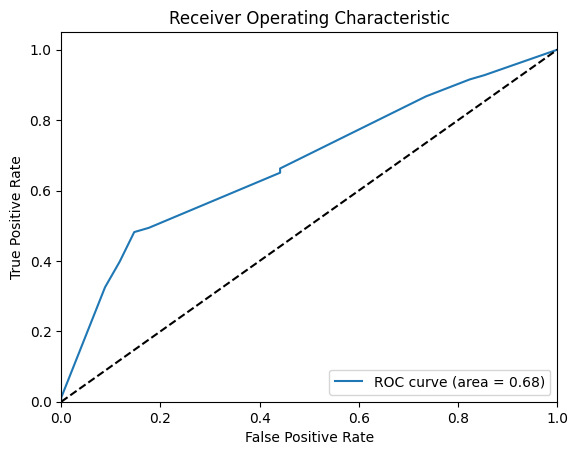

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument

)

min_parent_sizes = list(range(5, 101, 5))
# And a list to hold the resulting accuracies
accuracies_result = []
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
skf = StratifiedKFold(n_splits=5)
# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
pipeline = Pipeline([('scaler', StandardScaler()), ('model',DecisionTreeClassifier(random_state=99))])

# Create a decision tree classifier model object

for min_parent_size in min_parent_sizes:

  # Change the minimum parent size
  pipeline.set_params(model__min_samples_split=min_parent_size)
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

  #print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")
pipeline.fit(non_test_examples,non_test_labels) # fitting the 20% testing for finding the ROC curve
y_prob = pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.2f}")
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is fair. This means that the modle is not guessing but still requires some imporvment.

# Overall conclusion of DecisionTree Classifier model

The overall conclusion of the decision tree is that it is not the best-performing model, as indicated by the ROC Curve for both the baseline DecisionTree and the model with all the included features, which includes validation, clean data, stratification, and K-fold cross-validation. As it performs a 0.65, which is 15% higher than the baseline of 0.5. Furthermore, the Hyperparameter version with the Min_sample_split gives a ROC curve of 0.68. This represents a 3% performance difference between the hyperparameter and the baseline version. Additionally, the model's accuracy, from the base model's was (65.8), compared to the model's final version, with the inclusion of all features to improve the model, was 65.1. This means that there was some unbalanced and unclean data, which contributed to a much higher accuracy score.

In terms of the confusion matrix, the hyperparameter version of the decision tree shows a strong prediction of True negatives (72) and false negatives (25). This indicates that the model's performance was able to classify most of the true negatives, but still classified positive cases as negatives. This suggests that the model works better on negative cases.

Meanwhile, the base model of the decision tree identified most of the true negatives (61) and some of the true positives (19). This also suggests that the model was still identifying positives as negatives and negatives as positives because (22) was identified as a false positive and (15) was identified as a false negative.

# Model 2: evaluation (KNeighbors Classifier Modle)
Example text: The following code cell evaluates a k-Nearest Neighbours model. The resulting [insert name of performance metric] is ##.

Answer: the follwoing base Kneighbors modle code showes an accuracy of  0.66 or (66%)

In [ ]:
# Importing the packages we use
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline


# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# < Shuffle and split into training data (60%) and testing data (40%)>
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
# <Create a KNeighbors Classifier model object>
model = KNeighborsClassifier()
# <Fit the model to our training data>
model.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = model.predict(test_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")
# ...

Accuracy: 0.6709401709401709 (or 67.1 %)


## Stratified sampling with validation and clean data for KNeighbors classifier model

The code cell calculates and evaluates a KNeighbors classifier that implements validation, stratifying and clean data with the additional 80/20 split and shuffle, resulting in an accuracy of 0.716 or (71.6%).

In [ ]:
# Importing the packages we use
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
# ...
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

# ...
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
model = KNeighborsClassifier()
# <Fit the model to our training data>
model.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = model.predict(validate_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(validate_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.7155172413793104 (or 71.6 %)


##testing k-fold cross-validation with validation, stratifying, pipeline, validation and clean data for KNeighbors Classifier Model

The code cell calculates and evaluates a KNeighborsClassifier that implements validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying together with an 80/20 split and shuffling, resulting in an average accuracy of 0.627 (62.7%).

In [ ]:
# SOLUTION
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'


# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies,  one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")
print("---------------")




[0.60215054 0.64516129 0.66666667 0.59139785 0.63043478]
Average accuracy: 0.627 (or 62.7%)
---------------


## The Precision and Recall Score for KNeighbors model

The following shows the Precision and recall scores for the KNeighbors classifier. The precision score indcates that 78% of the modles 'yes' predictions were correct.

The Recall score correctly idetrified  81% of the actual yes cases.

In [ ]:
from sklearn.metrics import precision_score, recall_score
# Calculate precision and recall, specifying the positive class (e.g., "")
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)

precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")


Precision: 0.78
Recall Score: 0.81


## Visualisation of the confusion matrix for  KNeighbors model

This is the confusion matrix of the final version of the base KNeighborsClassifier model with the implementation of pipeline, K-fold cross-validation (5-fold),stratifying, clean data, and validation.

Confusion Matrix:
[[15 19]
 [16 67]]


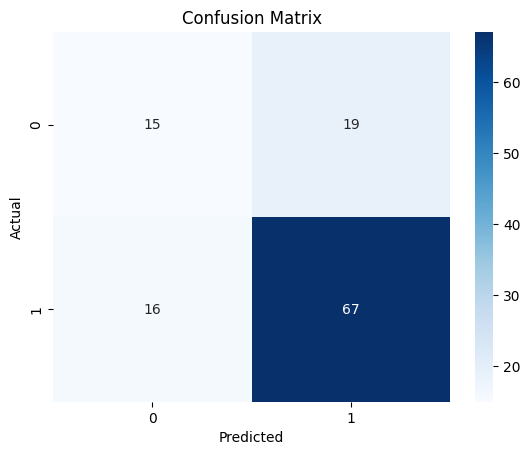

In [ ]:
# Build a pipeline with DecisionTree
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'


# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')


# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the model was able to identify 67 true negatives and 15 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 16 as false positives. This is incorrect as they are negative cases. While identifying 19 cases as negative but they are actually positive cases.

## visualisation of the ROC curve for KNeighbors model

This is the ROC curve of the KNeighborsClassifier with a ROC score of 0.68.

---------------
ROC AUC: 0.68


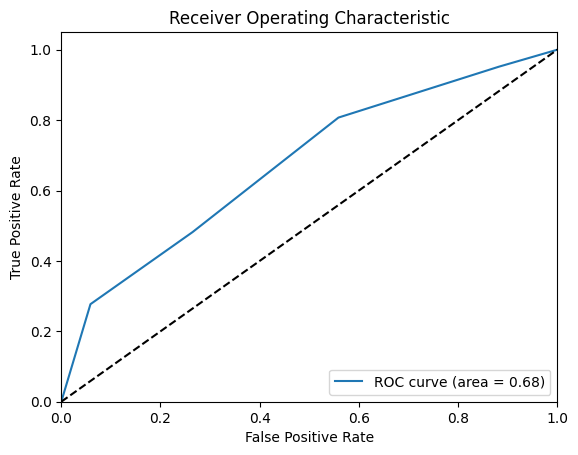

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'


# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies,  one per fold
#print(accuracies)

# Display the average accuracy
#print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")
print("---------------")

# Generate predicted probabilities for the positive class
pipeline.fit(non_test_examples,non_test_labels) # fitting the 20% testing for finding the ROC curve
y_prob = pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.2f}")
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is fair. This means that the modle is not guessing but still requires some imporvment.

# Investigation Hyperparameter for KNeighbors Classifier (n_neighbors)

The code cell calculates and evaluates a KNeighborsClassifier using a n_neighbors hyperparameter and a 60/40 split with shuffle, resulting in the highest accuracy of 72% when K number of neighbors was between 25 and 50.

Accuracy: 0.6581196581196581 (or 65.8 %)
Accuracy: 0.5897435897435898 (or 59.0 %)
Accuracy: 0.6666666666666666 (or 66.7 %)
Accuracy: 0.6196581196581197 (or 62.0 %)
Accuracy: 0.6709401709401709 (or 67.1 %)
Accuracy: 0.6452991452991453 (or 64.5 %)
Accuracy: 0.7008547008547008 (or 70.1 %)
Accuracy: 0.6495726495726496 (or 65.0 %)
Accuracy: 0.6709401709401709 (or 67.1 %)
Accuracy: 0.6752136752136753 (or 67.5 %)
Accuracy: 0.6923076923076923 (or 69.2 %)
Accuracy: 0.6923076923076923 (or 69.2 %)
Accuracy: 0.6923076923076923 (or 69.2 %)
Accuracy: 0.6709401709401709 (or 67.1 %)
Accuracy: 0.6965811965811965 (or 69.7 %)
Accuracy: 0.7094017094017094 (or 70.9 %)
Accuracy: 0.7008547008547008 (or 70.1 %)
Accuracy: 0.7008547008547008 (or 70.1 %)
Accuracy: 0.7094017094017094 (or 70.9 %)
Accuracy: 0.7008547008547008 (or 70.1 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.7051282051282052 (or 70.5 %)
Accuracy: 0.7222222222222222 (or 72.2 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.709401

Text(0, 0.5, 'Accuracy in %')

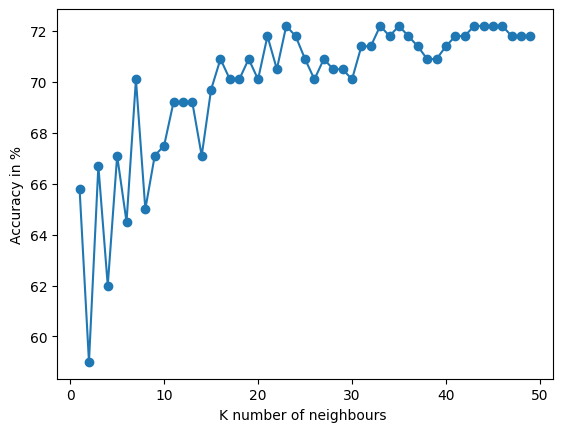

In [ ]:
# Importing the packages we use
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# < Shuffle and split into training data (60%) and testing data (40%)>
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

accuracies = []
number_of_n_neighbors = list(range(1,50));  # Define the range of hyperparameter values we're interested in

for k in number_of_n_neighbors:
  # <Create a KNeighbors Classifier model object>
   model = KNeighborsClassifier()

   model.set_params(n_neighbors = k)
   # Fit the model to our training data
   model.fit(train_examples, train_labels)
   # Use the model to generate predictions for our testing examples
   predictions = model.predict(test_examples)
   # Calculate the model's accuracy - the fraction of predictions that were correct
   accuracy = accuracy_score(test_labels, predictions)
   print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")
   accuracies.append(round(accuracy*100,1))
#plot the graph of resulets:
plt.figure()
plt.plot(number_of_n_neighbors, accuracies, marker='o', linestyle='-')
plt.xlabel('K number of neighbours ')
plt.ylabel('Accuracy in %')

## Investigation Hyperparameter for KNeighbors Classifier (n_neighbors) with clean and Validation and stratifying of data

This shows the percentage accuracy calculated at different K numbers of neighbours for the KNeighborsClassifier model, with the implementation of clean data, validation, stratification, and shuffling. The highest accuracy, around 74%, was observed between 20 and 30.

Accuracy: 0.646551724137931 (or 64.7 %)
Accuracy: 0.5862068965517241 (or 58.6 %)
Accuracy: 0.6551724137931034 (or 65.5 %)
Accuracy: 0.6120689655172413 (or 61.2 %)
Accuracy: 0.6810344827586207 (or 68.1 %)
Accuracy: 0.6724137931034483 (or 67.2 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.6810344827586207 (or 68.1 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.6896551724137931 (or 69.0 %)
Accuracy: 0.6896551724137931 (or 69.0 %)
Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.71551

Text(0, 0.5, 'Accuracy in %')

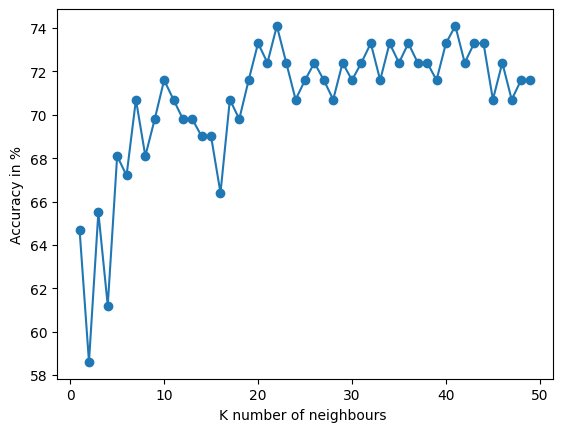

In [ ]:
# Importing the packages we use
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)


scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

validate_examples = scaler.transform(validate_examples)
test_examples     = scaler.transform(test_examples)

accuracies = []
number_of_n_neighbors = list(range(1,50));  # Define the range of hyperparameter values we're interested in


for k in number_of_n_neighbors:
  # <Create a KNeighbors Classifier model object>
   model = KNeighborsClassifier()
   model.set_params(n_neighbors = k)
   # Fit the model to our training data
   model.fit(train_examples, train_labels)
   # Use the model to generate predictions for our testing examples
   predictions = model.predict(validate_examples)
   # Calculate the model's accuracy - the fraction of predictions that were correct
   accuracy = accuracy_score(validate_labels, predictions)
   print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")
   accuracies.append(round(accuracy*100,1))
#plot the graph of resulets:
plt.figure()
plt.plot(number_of_n_neighbors, accuracies, marker='o', linestyle='-')
plt.xlabel('K number of neighbours ')
plt.ylabel('Accuracy in %')

## Investigation of Hyperparameter for KNeighbors Classifier (n_neighbors) with k-fold cross validation and validation, stratifying and clean data with a pipeline


This shows the percentage accuracy calculated at different K numbers of neighbours for the KNeighborsClassifier, with the implementation of K-fold cross-validation (5 folds), clean data, validation, stratifying, a pipeline, and shuffling. The highest accuracy, around 80%, was observed between 10 and 20 at fold zero.

Average accuracy: 0.675 (or 67.5%)
Average accuracy: 0.591 (or 59.1%)
Average accuracy: 0.627 (or 62.7%)
Average accuracy: 0.582 (or 58.2%)
Average accuracy: 0.627 (or 62.7%)
Average accuracy: 0.608 (or 60.8%)
Average accuracy: 0.629 (or 62.9%)
Average accuracy: 0.614 (or 61.4%)
Average accuracy: 0.655 (or 65.5%)
Average accuracy: 0.647 (or 64.7%)
Average accuracy: 0.668 (or 66.8%)
Average accuracy: 0.644 (or 64.4%)
Average accuracy: 0.677 (or 67.7%)
Average accuracy: 0.657 (or 65.7%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.668 (or 66.8%)
Average accuracy: 0.709 (or 70.9%)
Average accuracy: 0.690 (or 69.0%)
Average accuracy: 0.709 (or 70.9%)
Average accuracy: 0.705 (or 70.5%)
Average accuracy: 0.716 (or 71.6%)
Average accuracy: 0.703 (or 70.3%)
Average accuracy: 0.715 (or 71.5%)
Average accuracy: 0.698 (or 69.8%)
Average accuracy: 0.718 (or 71.8%)
Average accuracy: 0.715 (or 71.5%)
Average accuracy: 0.720 (or 72.0%)
Average accuracy: 0.728 (or 72.8%)
Average accuracy: 0.

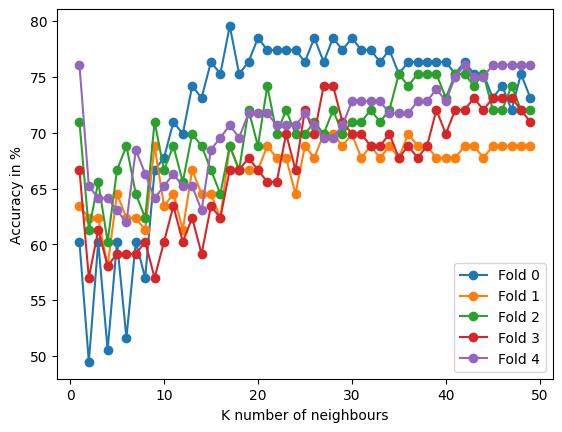

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)

number_of_n_neighbors = list(range(1,50));  # Define the range of hyperparameter values we're interested in
# And a list to hold the resulting accuracies
accuracies_result = []
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
skf = StratifiedKFold(n_splits=5)
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}
# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))
# Create a decision tree classifier model object with pipline
pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])



for k in number_of_n_neighbors:

  # Change the minimum parent size
  pipeline.set_params(model__n_neighbors = k)
  accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

  print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")




  for fold_i, accuracies_result in enumerate(accuracies):
    fold_accuracies[fold_i].append(accuracies_result * 100)
# Add legend entries for each split
plt.figure()
lines = []
labels = []

for i in number_splits_fold:
    line, = plt.plot(number_of_n_neighbors,
                     fold_accuracies[i],
                     marker='o',
                     linestyle='-')
    lines.append(line)
    labels.append(f"Fold {i}")
# Show evaluation results graphically
plt.legend(lines, labels, loc="lower right")
plt.xlabel("K number of neighbours")
plt.ylabel("Accuracy in %")
plt.show()




## The Precision and Recall Score for KNeighbors Hyperparameter Model

This illustrates the precision and recall scores of the KNeighborsClassifier with the n_neighbors hyperparameter. The recall is at 94%, and the precision is at 72%.

In [ ]:
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)

# Calculate precision and recall, specifying the positive class (e.g., "")
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")


Precision: 0.72
Recall Score: 0.94


## The Confusion matrix for KNeighborsClassifier Hyperparameter

This is the confusion matrix for the n_neighbors hyperparameter of the KNeighborsClassifier model.

Confusion Matrix:
[[ 3 31]
 [ 3 80]]


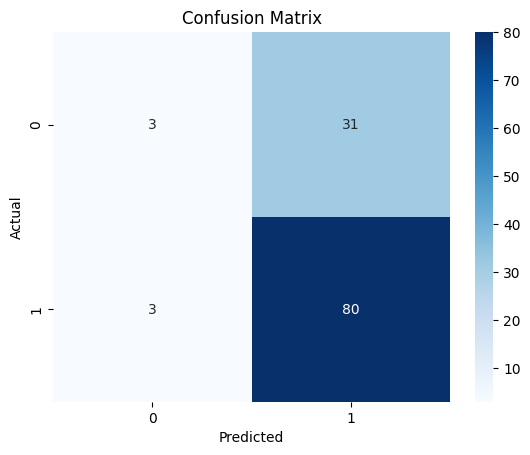

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)

number_of_n_neighbors = list(range(1,50));  # Define the range of hyperparameter values we're interested in
# And a list to hold the resulting accuracies
accuracies_result = []
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
skf = StratifiedKFold(n_splits=5)
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}
# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))
# Create a decision tree classifier model object with pipline
pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])



for k in number_of_n_neighbors:

  # Change the minimum parent size
  pipeline.set_params(model__n_neighbors = k)
  accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')
  # Train the model
pipeline.fit(train_examples,train_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



The confusion matrix shows that the model was able to identify 80 true negatives and 3 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 3 as false positives. This is incorrect as they are negative cases. While identifying 31 cases as negative but they are actually positive cases.

# The ROC graph for KNeighbors Hyperparameter

This is the ROC curve of the KNeighborsClassifier with hyperparameters of n_neighbors with a ROC score of 0.69.

ROC AUC: 0.69


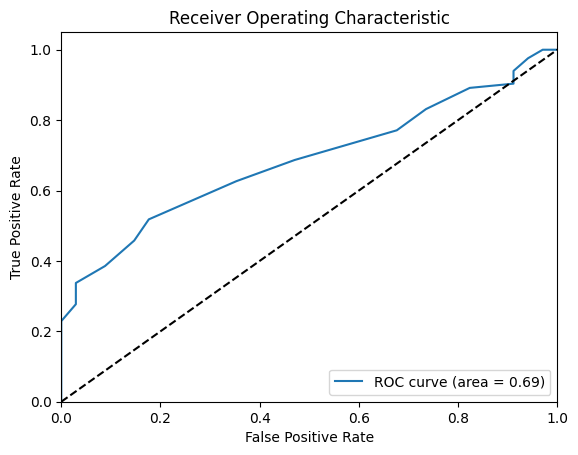

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)

number_of_n_neighbors = list(range(1,50));  # Define the range of hyperparameter values we're interested in
# And a list to hold the resulting accuracies
accuracies_result = []
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
skf = StratifiedKFold(n_splits=5)
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}
# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
# Create a decision tree classifier model object with pipline
pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])



for k in number_of_n_neighbors:

  # Change the minimum parent size
  pipeline.set_params(model__n_neighbors = k)
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

  #print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")
pipeline.fit(non_test_examples,non_test_labels) # fitting the 20% testing for finding the ROC curve
y_prob = pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.2f}")
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is fair. This means that the modle is not guessing but still requires some imporvment.

# Overall conclusion on KNeighborsClassifier

In conclusion, the KNeighborsClassifier is a borderline fair model, as shown by the ROC curve, for both the base model and the model with hyperparameters. Furthermore, the base model ROC curve is only one percentage lower (68 for the base model and 69 for the model
that includes Hyperparameters) than the model that has the Hyperparameters included. Additionally, the base model's final Accuracy score without any modification was 67.1%, which has decreased over time. This means that the model's performance was being overfit, or the data provided was initially unbalanced, before implementing features such as a pipeline, data cleaning, and K-fold cross-validation were applied to the model.

## Model 3: evaluation (GaussianNB Modle)
Example text: The following code cell evaluates a Naive Bayes model. The resulting [insert name of performance metric] is ##.

Answer: the follwoing base GaussianNB modle code showes an accuracy of 0.51 or (51%)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# < Shuffle and split into training data (60%) and testing data (40%)>
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
# <Create a GaussianNB model object>
model = GaussianNB()
# <Fit the model to our training data>
model.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = model.predict(test_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")
# ...

Accuracy: 0.5170940170940171 (or 51.7 %)


## Stratified sampling with validation and clean data for GaussiaNB Model

The code cell calculates and evaluates a GaussiaNB classifier that implements validation, stratifying and clean data with the additional 80/20 split and shuffle, resulting in an accuracy of 0.526 or (52.6%).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

# ...
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

validate_examples = scaler.transform(validate_examples)

model = GaussianNB()
# <Fit the model to our training data>
model.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = model.predict(validate_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(validate_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.5258620689655172 (or 52.6 %)


## K-fold cross-validation with pipeline, validation, and stratifying and clean data for the GaussianNB Model.

The code cell calculates and evaluates a GaussianNBClassifier that implements validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying together with an 80/20 split and shuffling, resulting in an average accuracy of 0.548 (54.8%).

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()


# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a k-nearest neighbours classifier with pipline
pipeline = Pipeline([('scaler', StandardScaler()), ('model',GaussianNB())])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.52688172 0.55913978 0.53763441 0.51612903 0.59782609]
Average accuracy: 0.548 (or 54.8%)


## The Precision and Recall Score for GaussianNB model

The following shows the Precision and recall scores for the GaussianNB classifier. The precision score indcates that 97% of the modles 'yes' predictions were correct.

The Recall score correctly idetrified  42% of the actual yes cases.

In [ ]:
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (e.g., "")

precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")


Precision: 0.97
Recall Score: 0.42


##  Confusion Matrix for GaussianNB model

This is the confusion matrix of the final version of the base GaussianNBClassifier model with the implementation of pipeline, K-fold cross-validation (5-fold),stratifying, clean data, and validation.

Confusion Matrix:
[[33  1]
 [48 35]]


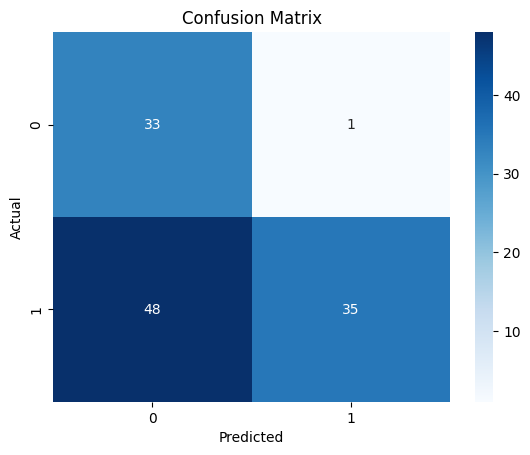

In [ ]:
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model',GaussianNB())])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

pipeline.fit(non_test_examples,non_test_labels)
# Evaluate the model using accuracy
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the model was able to identify 35 true negatives and 33 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 48 as false positives. This is incorrect as they are negative cases. While identifying 1 cases as negative but they are actually positive cases.

## Visualisation of the ROC curve for GaussianNB

This is the ROC curve of the GaussianNBClassifier with a ROC score of 0.68.

ROC AUC: 0.68


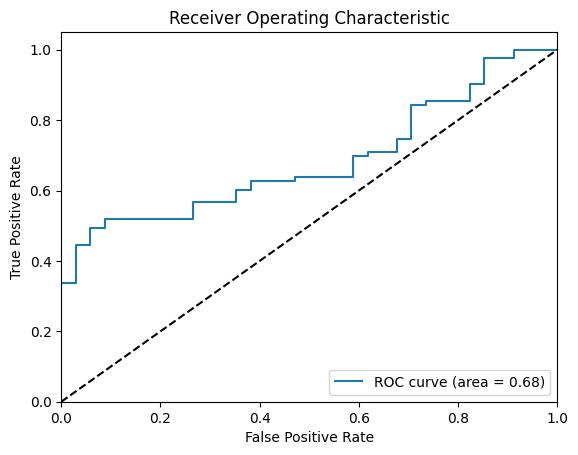

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Create a k-nearest neighbours classifier
pipeline = Pipeline([('scaler', StandardScaler()), ('model',GaussianNB())])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')


# Generate predicted probabilities for the positive class
pipeline.fit(non_test_examples,non_test_labels) # fitting the 20% testing for finding the ROC curve
y_prob = pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.2f}")
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is fair. This means that the modle is not guessing but still requires some imporvment.

# Final Conclusion for GaussianNB

In conclusion, the GaussiabNB model has 0.68 for the ROC curve. This shows that this model's performance is weak. Furthermore, the confusion matrix shows that it is identifying the positive cases as negative and the negative cases as positive, which indicates that the model cannot distinguish between classes properly. Furthermore, the model's final accuracy score after implementing features like pipeline, stratification, data cleaning, k-fold, and validation was not good in performance. As the base model was 52.6 and the final model with implementation of the different features mentioned was 54.8, which is a 2.2% increase in performance that is not very significant. In addition, the precision 97% and the recall is low at 42%. This means that it was able to predict most of the positive cases, but it was only able to identify very few of the positive cases. This concluded that the GaussianNB is a poor performance model.

## Model # evaluation
**Keep repeating the basic text cell + code cell structure for every model you evaluate.**

Example text: The following code cell evaluates a ... model. The resulting [insert name of performance metric] is ##.


# Model 4: Evaluation Random Forest Classifier Model


Example text: The following code cell evaluates a Naive Bayes model. The resulting [insert name of performance metric] is ##.

Answer: the follwoing random forest Classifier code showes an accuracy of 0.67 or (67%)

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()


# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

# Create a Random forest classifier model object
model = RandomForestClassifier(random_state=99)
# Fit the model to our training data
model.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = model.predict(test_examples)

# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.6752136752136753 (or 67.5 %)


## Stratified sampling with validation and clean data for RandomForestClassifier Model

The code cell calculates and evaluates a RandomForestClassifier that implements validation, stratifying and clean data with the additional 80/20 split and shuffle, resulting in an accuracy of 0.707 or (70.7%).

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
validate_examples = scaler.transform(validate_examples)
# Create a Random forest classifier model object
model = RandomForestClassifier(random_state=99)
# Fit the model to our training data
model.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = model.predict(validate_examples)

# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(validate_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")


Accuracy: 0.7068965517241379 (or 70.7 %)


## Random Forest Classifier Model with the implementation of validation and pipeline with k-fold cross-validation and clean data and stratifying

The code cell calculates and evaluates a RandomForestClassifier that implements validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying together with an 80/20 split and shuffling, resulting in an average accuracy of 0.692 (69.2%).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model',RandomForestClassifier(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies,  one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.69892473 0.68817204 0.65591398 0.66666667 0.75      ]
Average accuracy: 0.692 (or 69.2%)


## The Precision and Recall Score for Random Forest Classifier

The following shows the Precision and recall scores for the RandomForest Classifier. The precision score indicates that 80% of the models 'yes' predictions were correct.

The Recall score correctly identified 84% of the actual yes cases.


In [ ]:
from sklearn.metrics import precision_score, recall_score

# Calculate precision and recall, specifying the positive class (e.g., "")
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")


Precision: 0.80
Recall Score: 0.84


## Confusion Matrix for Random Forest Classifier

This is the confusion matrix of the final version of the base RandomForestClassifier model with the implementation of pipeline, K-fold cross-validation (5-fold),stratifying, clean data, and validation.

Confusion Matrix:
[[17 17]
 [13 70]]


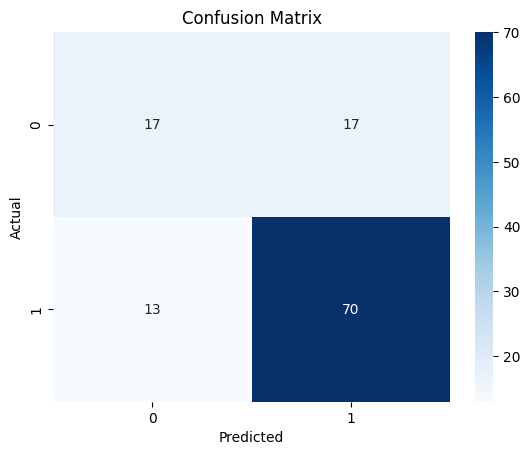

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model',RandomForestClassifier(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the model was able to identify 70 true negatives and 17 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 13 as false positives. This is incorrect as the are negative cases. While identifying 17 cases as negative but they are actually positive cases.

## Visualisation of the ROC curve for Random Forest Classifier

This is the ROC curve of the RandomForestClassifier with a ROC score of 0.77.

ROC AUC: 0.77


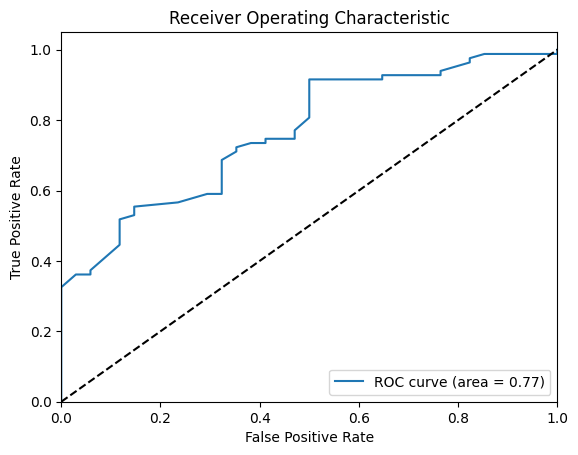

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model',RandomForestClassifier(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies,  one per fold
#print(accuracies)

# Display the average accuracy
#print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

# Generate predicted probabilities for the positive class
pipeline.fit(non_test_examples,non_test_labels) # fitting the 20% testing for finding the ROC curve
y_prob = pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.2f}")
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well and doing much better the gussing.

#  Investigating Random Forest Hyperparameter settings (n_estimators)

The code cell calculates and evaluates a  RandomForestClassifier using a n_estimators hyperparameter and a 60/40 split with shuffle, resulting in the highest accuracy of 71.4% when The number of n_estimators was between 40 and 60.

Accuracy: 0.6367521367521367 (or 63.7 %)
Accuracy: 0.594017094017094 (or 59.4 %)
Accuracy: 0.6538461538461539 (or 65.4 %)
Accuracy: 0.6153846153846154 (or 61.5 %)
Accuracy: 0.6666666666666666 (or 66.7 %)
Accuracy: 0.6709401709401709 (or 67.1 %)
Accuracy: 0.6923076923076923 (or 69.2 %)
Accuracy: 0.7008547008547008 (or 70.1 %)
Accuracy: 0.6965811965811965 (or 69.7 %)
Accuracy: 0.6752136752136753 (or 67.5 %)
Accuracy: 0.688034188034188 (or 68.8 %)
Accuracy: 0.6965811965811965 (or 69.7 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.6623931623931624 (or 66.2 %)
Accuracy: 0.6623931623931624 (or 66.2 %)
Accuracy: 0.6623931623931624 (or 66.2 %)
Accuracy: 0.6581196581196581 (or 65.8 %)
Accuracy: 0.6709401709401709 (or 67.1 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.6837606837606838 (or 68.4 %)
Accuracy: 0.6666666666666666 (or 66.7 %)
Accuracy: 0.6752136752136753 (or 67.5 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.6666666666666666 (or 66.7 %)
Accuracy: 0.679487

Text(0, 0.5, 'Accuracy in %')

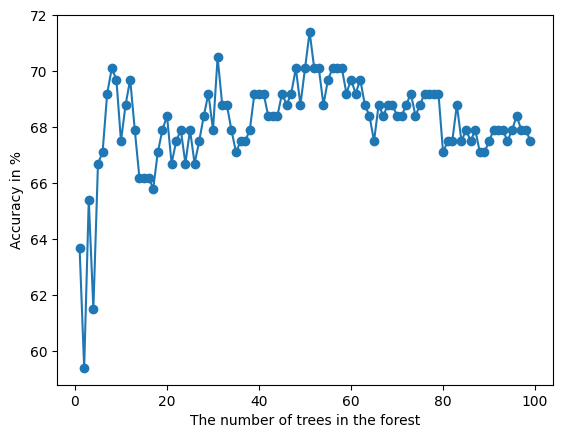

In [ ]:
from ast import mod
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()


# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)


# And a list to hold the resulting accuracies
accuracies = []
biggest_number = -1
float(biggest_number)
range_n_estimator = list(range(1,100)) # Define the range of hyperparameter values we're interested in
for number in range_n_estimator:
  model = RandomForestClassifier(random_state=99)
  model.set_params(n_estimators= number)

  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(test_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(test_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100,1))
  for a in accuracies:
    if(a > biggest_number):
      biggest_number = a
print("biggiest one: " , biggest_number)

#plot the graph of resulets:
plt.figure()
plt.plot(range_n_estimator, accuracies, marker='o', linestyle='-')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy in %')

## Investigating Random Forest Hyperparameter settings (n_estimators) with stratifying, validation and clean data

This shows the percentage accuracy calculated at different n_estimators for the RandomForestClassifier model, with the implementation of clean data, validation, stratification, and shuffling. The highest accuracy, around 75%, was observed between n_estimators 40 and 60.

Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.6293103448275862 (or 62.9 %)
Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.646551724137931 (or 64.7 %)
Accuracy: 0.6293103448275862 (or 62.9 %)
Accuracy: 0.6551724137931034 (or 65.5 %)
Accuracy: 0.646551724137931 (or 64.7 %)
Accuracy: 0.6896551724137931 (or 69.0 %)
Accuracy: 0.6637931034482759 (or 66.4 %)
Accuracy: 0.6724137931034483 (or 67.2 %)
Accuracy: 0.6724137931034483 (or 67.2 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.646551724137931 (or 64.7 %)
Accuracy: 0.6551724137931034 (or 65.5 %)
Accuracy: 0.6379310344827587 (or 63.8 %)
Accuracy: 0.6724137931034483 (or 67.2 %)
Accuracy: 0.6810344827586207 (or 68.1 %)
Accuracy: 0.6896551724137931 (or 69.0 %)
Accuracy: 0.6896551724137931 (or 69.0 %)
Accuracy: 0.6896551724137931 (or 69.0 %)
Accuracy: 0.6810344827586207 (or 68.1 %)
Accuracy: 0.6810344827586207 (or 68.1 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.6724137931034483 (or 67.2 %)
Accuracy: 0.6810344

Text(0, 0.5, 'Accuracy in %')

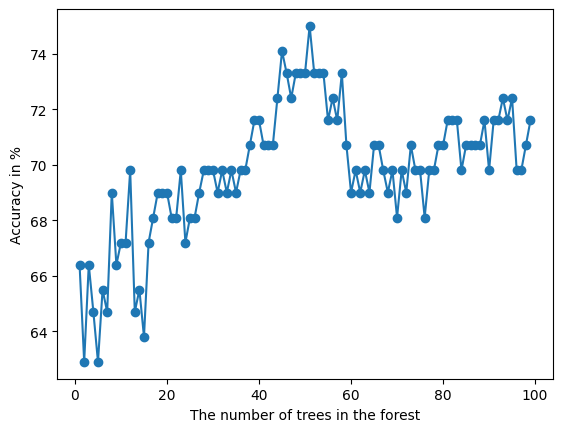

In [ ]:
from ast import mod
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()


# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)

scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
validate_examples = scaler.transform(validate_examples)
test_examples  = scaler.transform(test_examples)


# And a list to hold the resulting accuracies
accuracies = []
biggest_number = -1
float(biggest_number)
range_n_estimator = list(range(1,100)) # Define the range of hyperparameter values we're interested in
for number in range_n_estimator:
  model = RandomForestClassifier(random_state=99)
  model.set_params(n_estimators= number)

  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(validate_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100,1))


#plot the graph of resulets:
plt.figure()
plt.plot(range_n_estimator, accuracies, marker='o', linestyle='-')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy in %')

## Investigating Random Forest Hyperparameter settings (n_estimators) with K-fold cross-validation, with validation and clean data, and  pipeline

This shows the percentage accuracy calculated at different K numbers of neighbours for the  RandomForestClassifier, with the implementation of K-fold cross-validation (5 folds), clean data, validation, stratifying, a pipeline, and shuffling. The highest accuracy, around 75+%, was observed between 0 and 5 at fold four.

Average accuracy: 0.662 (or 66.2%)
Average accuracy: 0.604 (or 60.4%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.681 (or 68.1%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.662 (or 66.2%)
Average accuracy: 0.685 (or 68.5%)
Average accuracy: 0.668 (or 66.8%)
Average accuracy: 0.681 (or 68.1%)
Average accuracy: 0.675 (or 67.5%)
Average accuracy: 0.677 (or 67.7%)
Average accuracy: 0.683 (or 68.3%)
Average accuracy: 0.688 (or 68.8%)
Average accuracy: 0.692 (or 69.2%)
Average accuracy: 0.694 (or 69.4%)
Average accuracy: 0.681 (or 68.1%)
Average accuracy: 0.688 (or 68.8%)
Average accuracy: 0.696 (or 69.6%)
Average accuracy: 0.705 (or 70.5%)
Average accuracy: 0.707 (or 70.7%)
Average accuracy: 0.705 (or 70.5%)
Average accuracy: 0.700 (or 70.0%)


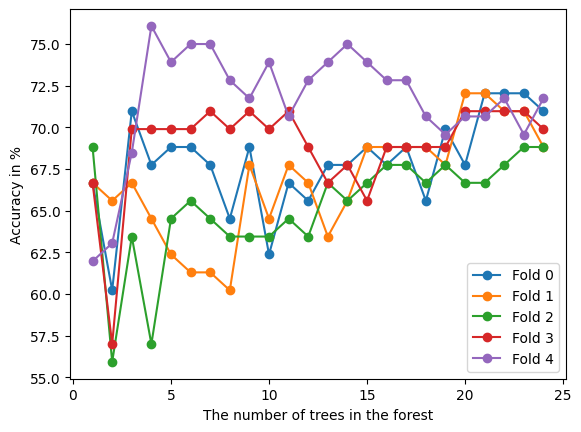

In [ ]:
from ast import mod
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'


# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}


range_n_estimator = list(range(1,25)) # Define the range of hyperparameter values we're interested in
# Create a RandomForestClassifier
pipeline = Pipeline([('scaler', StandardScaler()), ('model',RandomForestClassifier(random_state=99))])



for number in range_n_estimator:
  pipeline.set_params(model__n_estimators= number)

  # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

  print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")


#plot the graph of resulets:
  for fold_i, accuracies_result in enumerate(accuracies):
   fold_accuracies[fold_i].append(accuracies_result * 100)
# Add legend entries for each split
plt.figure()
lines = []
labels = []

for i in number_splits_fold:
    line, = plt.plot(range_n_estimator,
                     fold_accuracies[i],
                     marker='o',
                     linestyle='-')
    lines.append(line)
    labels.append(f"Fold {i}")
# Show evaluation results graphically
plt.legend(lines, labels, loc="lower right")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy in %")
plt.show()


## The Precision and recall score for the Random Forest Hyperparameter

This illustrates the precision and recall scores of the RandomForestClassifier with the n_estimators hyperparameter. The recall is at 84%, and the precision is at 80%.

In [ ]:

from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (e.g., "")

precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")


Precision: 0.80
Recall Score: 0.84


## Confusion matrix for RandomForest Hyperparameter

This is the confusion matrix for the n_estimators hyperparameter of the RandomForestClassifier model.

Confusion Matrix:
[[16 18]
 [13 70]]


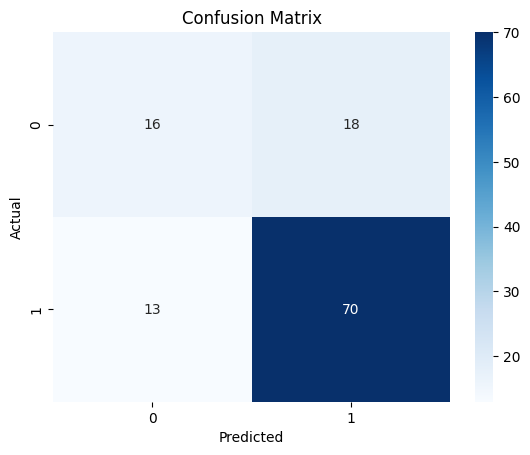

In [ ]:
from ast import mod
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'


# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))
# And a list to hold the resulting accuracies
accuracies_result = []

range_n_estimator = list(range(1,25)) # Define the range of hyperparameter values we're interested in
# Create a RandomForestClassifier
pipeline = Pipeline([('scaler', StandardScaler()), ('model',RandomForestClassifier(random_state=99))])



for number in range_n_estimator:
  pipeline.set_params(model__n_estimators= number)

  # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
  accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

  #print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")
  #accuracies_result.append(accuracies*100)

# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


The confusion matrix shows that the model was able to identify 70 true negatives and 16 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 13 as false positives. This is incorrect as they are negative cases. While identifying 18 cases as negative but they are actually positive cases.

## Visualisation of the ROC Curve for the Random Forest Hyperparameter

This is the ROC curve of the KNeighborsClassifier with hyperparameters of n_neighbors with a ROC score of 0.75.

ROC AUC: 0.75


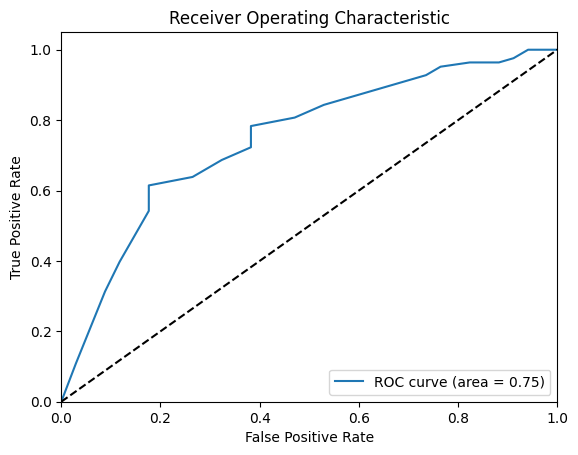

In [ ]:
from ast import mod
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'


# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(test_examples,test_labels))
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}
# And a list to hold the resulting accuracies
#accuracies_result = []

range_n_estimator = list(range(1,25)) # Define the range of hyperparameter values we're interested in
# Create a RandomForestClassifier
pipeline = Pipeline([('scaler', StandardScaler()), ('model',RandomForestClassifier(random_state=99))])



for number in range_n_estimator:
  pipeline.set_params(model__n_estimators= number)

  # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
  accuracies = cross_val_score(pipeline, non_test_examples,non_test_labels, cv=indices, scoring='accuracy')



pipeline.fit(non_test_examples,non_test_labels) # fitting the 20% testing for finding the ROC curve
y_prob = pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.2f}")
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well and doing much better the gussing.

## The Final conclusion for the RandomForest classifier

The Random Forest classifier shows significant improvement over the strat with a 69.2% for the base model. Additionally, the second version of Random Forest achieves an accuracy of 70.7%, representing a 1.5% improvement. Although this is not a significant improvement, it is still achievable. However, the final version of the model is 69.2% which is the same as the base. This means that the model might not have found any significant new patterns. Furthermore, the ROC of the Random Forest is 0.77, which is a good ROC value indicating that the model can distinguish between classes effectively.
Furthermore, the precision and recall scores are excellent, with precision at 80% and recall at 84%. This means the model was able to correctly predict 80% of the positive cases and identify 84% of the positive cases. Furthermore, the model can identify quite a few True negative cases(70), implying that it is more likely to lean towards negative cases.

Additionally, the hyperparameter version of the model is robust, as it predicts 70 true negatives and 16 true positives, indicating that the model still identifies negative cases more frequently than positive cases. Furthermore, false positives and false negatives are relatively low, which implies that it is still identifying some cases incorrectly, but on a smaller scale. However, similar to the baseline model with a high ROC of 0.77, the hyperparameter version also achieves a high ROC of 0.75, indicating that it can still effectively distinguish between classes. On the other hand, the base version of the hyperparameter of the model was 72% between n_estimators of 40 and 60, which is 2% difference in the base model. However, they have the same precision and recall score, which indicates they are on the same level in terms of prediction and identifying positive cases.










# Model 5: Evaluation SGDClassifier Model


Example text: The following code cell evaluates a Naive Bayes model. The resulting [insert name of performance metric] is ##.

Answer: the follwoing SGDClassifier modle code showes an accuracy of 0.58 or (58%)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# < Shuffle and split into training data (60%) and testing data (40%)>
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
# <Create a SGDClassifier model object>
model = SGDClassifier(random_state=99)
# <Fit the model to our training data>
model.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = model.predict(test_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")
# ...

Accuracy: 0.5811965811965812 (or 58.1 %)


## Implementation of Stratifying, validation, and clean data for SGDClassifier

The code cell calculates and evaluates a SGDClassifier that implements validation, stratifying and clean data with the additional 80/20 split and shuffle, resulting in an accuracy of 0.716 or (71.6%).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)


scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
# <Create a SGDClassifier model object>
model = SGDClassifier(random_state=99)
# <Fit the model to our training data>
model.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = model.predict(validate_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(validate_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")
# ...

Accuracy: 0.7155172413793104 (or 71.6 %)


## Pipeline with validation, stratifying, and k-cross validation implemented, and clean data for SGDClassifier.

The code cell calculates and evaluates a SGDClassifier that implements validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying together with an 80/20 split and shuffling, resulting in an average accuracy of 0.640 (64.0%).

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies,  one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.66666667 0.55913978 0.55913978 0.72043011 0.69565217]
Average accuracy: 0.640 (or 64.0%)


## The Precision and Recall score for SGDClassifier Model

The following shows the Precision and recall scores for the SGDClassifier. The precision score indicates that 71% of the models 'yes' predictions were correct.

The Recall score correctly identified 83% of the actual yes cases.

In [ ]:
# Import the packages we need
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (e.g., "")
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")


Precision: 0.71
Recall Score: 0.83


##  Confusion Matrix for SGDClassifier Model

This is the confusion matrix of the final version of the base SGDClassifier model with the implementation of pipeline, K-fold cross-validation (5-fold),stratifying, clean data, and validation.

Confusion Matrix:
[[ 6 28]
 [14 69]]


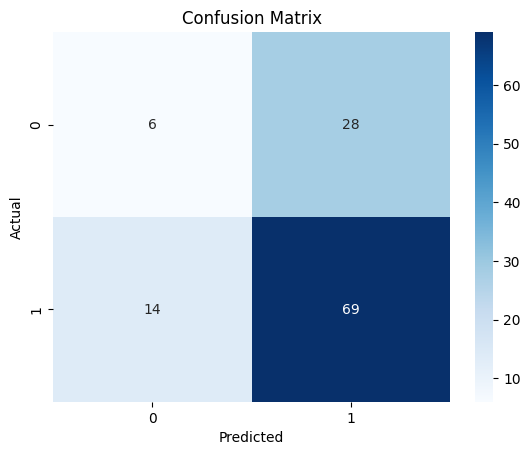

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the model was able to identify 69 true negatives and 6 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 14 as false positives. This is incorrect as they are negative cases. While identifying 28 cases as negative but they are actually positive cases.

## Visualisation of the ROC curve for SGDClassifier Model

This is the ROC curve of the SGDClassifier with a ROC score of 0.75.

ROC AUC: 0.75


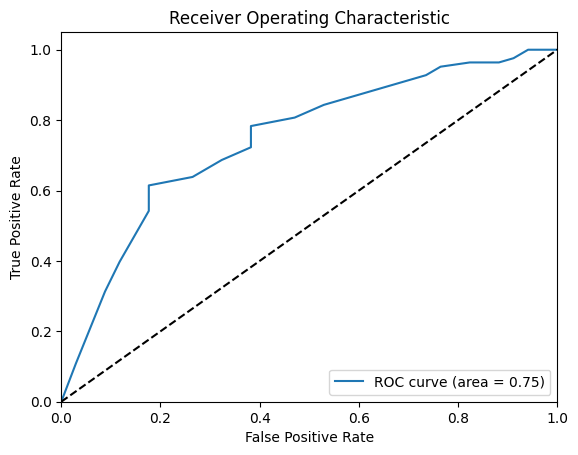

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies,  one per fold
#print(accuracies)

# Display the average accuracy
#print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

# Plot the ROC curve
print(f"ROC AUC: {roc_auc:.2f}")
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well and doing much better the gussing.

# Investigation Hyperparameter for SGDClassifier Model (max_iter)

The code cell calculates and evaluates a SGDClassifier using a max_iter hyperparameter and a 60/40 split with shuffle, resulting in the highest accuracy of 72.5% when The number of max_iter was between 0 and 10.

Accuracy: 0.6581196581196581 (or 65.8 %)
Accuracy: 0.5769230769230769 (or 57.7 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.5769230769230769 (or 57.7 %)
Accuracy: 0.6623931623931624 (or 66.2 %)
Accuracy: 0.6538461538461539 (or 65.4 %)
Accuracy: 0.6111111111111112 (or 61.1 %)
Accuracy: 0.7350427350427351 (or 73.5 %)
Accuracy: 0.594017094017094 (or 59.4 %)
Accuracy: 0.5470085470085471 (or 54.7 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.6752136752136753 (or 67.5 %)
Accuracy: 0.5769230769230769 (or 57.7 %)
Accuracy: 0.7051282051282052 (or 70.5 %)
Accuracy: 0.6837606837606838 (or 68.4 %)
Accuracy: 0.7008547008547008 (or 70.1 %)
Accuracy: 0.6324786324786325 (or 63.2 %)
Accuracy: 0.6581196581196581 (or 65.8 %)
Accuracy: 0.594017094017094 (or 59.4 %)
Accuracy: 0.6709401709401709 (or 67.1 %)
Accuracy: 0.6581196581196581 (or 65.8 %)
Accuracy: 0.6965811965811965 (or 69.7 %)
Accuracy: 0.6794871794871795 (or 67.9 %)
Accuracy: 0.688034188034188 (or 68.8 %)
Accuracy: 0.64102564

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Text(0, 0.5, 'Accuracy in %')

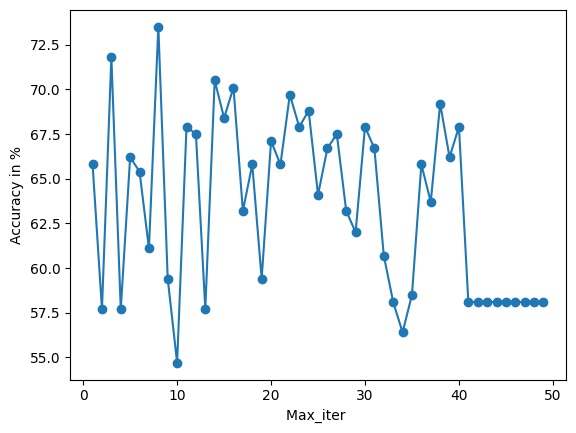

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# < Shuffle and split into training data (60%) and testing data (40%)>
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
accuracies = []
maxiter_numbers= list(range(1,50));  # Define the range of hyperparameter values we're interested in
for m in maxiter_numbers:
  # <Create a SGDClassifier model object>
  model = SGDClassifier(random_state=99)
  model.set_params(max_iter = m)
  # <Fit the model to our training data>
  model.fit(train_examples, train_labels)

  # <Use the model to generate predictions for our testing examples>
  predictions = model.predict(test_examples)

  # <Calculate the model's accuracy - the fraction of predictions that were correct>
  accuracy = accuracy_score(test_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")
  accuracies.append(round(accuracy*100,1))

#plot the graph of resulets:
plt.figure()
plt.plot(maxiter_numbers, accuracies, marker='o', linestyle='-')
plt.xlabel('Max_iter ')
plt.ylabel('Accuracy in %')



## Investigation Hyperparameter for SGDClassifier Model (max_iter) with cleaned data, validation, and stratifying


This shows the percentage accuracy calculated at different max_iter for the SGDClassifier model, with the implementation of clean data, validation, stratification, and shuffling. The highest accuracy, around 75%, was observed between 0 and 10.

Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.7758620689655172 (or 77.6 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.7586206896551724 (or 75.9 %)
Accuracy: 0.75 (or 75.0 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.75 (or 75.0 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7672413793103449 (or 76.7 %)
Accuracy: 0.7068965517241379 (or 70.7 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.6293103448275862 (or 62.9 %)
Accuracy: 0.6724137931034483 (or 67.2 %)
Accuracy: 0.75 (or 75.0 %)
Accuracy: 0.5603448275862069 (or 56.0 %)
Accuracy: 0.5431034482758621 (or 54.3 %)
Accuracy: 0.603448275862069 (or 60.3 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.6982758620689655 (or 69.8 %)
Accuracy: 0.5948275862068966 (or 59.5 %)
Accuracy: 0.7586206896551724 (or 75.9 %)
Accuracy: 0.732758

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Text(0, 0.5, 'Accuracy in %')

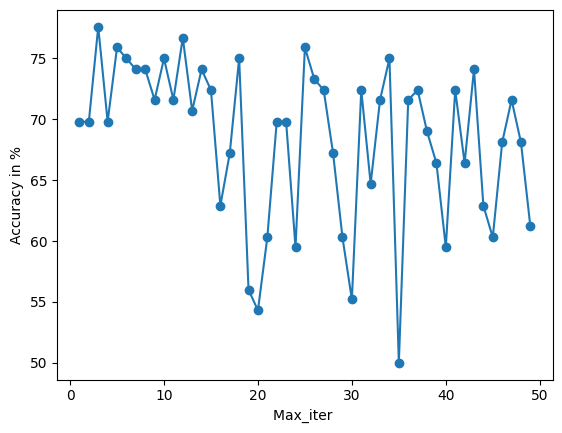

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
validate_examples = scaler.transform(validate_examples)
accuracies = []
maxiter_numbers= list(range(1,50));  # Define the range of hyperparameter values we're interested in
for m in maxiter_numbers:
  # <Create a SGDClassifier model object>
  model = SGDClassifier(random_state=99)
  model.set_params(max_iter = m)
  # <Fit the model to our training data>
  model.fit(train_examples, train_labels)

  # <Use the model to generate predictions for our testing examples>
  predictions = model.predict(validate_examples)

  # <Calculate the model's accuracy - the fraction of predictions that were correct>
  accuracy = accuracy_score(validate_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")
  accuracies.append(round(accuracy*100,1))

#plot the graph of resulets:
plt.figure()
plt.plot(maxiter_numbers, accuracies, marker='o', linestyle='-')
plt.xlabel('Max_iter ')
plt.ylabel('Accuracy in %')


## Investigation Hyperparameter for SGDClassifier Model (max_iter) with k-fold cross-validation, stratifying, validation, pipeline and clean data

This shows the percentage accuracy calculated at different max_iter for the  SGDClassifier, with the implementation of K-fold cross-validation (5 folds), clean data, validation, stratifying, a pipeline, and shuffling. The highest accuracy, around 85%, was observed between 0 and 10 at fold four.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Average accuracy: 0.662 (or 66.2%)
Average accuracy: 0.677 (or 67.7%)
Average accuracy: 0.666 (or 66.6%)
Average accuracy: 0.647 (or 64.7%)
Average accuracy: 0.724 (or 72.4%)
Average accuracy: 0.616 (or 61.6%)
Average accuracy: 0.634 (or 63.4%)
Average accuracy: 0.671 (or 67.1%)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Average accuracy: 0.705 (or 70.5%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.718 (or 71.8%)
Average accuracy: 0.705 (or 70.5%)
Average accuracy: 0.709 (or 70.9%)
Average accuracy: 0.653 (or 65.3%)
Average accuracy: 0.666 (or 66.6%)
Average accuracy: 0.675 (or 67.5%)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

...

Average accuracy: 0.696 (or 69.6%)
Average accuracy: 0.683 (or 68.3%)
Average accuracy: 0.705 (or 70.5%)
Average accuracy: 0.707 (or 70.7%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.709 (or 70.9%)
Average accuracy: 0.705 (or 70.5%)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Average accuracy: 0.606 (or 60.6%)
Average accuracy: 0.677 (or 67.7%)
Average accuracy: 0.653 (or 65.3%)
Average accuracy: 0.687 (or 68.7%)
Average accuracy: 0.694 (or 69.4%)
Average accuracy: 0.651 (or 65.1%)
Average accuracy: 0.670 (or 67.0%)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Average accuracy: 0.722 (or 72.2%)
Average accuracy: 0.640 (or 64.0%)
Average accuracy: 0.636 (or 63.6%)


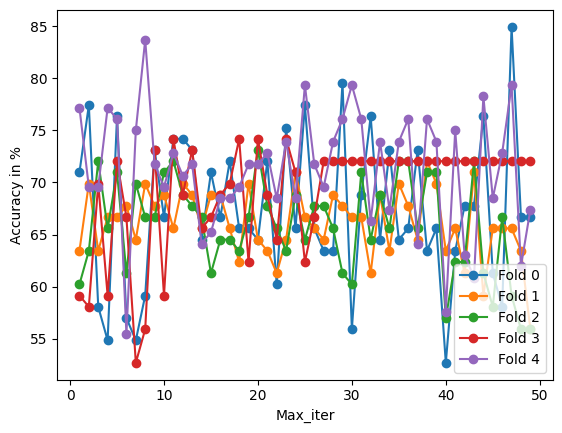

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

maxiter_numbers= list(range(1,50));  # Define the range of hyperparameter values we're interested in
# And a list to hold the resulting accuracies


# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}

model = SGDClassifier(random_state=99)
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(random_state=99))])
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
skf = StratifiedKFold(n_splits=5)
# Create a decision tree classifier model object

for m in maxiter_numbers:

  pipeline.set_params(model__max_iter = m)
  accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

  print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

#plot the graph of resulets:
  for fold_i, accuracies_result in enumerate(accuracies):
   fold_accuracies[fold_i].append(accuracies_result * 100)
# Add legend entries for each split
plt.figure()
lines = []
labels = []

for i in number_splits_fold:
    line, = plt.plot(maxiter_numbers,
                     fold_accuracies[i],
                     marker='o',
                     linestyle='-')
    lines.append(line)
    labels.append(f"Fold {i}")
# Show evaluation results graphically
plt.legend(lines, labels, loc="lower right")
plt.xlabel("Max_iter")
plt.ylabel("Accuracy in %")
plt.show()


## precision and recall score for SGDClassifier Hyperparameter

This illustrates the precision and recall scores of the SGDClassifier with the max_iter hyperparameter. The recall is at 83%, and the precision is at 71%.

In [ ]:
# Calculate precision and recall, specifying the positive class (e.g., "")
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")

Precision: 0.71
Recall Score: 0.83


## Confusion Matrix for SGDClassifier Hyperparameter

This is the confusion matrix for the  max_iter hyperparameter of the SGDClassifier model.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Confusion Matrix:
[[ 6 28]
 [14 69]]


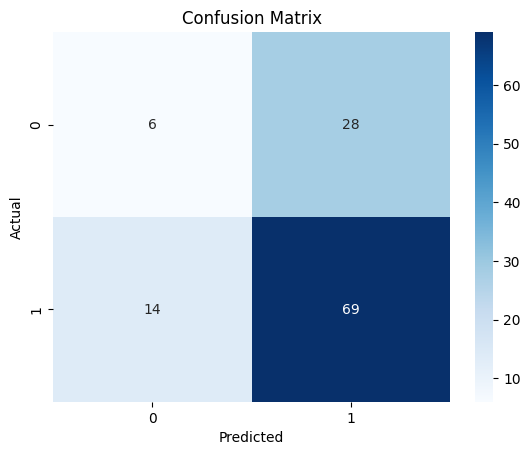

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

maxiter_numbers= list(range(1,50));  # Define the range of hyperparameter values we're interested in
# And a list to hold the resulting accuracies
#accuracies_result = []

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}

model = SGDClassifier(random_state=99)
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(random_state=99))])
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
skf = StratifiedKFold(n_splits=5)
# Create a decision tree classifier model object

for m in maxiter_numbers:

  pipeline.set_params(model__max_iter = m)
  accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')


# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the model was able to identify 69 true negatives and 6 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 14 as false positives. This is incorrect as they are negative cases. While identifying 28 cases as negative but they are actually positive cases.

## The ROC curve for SGDClassifier Hyperparameter

This is the ROC curve of the SGDClassifier with hyperparameters of max_iter with a ROC score of 0.75.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

ROC AUC: 0.75


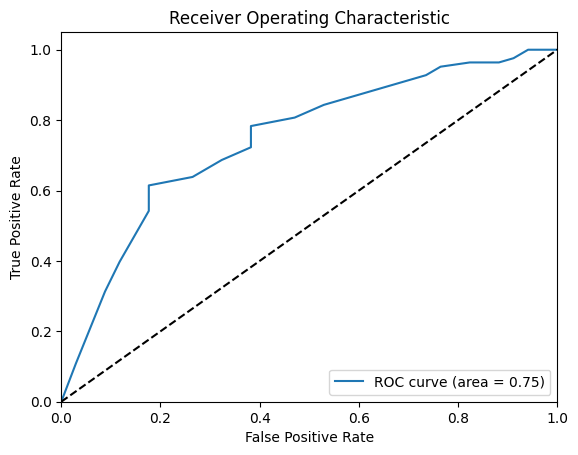

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

maxiter_numbers= list(range(1,50));  # Define the range of hyperparameter values we're interested in
# And a list to hold the resulting accuracies
#accuracies_result = []

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(test_examples,test_labels))
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}

model = SGDClassifier(random_state=99)
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(random_state=99))])
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
skf = StratifiedKFold(n_splits=5)
# Create a decision tree classifier model object

for m in maxiter_numbers:

  pipeline.set_params(model__max_iter = m)
  accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')


#ROC curve plotting
print(f"ROC AUC: {roc_auc:.2f}")
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well and doing much better the gussing.

# Conclusion on the SGDClassifier

The SGDClassifier shows a low performance of 58.1% for the base model without any improvement. However, with validation, stratification, and clean data, the base model achieved an accuracy of 71.6%, representing a 13.5% improvement. This indicates that clean data and stratifying the model will give a much higher accuracy score. Furthermore, the final version of the model, which adds a pipeline and k-fold cross-validation, showed an average accuracy of 64%. This indicates that data leakage still occurred before the pipeline was implemented, which is why there is a lower accuracy score.

In contrast, K-fold was able to give a more stable accuracy, which might have given it a lower accuracy score compared to the one without it, which would give a score based on luck. Additionally, in the confusion matrix, it mainly predicted true negatives, as it was the highest case predicted, with 69, while only giving six true positives. This indicates that the model leans more towards the negatives. Furthermore, the models were predicting a lot of false negatives, which indicates that there could have been a higher true positive case. However, the model's ROC reached a high of 0.75, indicating that it effectively distinguishes between classes.
Meanwhile, the recall score and precision were high, with a recall of 71% for precision, and a recall was 83%. This indicates that it was able to predict 71% of its predictions as actual positives while detecting 83% of the overall available positive cases. This shows the model is reliable and accurate at finding the positive cases.
However, the precision and recall of the hyperparameter version were the same, showing that there was no improvement with the addition of the max_iter hyperparameter. In contrast, the ROC remains the same, indicating no improvement in how the model distinguishes between classes. In addition to this, the model achieved high accuracy with the base hyperparameter and the additional features of the pipeline, validation, k-fold, and clean data. This shows that the model performs well and is reliable.

# Model 6: Evaluation of Support Vector Machine Classifier(SVC) Model

Example text: The following code cell evaluates a Naive Bayes model. The resulting [insert name of performance metric] is ##.

Answer: the follwoing Support Vector Machine Classifier(SVC) code showes an accuracy of 0.718 or (71.8%)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# < Shuffle and split into training data (60%) and testing data (40%)>
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
# <Create a SGDClassifier model object>
model = SVC(random_state=99)

# <Fit the model to our training data>
model.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = model.predict(test_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")
## ...

Accuracy: 0.717948717948718 (or 71.8 %)


##Stratified sampling with validation and clean data for Support Vector Machine Classifier(SVC) Model

The code cell calculates and evaluates a Support Vector Machine Classifier(SVC) that implements validation, stratifying and clean data with the additional 80/20 split and shuffle, resulting in an accuracy of 0.716 or (71.6%).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

target_feature = 'Pneumonia'

# <Split into examples and labelsSplit into examples and labels>
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)


scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
# <Create a SGDClassifier model object>
model = SVC(random_state=99)

# <Fit the model to our training data>
model.fit(train_examples, train_labels)

# <Use the model to generate predictions for our testing examples>
predictions = model.predict(validate_examples)

# <Calculate the model's accuracy - the fraction of predictions that were correct>
accuracy = accuracy_score(validate_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.7155172413793104 (or 71.6 %)


## Implementing validation with stratifying and clean data, and K-cross validation, and a pipeline for Support Vector Machine Classifier(SVC)

The code cell calculates and evaluates a Support Vector Machine Classifier(SVC) that implements validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying together with an 80/20 split and shuffling, resulting in an average accuracy of 0.718 (71.8%).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies,  one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.72043011 0.68817204 0.7311828  0.7311828  0.7173913 ]
Average accuracy: 0.718 (or 71.8%)


## Precision and Recall Score for Support Vector Machine Classifier (SCV) Model

The following shows the Precision and recall scores for the Support Vector Machine Classifier (SCV) . The precision score indicates that 72% of the models 'yes' predictions were correct.

The Recall score correctly identified 100% of the actual yes cases.

In [ ]:
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)

precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")

Precision: 0.72
Recall Score: 1.00


## Confusion Matrix for Support Vector Machine Classifier (SCV) Model

This is the confusion matrix of the final version of the base Support Vector Machine Classifier (SCV) model with the implementation of pipeline, K-fold cross-validation (5-fold),stratifying, clean data, and validation.

Confusion Matrix:
[[ 1 33]
 [ 0 83]]


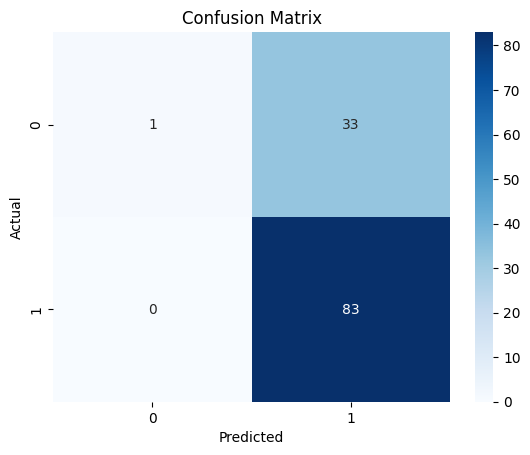

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples,non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline,non_test_examples,non_test_labels, cv=indices, scoring='accuracy')

# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the model was able to identify 83 true negatives and 1 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 0 as false positives. This is incorrect as they are negative cases. While identifying 33 cases as negative but they are actually positive cases.

## Visualisation of the ROC curve for Support Vector Machine Classifier(SVC) Model

This is the ROC curve of the Support Vector Machine Classifier(SVC) with a ROC score of 0.75.

ROC AUC: 0.75


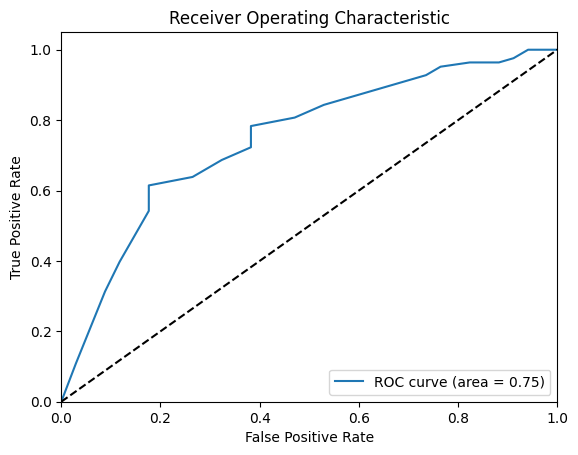

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')


# Plot the ROC curve
print(f"ROC AUC: {roc_auc:.2f}")
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well.

# Investigation Hyperparameters for Support Vector Machine Classifier(SVC) Model (gamma)

The code cell calculates and evaluates a Support Vector Machine Classifier(SVC) using a gamma hyperparameter and a 60/40 split with shuffle, resulting in the highest accuracy of 72.2% when The Gamma distance value was between 0.3 and 0.5

Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.7136752136752137 (or 71.4 %)
Accuracy: 0.7136752136752137 (or 71.4 %)
Accuracy: 0.717948717948718 (or 71.8 %)
Accuracy: 0.7136752136752137 (or 71.4 %)
Accuracy: 0.7136752136752137 (or 71.4 %)
Accuracy: 0.7136752136752137 (or 71.4 %)
Accuracy: 0.7136752136752137 (or 71.4 %)
Accuracy: 0.7136752136752137 (or 71.4 %)
Accuracy: 0.7136752136752137 (or 71.4 %)
Accuracy: 0.7094017094017094 (or 70.9 %)
Accuracy: 0.7136752136752137 (or 71.4 %)
Accuracy: 0.7094017094017094 (or 70.9 %)
Accuracy: 0.7094017094017094 (or 70.9 %)
Accuracy: 0.7136752136752137 (or 71.4 %)
Accuracy: 0.713675213675213

Text(0, 0.5, 'Accuracy in %')

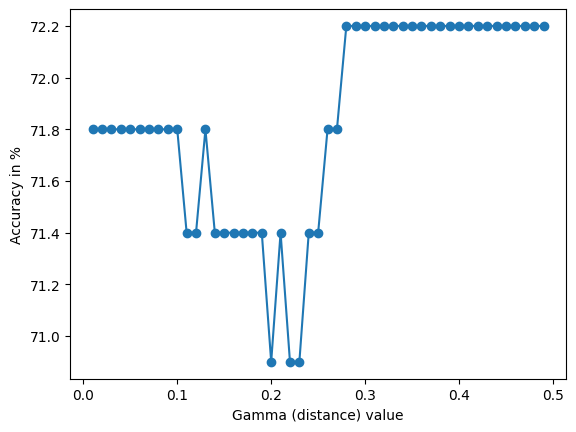

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')
# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

# Define the range of hyperparameter values we're interested in
gammas = [x / 100.0 for x in range(1, 50, 1)]
# And a list to hold the resulting accuracies
accuracies = []

for this_gamma in gammas:

  # Create a support vector machine classification model object:
  model = SVC(gamma=this_gamma)
  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(test_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(test_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100,1))

# Show evaluation results graphically
plt.figure()
plt.plot(gammas, accuracies, marker='o', linestyle='-')
plt.xlabel('Gamma (distance) value')
plt.ylabel('Accuracy in %')

## Investigation Hyperparameters for Support Vector Machine Classifier(SVC) Model (gamma) with validation, stratifying and clean data

This shows the percentage accuracy calculated at different gamma for the Support Vector Machine Classifier(SVC) model, with the implementation of clean data, validation, stratification, and shuffling. The highest accuracy, around 74%, was observed between 0.1 and 0.3.

Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.7241379310344828 (or 72.4 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7155172413793104 (or 71.6 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7413793103448276 (or 74.1 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7327586206896551 (or 73.3 %)
Accuracy: 0.7327

Text(0, 0.5, 'Accuracy in %')

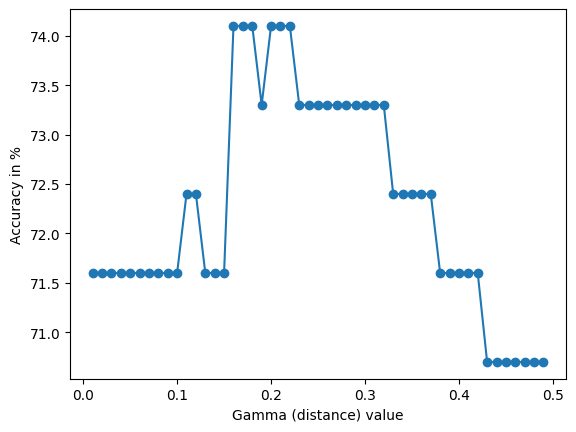

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')
# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)
# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)


# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

validate_examples = scaler.transform(validate_examples)

gammas = [x / 100.0 for x in range(1, 50, 1)]
# And a list to hold the resulting accuracies
accuracies = []

for this_gamma in gammas:

  # Create a support vector machine classification model object:
  model = SVC(gamma=this_gamma)
  # Fit the model to our training data
  model.fit(train_examples, train_labels)

  # Use the model to generate predictions for our testing examples
  predictions = model.predict(validate_examples)

  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions)
  print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100,1))

# Show evaluation results graphically
plt.figure()
plt.plot(gammas, accuracies, marker='o', linestyle='-')
plt.xlabel('Gamma (distance) value')
plt.ylabel('Accuracy in %')

## Investigation Hyperparameters for Support Vector Machine Classifier(SVC) Model (gamma) with K-fold cross-validation and validation with stratifying and cleaned data and Pipeline.

This shows the percentage accuracy calculated at different gamma for the  Support Vector Machine Classifier(SVC) , with the implementation of K-fold cross-validation (5 folds), clean data, validation, stratifying, a pipeline, and shuffling. The highest accuracy, around 74%, was observed between 0.2 and 0.3 at fold zero.

Average accuracy: 0.713 (or 71.3%)
Average accuracy: 0.713 (or 71.3%)
Average accuracy: 0.713 (or 71.3%)
Average accuracy: 0.713 (or 71.3%)
Average accuracy: 0.713 (or 71.3%)
Average accuracy: 0.713 (or 71.3%)
Average accuracy: 0.711 (or 71.1%)
Average accuracy: 0.709 (or 70.9%)
Average accuracy: 0.716 (or 71.6%)
Average accuracy: 0.718 (or 71.8%)
Average accuracy: 0.718 (or 71.8%)
Average accuracy: 0.718 (or 71.8%)
Average accuracy: 0.722 (or 72.2%)
Average accuracy: 0.722 (or 72.2%)
Average accuracy: 0.722 (or 72.2%)
Average accuracy: 0.722 (or 72.2%)
Average accuracy: 0.720 (or 72.0%)
Average accuracy: 0.713 (or 71.3%)
Average accuracy: 0.718 (or 71.8%)
Average accuracy: 0.718 (or 71.8%)
Average accuracy: 0.722 (or 72.2%)
Average accuracy: 0.720 (or 72.0%)
Average accuracy: 0.720 (or 72.0%)
Average accuracy: 0.720 (or 72.0%)
Average accuracy: 0.722 (or 72.2%)
Average accuracy: 0.722 (or 72.2%)
Average accuracy: 0.718 (or 71.8%)
Average accuracy: 0.718 (or 71.8%)
Average accuracy: 0.

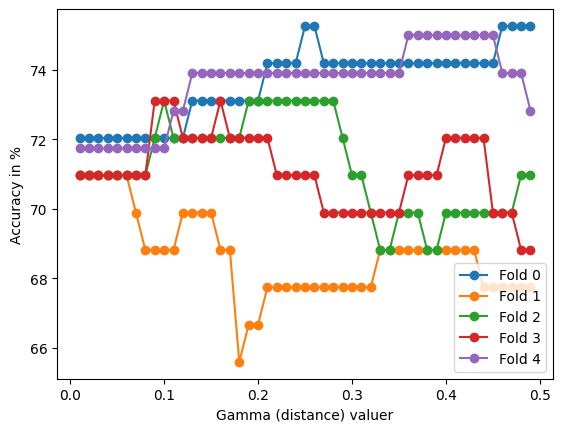

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')
# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)


# Define the range of hyperparameter values we're interested in
gammas = [x / 100.0 for x in range(1, 50, 1)]
# And a list to hold the resulting accuracies
accuracies_result = []

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
# <Create a SVC model object>
model = SVC(random_state=99)
# creat a pipline
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=99))])

for this_gamma in gammas:

  # Create a support vector machine classification model object:
  #model = SVC(gamma=this_gamma)
  pipeline.set_params(model__gamma = this_gamma)
  # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

  print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")
  #accuracies_result.append(accuracies*100)

#plot the graph of resulets:
  for fold_i, accuracies_result in enumerate(accuracies):
   fold_accuracies[fold_i].append(accuracies_result * 100)
# Add legend entries for each split
plt.figure()
lines = []
labels = []

for i in number_splits_fold:
    line, = plt.plot(gammas,
                     fold_accuracies[i],
                     marker='o',
                     linestyle='-')
    lines.append(line)
    labels.append(f"Fold {i}")

plt.legend(lines, labels, loc="lower right")
plt.xlabel("Gamma (distance) valuer")
plt.ylabel("Accuracy in %")
plt.show()



## Precision and Recall score for Support Vector Machine Classifier(SVC) Model (gamma) Hyperparameter

This illustrates the precision and recall scores of the Support Vector Machine Classifier(SVC) with the gamma hyperparameter. The recall is at 100%, and the precision is at 72%.

In [ ]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")

Precision: 0.72
Recall Score: 1.00


## Confusion matrix for Support Vector Machine Classifier(SVC) Model (gamma) Hyperparameter

This is the confusion matrix for the gamma hyperparameter of the Support Vector Machine Classifier(SVC) model.

Confusion Matrix:
[[ 8 26]
 [ 9 74]]


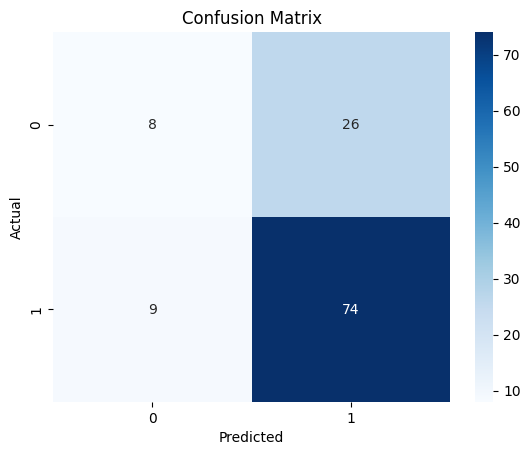

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')
# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)


# Define the range of hyperparameter values we're interested in
gammas = [x / 100.0 for x in range(1, 50, 1)]
# And a list to hold the resulting accuracies
accuracies_result = []

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
# <Create a SVC model object>
model = SVC(random_state=99)
# creat a pipline
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=99))])

for this_gamma in gammas:

  # Create a support vector machine classification model object:
  #model = SVC(gamma=this_gamma)
  pipeline.set_params(model__gamma = this_gamma)
  # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')



# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the model was able to identify 74 true negatives and 8 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 9 as false positives. This is incorrect as they are negative cases. While identifying 26 cases as negative but they are actually positive cases.

##  ROC curve  for Support Vector Machine Classifier(SVC) Model (gamma) Hyperparameter

This is the ROC curve of the  Support Vector Machine Classifier(SVC) with hyperparameters of gamma with a ROC score of 0.75.

ROC AUC: 0.75


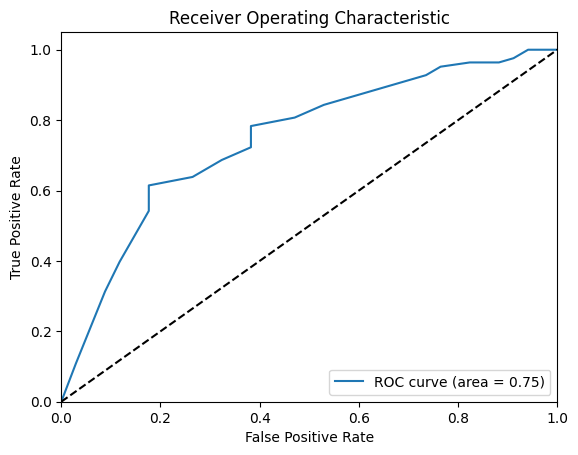

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')
# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)


# Define the range of hyperparameter values we're interested in
gammas = [x / 100.0 for x in range(1, 50, 1)]
# And a list to hold the resulting accuracies
accuracies_result = []

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
# <Create a SVC model object>
model = SVC(random_state=99)
# creat a pipline
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=99))])

for this_gamma in gammas:

  # Create a support vector machine classification model object:
  #model = SVC(gamma=this_gamma)
  pipeline.set_params(model__gamma = this_gamma)
  # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')


# Plot the ROC curve
print(f"ROC AUC: {roc_auc:.2f}")
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well.

# Conclusion on Support Vector Machine Classifier(SVC)

The Support Vector Machine Classifier (SVC) achieves a base accuracy of 71.8%, which is a relatively high accuracy. Furthermore, with the addition of stratifying, validation, and clean data, the accuracy reduced by 0.2%. This means that there was little noise in the data. Furthermore, with the final version of the model, including the added pipeline, k-fold cross-validation on top of the clean data, validation, and stratification, which brought the model back to 71.8%. This indicates that data leakage was occurring, which the pipeline prevented, thereby allowing the accuracy to increase.

Furthermore, K-fold was able to give a more stable accuracy, which allowed the accuracy to increase again. Additionally, the ROC shows an area under the curve of 0.75, indicating that the model can effectively distinguish between the classes. The confusion matrix indicates that the model is more likely to predict the true negative class, suggesting that it is more likely to identify the negative class than the positive class. In addition, the model was predicting the positive class as negative, indicating that the model is still making some incorrect predictions. Additionally, the hyperparameter version of the model achieved the highest accuracy of 74% between 0.2 and 0.3 at fold zero.
Additionally, the ROC curve of the hyperparameter version was 0.75, which is the same as that of the base model of SVC. In terms of precision and recall, the hyperparameter and base versions have the same precision of 72% and a recall score of 100%, indicating a strong prediction of positive cases and demonstrating that the model is reliable in identifying positive cases.


# Ensembles Section:

# Esembles Model 1: VotingClassifier

Answer: the follwoing  esemble VotingClassifier modle code showes an accuracy of 0.67 or (67%)

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

model1 = SVC(random_state= 99,probability=True) # diffreint modles
model2 = RandomForestClassifier(random_state= 99) # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modles
# the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
model = VotingClassifier(estimators=[('knn',model1),('nb',model2),('dt',model3)],voting='soft')
# Use the model to generate predictions for our testing examples
model.fit(train_examples,train_labels)
predictions = model.predict(test_examples)
# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.594017094017094 (or 59.4 %)


## VotingClassifier Esembles Model with validation, stratifying, and clean data

The code cell calculates and evaluates a VotingClassifier that combines RandomForestClassifier, SVC, and DecisionTreeClassifier with the implementation of validation, stratifying, and cleaned data alongside an 80/20 split with shuffling, resulting in an accuracy of 0.716 (71.6%).

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)

# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modles
# the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
model = VotingClassifier(estimators=[('svc',model1),('rf',model2),('dt',model3)],voting='soft')
# Use the model to generate predictions for our testing examples
model.fit(train_examples,train_labels)
predictions = model.predict(validate_examples)
# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(validate_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.7155172413793104 (or 71.6 %)


##k-fold cross-validation, validation, stratifying, pipeline and clean data for  VotingClassifier Ensemble Model

The code cell calculates and evaluates a VotingClassifier that combines RandomForestClassifier, SVC, and DecisionTreeClassifier with the implementation of validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying together with an 80/20 split and shuffling, resulting in an average accuracy of 0.670 (67.0%).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model',VotingClassifier(estimators=[('svc',model1),('rf',model2),('dt',model3)],voting='soft'))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies,  one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")

[0.64516129 0.68817204 0.66666667 0.64516129 0.7173913 ]
Average accuracy: 0.673 (or 67.3%)


## Precision and Recall Score: VotingClassifier Esembles Model

The following shows the Precision and recall scores for the VotingClassifier . The precision score indicates that 81% of the models 'yes' predictions were correct.

The Recall score correctly identified 78% of the actual yes cases.




In [ ]:
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (e.g., "1")
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")

Precision: 0.81
Recall Score: 0.80


## Confusion Matrix: VotingClassifier Esembles Model

This is the confusion matrix of the final version of the base VotingClassifier  Esembles model with the implementation of pipeline, K-fold cross-validation (5-fold),stratifying, clean data, and validation.

Confusion Matrix:
[[19 15]
 [17 66]]


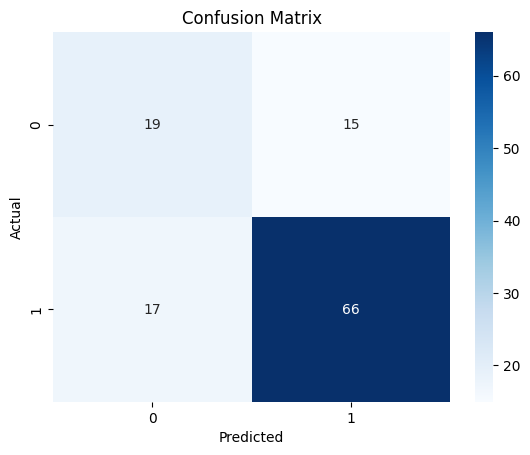

In [ ]:
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model',VotingClassifier(estimators=[('svc',model1),('rf',model2),('dt',model3)],voting='soft'))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the Esembles Model was able to identify 66 true negatives and 19 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 17 as false positives. This is incorrect as they are negative cases. While identifying 15 cases as negative but they are actually positive cases.

## ROC: VotingClassifier Esembles Model

This is the ROC curve of the  VotingClassifier Esembles Model with a ROC score of 0.75.

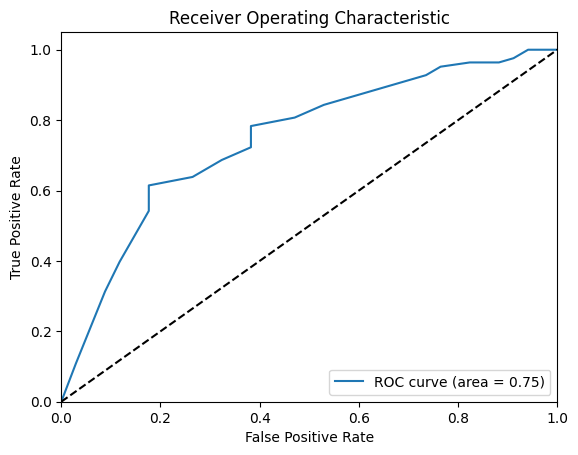

In [ ]:
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Create a pipeline combining our model with our preprocessing step
pipeline = Pipeline([('scaler', StandardScaler()), ('model',VotingClassifier(estimators=[('svc',model1),('rf',model2),('dt',model3)],voting='soft'))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')


# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well.

# Investigation Hyperparameter for VotingClassifier Esembles Model with Hyperparameter of other models ( RandomForest: n_estimator hyperprameter)

The code cell calculates and evaluates a VotingClassifier ensemble using the RandomForest n_estimators hyperparameter and a 60/40 split with shuffling, resulting in the highest accuracy of around 64% when n_estimators was at 0.

Accuracy at test  1  : 0.6410256410256411 (or 64.1 %)
Accuracy at test  2  : 0.6410256410256411 (or 64.1 %)
Accuracy at test  3  : 0.6025641025641025 (or 60.3 %)
Accuracy at test  4  : 0.5811965811965812 (or 58.1 %)
Accuracy at test  5  : 0.6153846153846154 (or 61.5 %)
Accuracy at test  6  : 0.6111111111111112 (or 61.1 %)
Accuracy at test  7  : 0.5982905982905983 (or 59.8 %)
Accuracy at test  8  : 0.5982905982905983 (or 59.8 %)
Accuracy at test  9  : 0.6025641025641025 (or 60.3 %)
Accuracy at test  10  : 0.594017094017094 (or 59.4 %)
Accuracy at test  11  : 0.5897435897435898 (or 59.0 %)
Accuracy at test  12  : 0.5897435897435898 (or 59.0 %)
Accuracy at test  13  : 0.6025641025641025 (or 60.3 %)
Accuracy at test  14  : 0.5897435897435898 (or 59.0 %)
Accuracy at test  15  : 0.6025641025641025 (or 60.3 %)
Accuracy at test  16  : 0.6025641025641025 (or 60.3 %)
Accuracy at test  17  : 0.5854700854700855 (or 58.5 %)
Accuracy at test  18  : 0.5982905982905983 (or 59.8 %)
Accuracy at test  19

Text(0, 0.5, 'Accuracy in %')

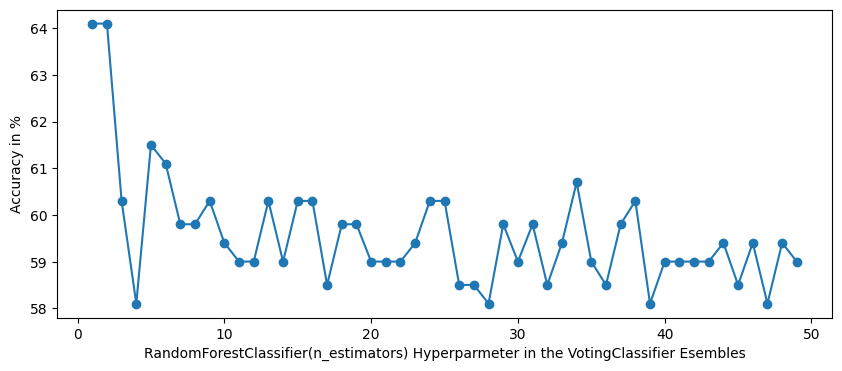

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
accuracies = []
n_numbers_estimators= list(range(1,50));  # Define the range of hyperparameter values we're interested in

model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modles
for number_range in n_numbers_estimators:
  model2.set_params(n_estimators = number_range)
  # the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
  model = VotingClassifier(estimators=[('knn',model1),('nb',model2),('dt',model3)],voting='soft')
  # Use the model to generate predictions for our testing examples
  model.fit(train_examples,train_labels)
  predictions = model.predict(test_examples)
  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(test_labels, predictions)
  print("Accuracy at test ",number_range," :", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100,1))
#ploting into a graph
plt.figure(figsize=(10,4))
plt.plot(n_numbers_estimators, accuracies, marker='o', linestyle='-')
plt.xlabel('RandomForestClassifier(n_estimators) Hyperparmeter in the VotingClassifier Esembles')
plt.ylabel('Accuracy in %')

## Investigation Hyperparameter for VotingClassifier Esembles Model with Hyperparameter of other models ( RandomForestClassifier: n_estimators hyperprameter) with stratifying and validation and clean data

This code cell calculates and evaluates a VotingClassifier that combines RandomForestClassifier, SVC, and DecisionTreeClassifier with validation, stratifying, cleaned data, and an 80/20 split with shuffling, while tuning the RandomForestClassifier n_estimators hyperparameter. The highest accuracy of 69+% was observed when n_estimators was set to zero.

Accuracy at test  1  : 0.6923076923076923 (or 69.2 %)
Accuracy at test  2  : 0.6923076923076923 (or 69.2 %)
Accuracy at test  3  : 0.6666666666666666 (or 66.7 %)
Accuracy at test  4  : 0.6752136752136753 (or 67.5 %)
Accuracy at test  5  : 0.6752136752136753 (or 67.5 %)
Accuracy at test  6  : 0.6923076923076923 (or 69.2 %)
Accuracy at test  7  : 0.6837606837606838 (or 68.4 %)
Accuracy at test  8  : 0.6752136752136753 (or 67.5 %)
Accuracy at test  9  : 0.6837606837606838 (or 68.4 %)
Accuracy at test  10  : 0.6752136752136753 (or 67.5 %)
Accuracy at test  11  : 0.6581196581196581 (or 65.8 %)
Accuracy at test  12  : 0.6666666666666666 (or 66.7 %)
Accuracy at test  13  : 0.6752136752136753 (or 67.5 %)
Accuracy at test  14  : 0.6837606837606838 (or 68.4 %)
Accuracy at test  15  : 0.6837606837606838 (or 68.4 %)
Accuracy at test  16  : 0.6752136752136753 (or 67.5 %)
Accuracy at test  17  : 0.6666666666666666 (or 66.7 %)
Accuracy at test  18  : 0.6666666666666666 (or 66.7 %)
Accuracy at test  1

Text(0, 0.5, 'Accuracy in %')

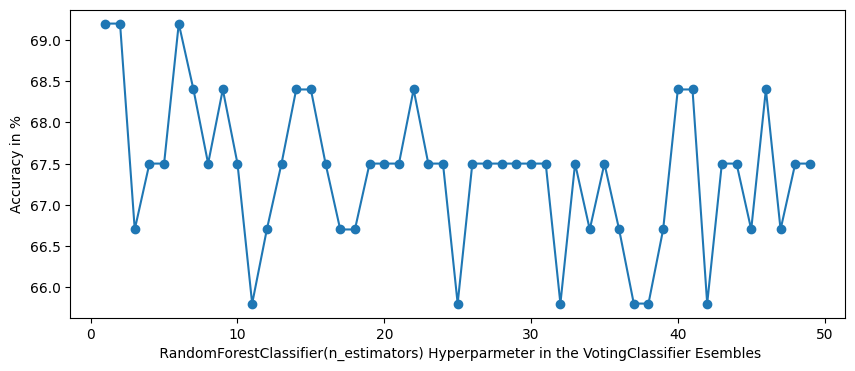

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)


# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
accuracies = []

n_numbers_estimators= list(range(1,50));  # Define the range of hyperparameter values we're interested in

model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modles
for number_range in n_numbers_estimators:
  model2.set_params(n_estimators = number_range)
  # the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
  model = VotingClassifier(estimators=[('knn',model1),('nb',model2),('dt',model3)],voting='soft')
  # Use the model to generate predictions for our testing examples
  model.fit(train_examples,train_labels)
  predictions = model.predict(test_examples)
  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(test_labels, predictions)
  print("Accuracy at test ",number_range," :", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100,1))
#ploting into a graph
plt.figure(figsize=(10,4))
plt.plot(n_numbers_estimators, accuracies, marker='o', linestyle='-')
plt.xlabel(' RandomForestClassifier(n_estimators) Hyperparmeter in the VotingClassifier Esembles')
plt.ylabel('Accuracy in %')

## Investigation Hyperparameter for VotingClassifier Esembles Model with Hyperparameter of other models ( RandomForestClassifer: N_estimator hyperprameter) with k-fold cross-validation and stratifying and validation and pipline with clean data

The code cell calculates and evaluates a VotingClassifier that combines RandomForestClassifier, SVC, and DecisionTreeClassifier, with the implementation of validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying, together with an 80/20 split and shuffling, with the inclusion of tuning the RandomForestClassifier n_estimators hyperparameter, resulting in the highest accuracy of 74.0% at values between 0.0 and 0.1 during fold 4.

Average accuracy: 0.698 (or 69.8%)
Average accuracy: 0.675 (or 67.5%)
Average accuracy: 0.677 (or 67.7%)
Average accuracy: 0.681 (or 68.1%)
Average accuracy: 0.694 (or 69.4%)
Average accuracy: 0.675 (or 67.5%)
Average accuracy: 0.666 (or 66.6%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.672 (or 67.2%)
Average accuracy: 0.677 (or 67.7%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.677 (or 67.7%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.675 (or 67.5%)
Average accuracy: 0.688 (or 68.8%)
Average accuracy: 0.668 (or 66.8%)
Average accuracy: 0.675 (or 67.5%)
Average accuracy: 0.675 (or 67.5%)
Average accuracy: 0.677 (or 67.7%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.685 (or 68.5%)
Average accuracy: 0.

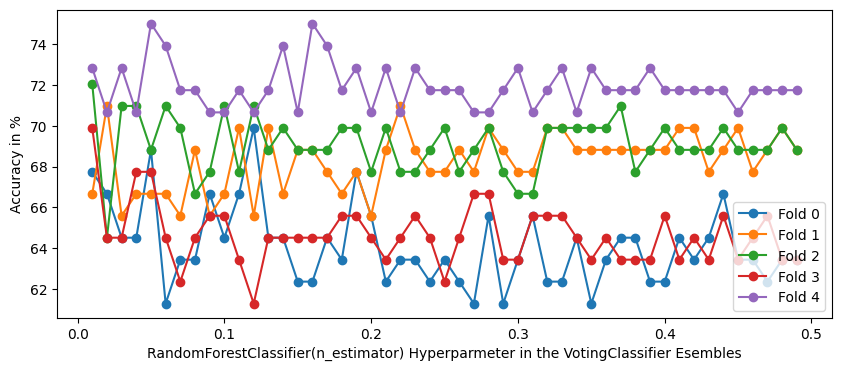

In [ ]:
## Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)


# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}

n_numbers_estimators= list(range(1,50));  # Define the range of hyperparameter values we're interested in
model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modles
# Use the model to generate predictions for our testing examples
for number_range in n_numbers_estimators:

  # the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
  pipeline = Pipeline([('scaler', StandardScaler()), ('model',VotingClassifier(estimators=[('svc',model1),('RF',model2),('dt',model3)],voting='soft'))])
  pipeline.set_params(model__RF__n_estimators = number_range)
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
  print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")# Load all the observations from file

#ploting into a graph
  for fold_i, accuracies_result in enumerate(accuracies):
   fold_accuracies[fold_i].append(accuracies_result * 100)
# Add legend entries for each split
plt.figure(figsize=(10,4))
lines = []
labels = []

for i in number_splits_fold:
    line, = plt.plot(gammas,
                     fold_accuracies[i],
                     marker='o',
                     linestyle='-')
    lines.append(line)
    labels.append(f"Fold {i}")

plt.legend(lines, labels, loc="lower right")
plt.xlabel("RandomForestClassifier(n_estimator) Hyperparmeter in the VotingClassifier Esembles")
plt.ylabel("Accuracy in %")
plt.show()


##  Precision and Recall Score: VotingClassifier Esembles Model with Hyperparameter of other models ( RandomForestClassifer: N_estimator hyperprameter)

This illustrates the precision and recall scores of the VotingClassifier Esembles Model with the inclusion of the N_estimator hyperparameter for RandomForestClassifer. The recall is at 80%, and the precision is at 81%.

In [ ]:
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (e.g., "1")
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")

Precision: 0.80
Recall Score: 0.80


## Confusion Matrix: for VotingClassifier Esembles Model with Hyperparameter of other models ( RandomForestClassifer: N_estimator hyperprameter)

This is the confusion matrix for the N_estimator  hyperparameter for RandomForestClassifer which is in the VotingClassifier Esembles Model.

Confusion Matrix:
[[19 15]
 [17 66]]


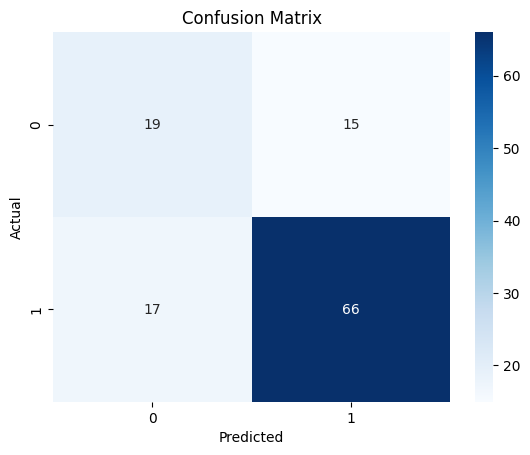

In [ ]:
## Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)


# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}
#accuracies_result = []
n_numbers_estimators= list(range(1,50));  # Define the range of hyperparameter values we're interested in
model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modles
# Use the model to generate predictions for our testing examples
for number_range in n_numbers_estimators:

  # the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
  pipeline = Pipeline([('scaler', StandardScaler()), ('model',VotingClassifier(estimators=[('svc',model1),('RF',model2),('dt',model3)],voting='soft'))])
  pipeline.set_params(model__RF__n_estimators = number_range)
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


The confusion matrix shows that the Esembles Model with N_estimator hyperprameter for RandomForestClassifer was able to identify 66 true negatives and 18 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 17 as false positives. This is incorrect as they are negative cases. While identifying 16 cases as negative but they are actually positive cases.

 ##ROC: for VotingClassifier Ensemble Model with Hyperparameter of other models (RandomForestClassifier: N_estimator hyperparameter)

This is the ROC curve of the VotingClassifier ensemble model, with the inclusion of the n_estimators hyperparameter for the RandomForestClassifier, which gives an ROC score of 0.75.

ROC AUC: 0.75


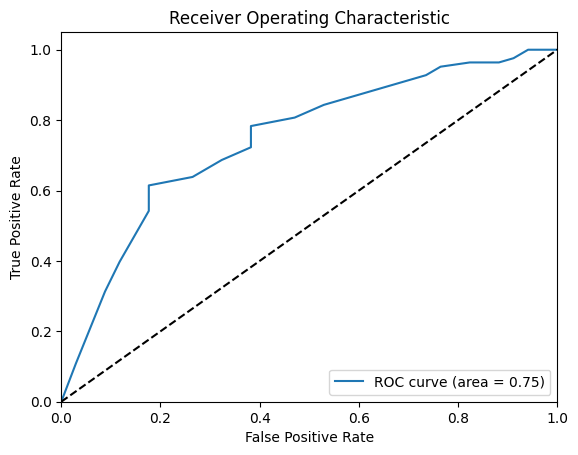

In [ ]:
## Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)


# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}
#accuracies_result = []
n_numbers_estimators= list(range(1,50));  # Define the range of hyperparameter values we're interested in
model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modles
# Use the model to generate predictions for our testing examples
for number_range in n_numbers_estimators:

  # the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
  pipeline = Pipeline([('scaler', StandardScaler()), ('model',VotingClassifier(estimators=[('svc',model1),('RF',model2),('dt',model3)],voting='soft'))])
  pipeline.set_params(model__RF__n_estimators = number_range)
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Plot the ROC curve
print(f"ROC AUC: {roc_auc:.2f}")
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well.

# Investigation Hyperparameter for VotingClassifier Ensemble Model with Hyperparameter of other models(DecisionTreeClassifier: min_samples_split)

The code cell calculates and evaluates a VotingClassifier ensemble using the DecisionTreeClassifier min_samples_split hyperparameter and a 60/40 split with shuffling, resulting in the highest accuracy at 74% when  min_samples_split was bettween 40 and 50 .

Accuracy at test  49  : 0.5854700854700855 (or 58.5 %)
Accuracy at test  49  : 0.6068376068376068 (or 60.7 %)
Accuracy at test  49  : 0.6025641025641025 (or 60.3 %)
Accuracy at test  49  : 0.6196581196581197 (or 62.0 %)
Accuracy at test  49  : 0.6153846153846154 (or 61.5 %)
Accuracy at test  49  : 0.6153846153846154 (or 61.5 %)
Accuracy at test  49  : 0.6282051282051282 (or 62.8 %)
Accuracy at test  49  : 0.6324786324786325 (or 63.2 %)
Accuracy at test  49  : 0.6452991452991453 (or 64.5 %)
Accuracy at test  49  : 0.6282051282051282 (or 62.8 %)
Accuracy at test  49  : 0.6239316239316239 (or 62.4 %)
Accuracy at test  49  : 0.6324786324786325 (or 63.2 %)
Accuracy at test  49  : 0.6452991452991453 (or 64.5 %)
Accuracy at test  49  : 0.6367521367521367 (or 63.7 %)
Accuracy at test  49  : 0.6367521367521367 (or 63.7 %)
Accuracy at test  49  : 0.6282051282051282 (or 62.8 %)
Accuracy at test  49  : 0.6538461538461539 (or 65.4 %)
Accuracy at test  49  : 0.6623931623931624 (or 66.2 %)
Accuracy a

Text(0, 0.5, 'Accuracy in %')

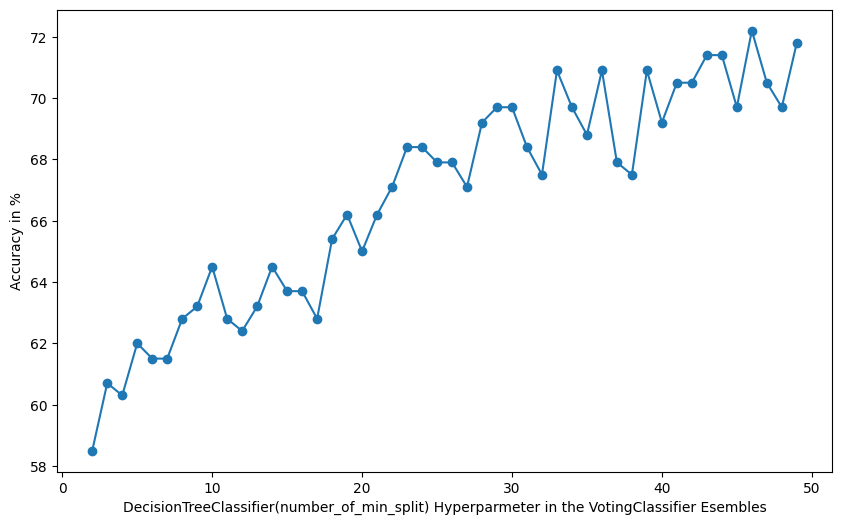

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
accuracies = []
number_of_min_split= list(range(2,50));  # Define the range of hyperparameter values we're interested in

model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modle
for number_of_min in number_of_min_split:

  model3.set_params(min_samples_split = number_of_min) # setting up the parameters
  # the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
  model = VotingClassifier(estimators=[('svc',model1),('rf',model2),('dt',model3)],voting='soft')
  # Use the model to generate predictions for our testing examples
  model.fit(train_examples,train_labels)
  predictions = model.predict(test_examples)
  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(test_labels, predictions)
  print("Accuracy at test ",number_range," :", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100,1))
#ploting into a graph
plt.figure(figsize=(10,6))
plt.plot(number_of_min_split, accuracies, marker='o', linestyle='-')
plt.xlabel('DecisionTreeClassifier(number_of_min_split) Hyperparmeter in the VotingClassifier Esembles')
plt.ylabel('Accuracy in %')

## Investigation of Hyperparameters for VotingClassifier Ensemble Model with Hyperparameters of other models(DecisionTreeClassifier: min_samples_split) with validation, stratifying, and clean data

This code cell calculates and evaluates a VotingClassifier that combines RandomForestClassifier, SVC, and DecisionTreeClassifier with validation, stratifying, cleaned data, and an 80/20 split with shuffling, while tuning the DecisionTreeClassifier min_samples_split hyperparameter. The highest accuracy of around 70% was observed when min_samples_split was between 40 and 50.

Accuracy at test  49  : 0.6752136752136753 (or 67.5 %)
Accuracy at test  49  : 0.6581196581196581 (or 65.8 %)
Accuracy at test  49  : 0.6495726495726496 (or 65.0 %)
Accuracy at test  49  : 0.6581196581196581 (or 65.8 %)
Accuracy at test  49  : 0.6495726495726496 (or 65.0 %)
Accuracy at test  49  : 0.6495726495726496 (or 65.0 %)
Accuracy at test  49  : 0.6495726495726496 (or 65.0 %)
Accuracy at test  49  : 0.6666666666666666 (or 66.7 %)
Accuracy at test  49  : 0.6666666666666666 (or 66.7 %)
Accuracy at test  49  : 0.6666666666666666 (or 66.7 %)
Accuracy at test  49  : 0.6410256410256411 (or 64.1 %)
Accuracy at test  49  : 0.6410256410256411 (or 64.1 %)
Accuracy at test  49  : 0.6410256410256411 (or 64.1 %)
Accuracy at test  49  : 0.6495726495726496 (or 65.0 %)
Accuracy at test  49  : 0.6324786324786325 (or 63.2 %)
Accuracy at test  49  : 0.6324786324786325 (or 63.2 %)
Accuracy at test  49  : 0.6495726495726496 (or 65.0 %)
Accuracy at test  49  : 0.6239316239316239 (or 62.4 %)
Accuracy a

Text(0, 0.5, 'Accuracy in %')

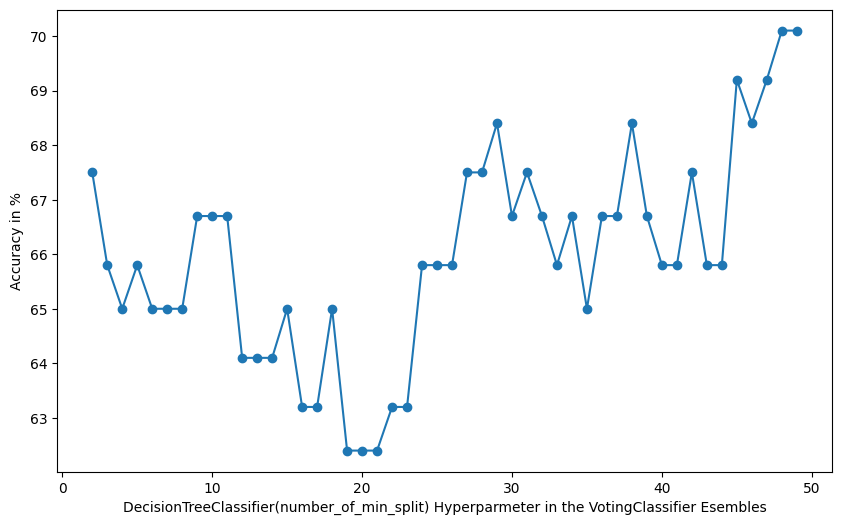

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)


# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
accuracies = []
number_of_min_split= list(range(2,50));  # Define the range of hyperparameter values we're interested in

model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modle


for number_of_min in number_of_min_split:

  model3.set_params(min_samples_split = number_of_min) # setting up the parameters
  # the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
  model = VotingClassifier(estimators=[('knn',model1),('nb',model2),('dt',model3)],voting='soft')
  # Use the model to generate predictions for our testing examples
  model.fit(train_examples,train_labels)
  predictions = model.predict(test_examples)
  # Calculate the model's accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(test_labels, predictions)
  print("Accuracy at test ",number_range," :", accuracy, "(or", round(accuracy * 100, 1), "%)")

  accuracies.append(round(accuracy*100,1))
#ploting into a graph
plt.figure(figsize=(10,6))
plt.plot(number_of_min_split, accuracies, marker='o', linestyle='-')
plt.xlabel('DecisionTreeClassifier(number_of_min_split) Hyperparmeter in the VotingClassifier Esembles')
plt.ylabel('Accuracy in %')

## Investigation Hyperparameters for VotingClassifier Esembles Model with Hyperparameters of other models(DecisionTreeClassifier: min_samples_split) with k-fold cross-validation, stratifying, validation, and clean data and pipeline

The code cell calculates and evaluates a VotingClassifier that combines RandomForestClassifier, SVC, and DecisionTreeClassifier, with the implementation of validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying, together with an 80/20 split and shuffling, with the inclusion of tuning the DecisionTreeClassifier min_samples_split hyperparameter, resulting in the highest accuracy of around 74.0% at values between 30 and 40 during fold 4.

Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.688 (or 68.8%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.685 (or 68.5%)
Average accuracy: 0.688 (or 68.8%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.681 (or 68.1%)
Average accuracy: 0.681 (or 68.1%)
Average accuracy: 0.690 (or 69.0%)
Average accuracy: 0.675 (or 67.5%)
Average accuracy: 0.672 (or 67.2%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.675 (or 67.5%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.666 (or 66.6%)
Average accuracy: 0.662 (or 66.2%)
Average accuracy: 0.666 (or 66.6%)
Average accuracy: 0.668 (or 66.8%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.666 (or 66.6%)
Average accuracy: 0.666 (or 66.6%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.679 (or 67.9%)
Average accuracy: 0.677 (or 67.7%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.670 (or 67.0%)
Average accuracy: 0.668 (or 66.8%)
Average accuracy: 0.

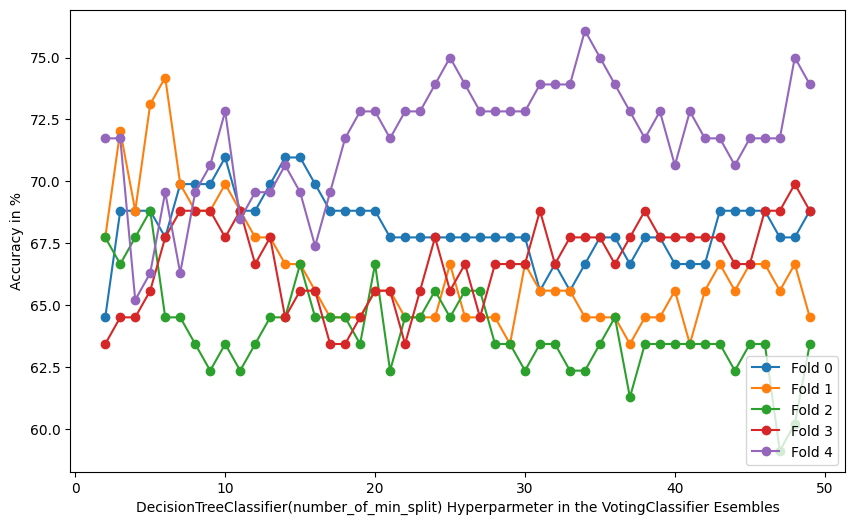

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()
# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}

model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modle
#accuracies_result = []
number_of_min_split= list(range(2,50));  # Define the range of hyperparameter values we're interested in
for number_of_min in number_of_min_split:
    # the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
  pipeline = Pipeline([('scaler', StandardScaler()), ('model',VotingClassifier(estimators=[('svc',model1),('rf',model2),('dt',model3)],voting='soft'))])
  pipeline.set_params(model__dt__min_samples_split = number_of_min) # setting up the parameters

  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')
  print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")# Load all the observations from file

#ploting into a graph

  for fold_i, accuracies_result in enumerate(accuracies):
   fold_accuracies[fold_i].append(accuracies_result * 100)
# Add legend entries for each split
plt.figure(figsize=(10,6))
lines = []
labels = []

for i in number_splits_fold:
    line, = plt.plot(number_of_min_split,
                     fold_accuracies[i],
                     marker='o',
                     linestyle='-')
    lines.append(line)
    labels.append(f"Fold {i}")
# Show evaluation results graphically
plt.legend(lines, labels, loc="lower right")
plt.xlabel("DecisionTreeClassifier(number_of_min_split) Hyperparmeter in the VotingClassifier Esembles")
plt.ylabel("Accuracy in %")
plt.show()

## Precision and Recall Score: VotingClassifier Esembles Model with Hyperparameter of other models(DecisionTreeClassifier: min_samples_split)

This illustrates the precision and recall scores of the VotingClassifier Esembles Model with the inclusion of themin_samples_split hyperparameter for DecisionTreeClassifier. The recall is at 92%, and the precision is at 73%.

In [ ]:
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (e.g., "1")
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")

Precision: 0.74
Recall Score: 0.92


## Confusion Matrix: VotingClassifier Esembles Model with Hyperparameter of other models(DecisionTreeClassifier: min_samples_split)

This is the confusion matrix for the min_samples_split  hyperparameter for DecisionTreeClassifier which is in the VotingClassifier Esembles Model.

Confusion Matrix:
[[ 8 26]
 [ 6 77]]


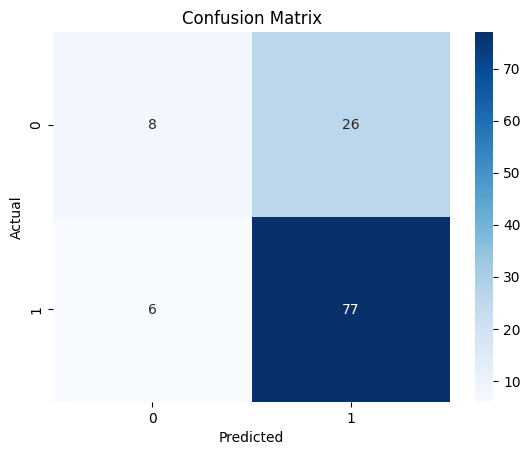

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()
# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}

model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modle
#accuracies_result = []
number_of_min_split= list(range(2,50));  # Define the range of hyperparameter values we're interested in
for number_of_min in number_of_min_split:

  pipeline.set_params(model__dt__min_samples_split = number_of_min) # setting up the parameters
  # the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
  pipeline = Pipeline([('scaler', StandardScaler()), ('model',VotingClassifier(estimators=[('svc',model1),('rf',model2),('dt',model3)],voting='soft'))])
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the Esembles Model with N_estimator hyperprameter for RandomForestClassifer was able to identify 76 true negatives and 8 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 7 as false positives. This is incorrect as they are negative cases. While identifying 26 cases as negative but they are actually positive cases.

## ROC: VotingClassifier Esembles Model with Hyperparameter of other models(DecisionTreeClassifier: min_samples_split)

This is the ROC curve of the VotingClassifier ensemble model, with the inclusion of the min_samples_split hyperparameter for the DecisionTreeClassifier, which gives an ROC score of 0.75.

ROC AUC: 0.75


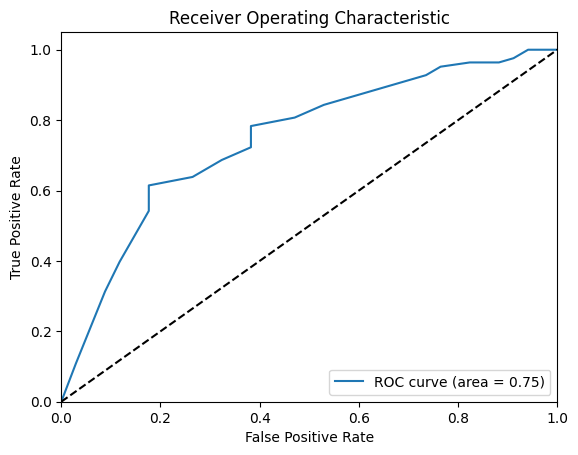

In [ ]:
# Import the packages we need
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()
# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
number_splits_fold = list(range(skf.n_splits))
fold_accuracies = {i: [] for i in number_splits_fold}

model1 = SVC(random_state=99,probability=True)
model2 = RandomForestClassifier() # diffreint modles
model3 = DecisionTreeClassifier(random_state= 99) # diffreint modle
#accuracies_result = []
number_of_min_split= list(range(2,50));  # Define the range of hyperparameter values we're interested in
for number_of_min in number_of_min_split:

  pipeline.set_params(model__dt__min_samples_split = number_of_min) # setting up the parameters
  # the voiting classifier learns from a collection of several modles and averages it out based on the voting classifer( which are hard voting or soft voting).
  pipeline = Pipeline([('scaler', StandardScaler()), ('model',VotingClassifier(estimators=[('svc',model1),('rf',model2),('dt',model3)],voting='soft'))])
  accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Plot the ROC curve
print(f"ROC AUC: {roc_auc:.2f}")
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well.

# Esembles Model 2: BaggingClassifier

Answer: the follwoing esembles BaggingClassifier  modle code showes an accuracy of 0.671 or (67.1%)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

# set the details of the classifier we want to use (default hyperparameters)
model_dt = DecisionTreeClassifier(random_state=99)

# Create a bagging ensemble classifier componsed of 100 DTs
#the BaggingClassifier is a modle that combines multiple models to make a stronger overall model.
# futhermore  Bagging trains multiple versions of the same model on different random subset( or smaller groups of examples) and then combines their predictions.
model = BaggingClassifier(model_dt, n_estimators=100, random_state=99)

# Fit the model to our training data
model.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = model.predict(test_examples)

# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.6709401709401709 (or 67.1 %)


##   BaggingClassifier Esembles Model with validation, stratifying, and clean data

The code cell calculates and evaluates a BaggingClassifier Esembles Model that implements validation, stratifying and clean data with the additional 80/20 split and shuffle, resulting in an accuracy of 0.726 or (72.6%).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()


# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)

# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)

# set the details of the classifier we want to use (default hyperparameters)
model_dt = DecisionTreeClassifier(random_state=99)

# Create a bagging ensemble classifier componsed of 100 DTs
#the BaggingClassifier is a modle that combines multiple models to make a stronger overall model.
# futhermore  Bagging trains multiple versions of the same model on different random subset( or smaller groups of examples) and then combines their predictions.
model = BaggingClassifier(model_dt, n_estimators=100, random_state=99)

# Fit the model to our training data
model.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = model.predict(test_examples)

# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")

Accuracy: 0.7264957264957265 (or 72.6 %)


## BaggingClassifier Esembles Model with validation, stratifying, and clean data, and k-cross fold validation, and pipeline




The code cell calculates and evaluates a BaggingClassifier Esembles Model that implements validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying together with an 80/20 split and shuffling, resulting in an average accuracy of 0.696 (69.6%).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
# set the details of the classifier we want to use (default hyperparameters)
model_dt = DecisionTreeClassifier(random_state=99)
pipeline = Pipeline([('scaler', StandardScaler()), ('model',BaggingClassifier(model_dt, n_estimators=100, random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")# Load all the observations from file


[0.70967742 0.68817204 0.66666667 0.66666667 0.75      ]
Average accuracy: 0.696 (or 69.6%)


# Precision and Recall score: BaggingClassifier Ensemble Model

The following shows the Precision and recall scores for the BaggingClassifier Esembles Model . The precision score indicates that 81% of the models 'yes' predictions were correct.

The Recall score correctly identified 86% of the actual yes cases.

In [ ]:
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (e.g., "1")
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")

Precision: 0.81
Recall Score: 0.86


## Confusion Matrix: BaggingClassifier Ensemble Model

This is the confusion matrix of the final version of the base BaggingClassifier Esembles model with the implementation of pipeline, K-fold cross-validation (5-fold),stratifying, clean data, and validation.

Confusion Matrix:
[[17 17]
 [12 71]]


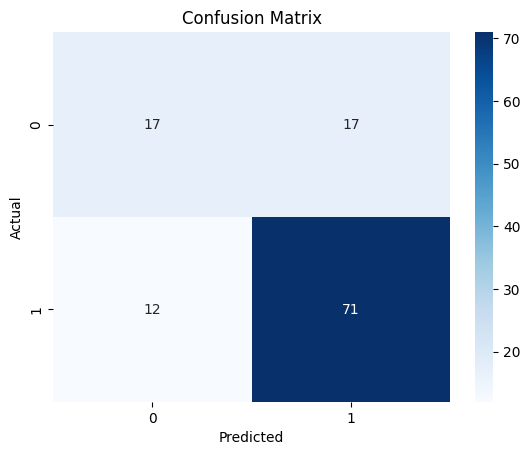

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
# set the details of the classifier we want to use (default hyperparameters)
model_dt = DecisionTreeClassifier(random_state=99)
pipeline = Pipeline([('scaler', StandardScaler()), ('model',BaggingClassifier(model_dt, n_estimators=100, random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the Esembles Model was able to identify 71 true negatives and 17 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 12 as false positives. This is incorrect as they are negative cases. While identifying 17 cases as negative but they are actually positive cases.

## ROC: BaggingClassifier Esembles Model


This is the ROC curve of the  BaggingClassifier Esembles Model with a ROC score of 0.75.

ROC AUC: 0.75


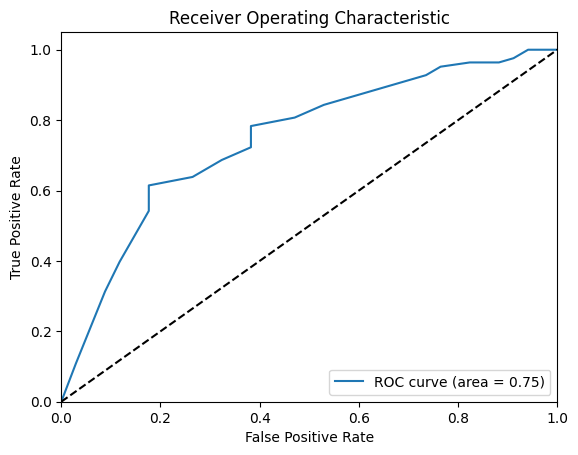

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
# set the details of the classifier we want to use (default hyperparameters)
model_dt = DecisionTreeClassifier(random_state=99)
pipeline = Pipeline([('scaler', StandardScaler()), ('model',BaggingClassifier(model_dt, n_estimators=100, random_state=99))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Plot the ROC curve
print(f"ROC AUC: {roc_auc:.2f}")
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well.

# BaggingClassifier Esembles Model Hyperparmeter (bootstrap_features) & (bootstrap)

The code cell calculates and evaluates a BaggingClassifier Esembles Model using the bootstrap_features and bootstrap hyperparameter and a 60/40 split with shuffling, resulting in a accuracy of 0.696 or(69.7%)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

# Split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()

# Shuffle and split into training data (60%) and testing data (40%)
train_examples, test_examples, train_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.4,
    random_state=99,
    shuffle=True
)

# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
# set the details of the classifier we want to use (default hyperparameters)
model_dt = DecisionTreeClassifier(random_state=99)
  # Create a bagging ensemble classifier componsed of 100 DTs
  #the BaggingClassifier is a modle that combines multiple models to make a stronger overall model.
  # futhermore  Bagging trains multiple versions of the same model on different random subset( or smaller groups of examples) and then combines their predictions.
model = BaggingClassifier(model_dt, n_estimators=100, random_state=99,bootstrap_features = True,bootstrap=True)
 # Fit the model to our training data
model.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = model.predict(test_examples)
# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)

print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")


Accuracy: 0.6965811965811965 (or 69.7 %)


## BaggingClassifier Esembles Model Hyperparameter (bootstrap_features) & (bootstrap) with validation, stratifying and clean data

This shows the percentage accuracy calculated for the BaggingClassifier Esembles Model Hyperparmeter bootstrap_features and bootstrap, with the implementation of clean data, validation, stratification, and shuffling. The accuarcy is 0.744 or (74.4%).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'
# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Shuffle and split into training data (60%) and testing data (20%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels  # notice the new final argument
)
# Create a new StandardScaler object, ready to do z-score standardisation
scaler = StandardScaler()
# Compute means and standard deviations for each feature in the training data
scaler.fit(train_examples)
# Divide individual feature values in the training data by their respective means and standard deviations:
train_examples = scaler.transform(train_examples)
# Apply the same transformation to the testing examples
test_examples = scaler.transform(test_examples)
# set the details of the classifier we want to use (default hyperparameters)
model_dt = DecisionTreeClassifier(random_state=99)
  # Create a bagging ensemble classifier componsed of 100 DTs
  #the BaggingClassifier is a modle that combines multiple models to make a stronger overall model.
  # futhermore  Bagging trains multiple versions of the same model on different random subset( or smaller groups of examples) and then combines their predictions.
model = BaggingClassifier(model_dt, n_estimators=100, random_state=99,bootstrap_features = True,bootstrap=True)
 # Fit the model to our training data
model.fit(train_examples, train_labels)

# Use the model to generate predictions for our testing examples
predictions = model.predict(test_examples)
# Calculate the model's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)

print("Accuracy:", accuracy, "(or", round(accuracy * 100, 1), "%)")


Accuracy: 0.7435897435897436 (or 74.4 %)


## BaggingClassifier Esembles Model Hyperparameter (bootstrap_features) & (bootstrap) with k-fold cross validation, pipeline, stratifying, and validation, and clean data.

The code cell calculates and evaluates a BaggingClassifier ensemble model using the bootstrap_features and bootstrap hyperparameters, with validation, K-fold cross-validation (5 folds), cleaned data, a pipeline, and stratifying, together with an 80/20 split and shuffling, resulting in an average accuracy of 0.688 (68.8%).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
# set the details of the classifier we want to use (default hyperparameters)
model_dt = DecisionTreeClassifier(random_state=99)
pipeline = Pipeline([('scaler', StandardScaler()), ('model',BaggingClassifier(model_dt, n_estimators=100, random_state=99,bootstrap_features = True,bootstrap=True))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Display all the accuracies, one per fold
print(accuracies)

# Display the average accuracy
print(f"Average accuracy: {np.mean(accuracies):.3f} (or {np.mean(accuracies) * 100:.1f}%)")# Load all the observations from file

[0.69892473 0.67741935 0.64516129 0.67741935 0.73913043]
Average accuracy: 0.688 (or 68.8%)


## Precision and Recall score: BaggingClassifier Ensemble Model Hyperparameter

The following shows the Precision and recall scores for the BaggingClassifier Esembles Model with hyperparmenter bootstrap_features and bootstrap . The precision score indicates that 77% of the models 'yes' predictions were correct.

The Recall score correctly identified 87% of the actual yes cases.


In [ ]:
from sklearn.metrics import precision_score, recall_score
pipeline.fit(non_test_examples,non_test_labels)
y_pred = pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (e.g., "1")
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(test_labels, y_pred, pos_label=1)
print(f"Recall Score: {recall1:.2f}")

Precision: 0.77
Recall Score: 0.87


## Confusion Matrix: BaggingClassifier Ensemble Model Hyperparameter

This is the confusion matrix of the final version of the base BaggingClassifier ensemble model using the bootstrap_features and bootstrap hyperparameters, together with a pipeline, K-fold cross-validation (5 folds), stratifying, cleaned data, and validation.

Confusion Matrix:
[[13 21]
 [11 72]]


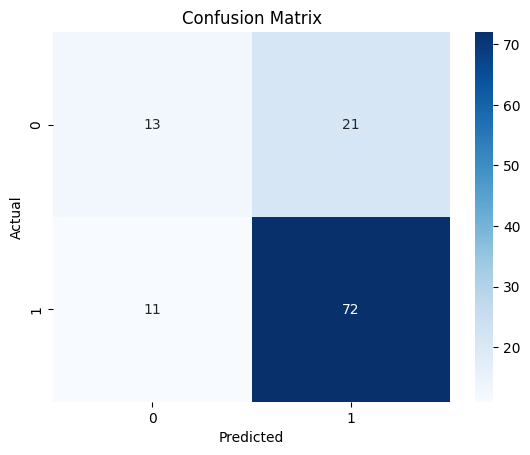

In [ ]:
# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
# set the details of the classifier we want to use (default hyperparameters)
model_dt = DecisionTreeClassifier(random_state=99)
pipeline = Pipeline([('scaler', StandardScaler()), ('model',BaggingClassifier(model_dt, n_estimators=100, random_state=99 ,bootstrap_features = True,bootstrap=True))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(pipeline, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Train the model
pipeline.fit(non_test_examples,non_test_labels)
# Make predictions
y_pred = pipeline.predict(test_examples)
# Generate the confusion matrix
cm = confusion_matrix(test_labels,y_pred)
print("Confusion Matrix:")
print(cm)
# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The confusion matrix shows that the Esembles Model with bootstrap_features and bootstrap hyperprameter for BaggingClassifier Esemble  was able to identify 72 true negatives and 13 true positives, which is correct, as these are the actual negative cases and positive cases. Furthermore, it identified 11 as false positives. This is incorrect as they are negative cases. While identifying 21 cases as negative but they are actually positive cases.

## ROC: BaggingClassifier Esemble Model Hyperparameter

This is the ROC curve of the BaggingClassifier ensemble model, with the inclusion of the bootstrap_features and bootstrap hyperparameter that gives an ROC score of 0.75.

ROC AUC: 0.75


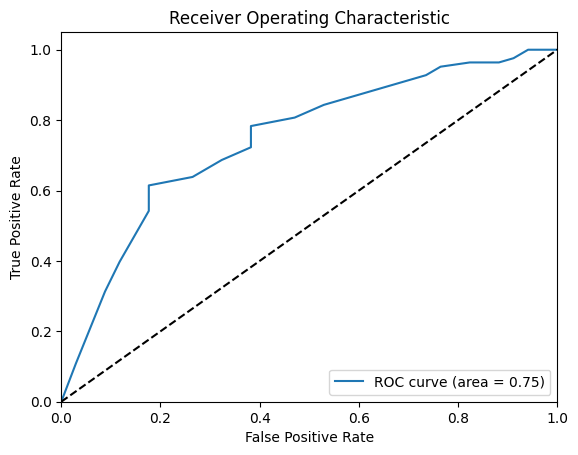

In [ ]:
# Load all the observations from file
observations = pd.read_csv('pneumonia_raw.csv')

# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_cleaning.drop(columns=target_feature).to_numpy()
labels = observations_cleaning[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels  # notice the new final argument
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))
# set the details of the classifier we want to use (default hyperparameters)
model_dt = DecisionTreeClassifier(random_state=99)
pipeline = Pipeline([('scaler', StandardScaler()), ('model',BaggingClassifier(model_dt, n_estimators=100, random_state=99,bootstrap_features = True,bootstrap=True))])

# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
accuracies = cross_val_score(model, non_test_examples, non_test_labels, cv=indices, scoring='accuracy')

# Plot the ROC curve
print(f"ROC AUC: {roc_auc:.2f}")
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

This ROC curve shows that the modle performance is good. This means that the modle can distigush bettween the class well.

## Aiming for higher marks

Broadly speaking, for higher marks you need to: evaluate extra models; evaluate the impact of relevant hyperparameters; evaluate ensembles of relevant models; take steps to improve your recipe; justify those recipe changes in the relevant text cells. See the assignment specification for full details.

As you make improvements to your code and text cells, it's no problem temporarily to leave old code/text cells in the notebook (e.g., for safety, cross-checking). But by the time you come to submit your work, try to remove your old work and leave us just with your final approach for marking.

Task 1 code that meets the requirements of the higher marking bands also meets the requirements of the lower ones. So we only need to see where your investigation ended up, and not all the intermediate steps you took to get it there.

Any questions, don't hesitate to ask.

# Task 2



> Colleague's claim: "*Instead of non-medical staff trying to extract relevant measurements from x-rays manually, we can classify the raw x-ray image data directly; it should be possible to get improved performance, and save on staff time, without any downsides*"



## Basic structure

There is pretty much complete freedom in how you structure your analysis for task 2. Please just use plenty of section headings to keep your approach clear. Switching on the table of contents (View->Table of contents) should give us a good overview of how you have structured your analysis.

Beyond that, it's a case of adding as many text and code cells as you want/need in order to complete your analysis.

Notice that there is more than one aspect to the claim. Thinking about each aspect in turn (and potential links between them) may help you to structure your work on this task.

# Introduction to the Colleagues claim.

In this section, we are analysing whether extracting relevant measurements from X-rays manually is better than classifying the raw, unprocessed X-ray image data into the model directly. The analysis focuses on key components of feature extraction, including how each component works and its impact on the colleague's claim. Furthermore, we will examine how extracted measurements will affect performance on models compared to training a model on raw, unprocessed image data, in order to see if the colleague's claim is valid. In addtion to this we will see if it improves


# The basic understanding of the question and its effects.

The colleague claims that manually extracting relevant measurements from X-rays by non-medical staff is unnecessary, and that they should input the raw image data directly into the model. This claim is understandable, as some models are capable of image classification.



In addition, the colleague mentioned that it will save on staff time and improve performance, which appears plausible and would need evidence to support it. However, the college claims that there are no downsides, is questionable and would require evidence to prove this statement




# **featuer Extraction Vs Raw Image models:**




###**What is Feature Engineering ? :**

Before we get into featuer extraction we need to undrstand what featuere enginering is as feaurer engineering is the main catgory that feature extraction is under.

In short featuer enginering is the ' art of preparing the data in a way that makes it easier for machin learining modles to undrstand and learn from'(Julius, 2025).



###**what is Feautre extraction ? :**




Feature extraction is used in machine learning to convert raw data into a set of meaningful information by selecting the important details and discarding unnecessary ones.

An example of this is that when trying to identify fruits in a market, shoppers will consider numerous characteristics, such as weight, colour, texture, and shape. This is when they realise that they will only use a few key features, such as colour and size, to identify the differences between various fruits, like how they can distinguish an apple by its red colour and an orange by its orange colour and that is what feature extraction is: picking out important features in the data, like with the apple and the orange.

Feature extraction is typically performed mathematically and often reveals underlying patterns or structures that may not be immediately apparent in the original data.



### **why is feature extraction improtent in machine learning:**

Feature extraction is important because it enhances a model's accuracy and efficiency by selecting relevant features. Oftentimes, feature extraction is considered a preprocessing step that helps provide the model with better-quality input.
In contrast to this feature, extraction facilitates the management of high-dimensional datasets. This means that it addresses the issue of modern datasets having too many features, which can lead to several problems that feature extraction helps reduce. Examples of these are the curse of dimensionality. Feature extraction helps to stop this by 'creating a more compact representation that preserves important relationships while reducing the dimensionality' (Kumar, 2025). Additionally, they consume a significant amount of memory. It reduces this by retrieving only relevant features, which in turn can lower memory usage. The last one is data visualisation. It achieves this by reducing the dimensions to only two or three features, allowing for the visual plotting and understanding of the data structure.

Furthermore, they offer reduced computational complexity and prevent overfitting in machine learning models, which is achieved through lower computational requirements. This results in fewer features being input into the model, allowing for faster training times and efficient prediction generation. On top, they reduce memory usage during model deployment. In addition to this, they offer better generalisation as simpler feature spaces help prevent overfitting, which allows models to learn more robust patterns, which enables improved performance on new, unseen data.

Now that we understand the importance of feature extraction, we will examine the various methods for feature extraction and their implementation in image classification.






### **The diffrent types of featuer extraction**

Feature extraction is done in two ways. One is manual feature engineering, which involves using domain expertise to create relevant features from raw data. This form of manual approach relies on understanding the problem and data to make meaningful features.

The way manual feature engineering is used in image processing is through various methods such as 'edge detection to identify object boundaries, colour histograms to capture colour distribution, texture analysis to quantify patterns, and shape descriptors to characterise object geometry' (Kumar, 2025). Furthermore, manual feature engineering enables the selection of features that are highly relevant to the matter at hand, as feature details in this manner are more human-crafted, making them more understandable and straightforward to validate. Furthermore, it offers flexibility and precision, allowing practitioners to fine-tune transformation.



The one negative aspect is that they become difficult to scale with very high-dimensional data.



The second type of feature extraction is through automated feature engineering. This type of feature extraction uses machine learning models and tools like Featuretools, DataRobot and H20.ai to automatically produce, choose and modify features that often explore a much larger feature space than humans.

One of the advantages of automated feature engineering is that it enables the faster generation of numerous candidate features. Secondly, it can easily scale to larger datasets. Furthermore, once automated feature generation is set up, it can be applied to different datasets and cases, which allows it to excel in speed, scalability and reproducibility.

One negative aspect of automated feature engineering is that it can be challenging to understand which features are being used, resulting in analysts struggling to comprehend how the model arrives at its predictions. Automated feature engineering operates without deep domain context, which can lead to the production of irrelevant or redundant features. This means that it requires human intervention to review and refine the output.

The application of automated feature engineering in image processing involves using algorithms, such as Convolutional Neural Networks, to process raw pixel data and identify and isolate significant visual characteristics, attributes, or patterns within an image.



###**Different types of manual feature extraction techniques used for image data**

Studies show that manual feature extraction in image data is quite feasible, as it can utilise multiple techniques, such as the Histogram of Oriented Gradients (HOG). This technique works by capturing how the pixel brightness changes and the direction of those changes in small parts of the image. This process is computed by dividing the inserted image into blocks, which are further subdivided into cells of small spatial.

Furthermore, this feature is well documented to be used in medical purposes. An example of this is when the National Library of Medicine published an article on how some researchers needed to extract features from X-ray images of patients with  COVID-19-induced pneumonia, viral or bacterial pneumonia, and normal patients. They need to extract the useful features by using Histogram of Oriented Gradients (HOG). After the useful features were extracted, the researchers trained the model on a custom Convolutional Neural Network (CNN).
Another thing the researchers know is that the HOG can be used with a machine learning algorithm to perform complex detection and recognition tasks.


The second Manual Feature technique is SURF, or Speed up Robust Features. This is a manual feature extraction technique known for its robustness and speed. This feature achieves its speed by utilising box filters, which enable it to perform real-time tasks such as tracking and object recognition. Furthermore, it is used to reliably describe and detect important features in an image, even if the same object appears in images that differ in size, depth, angle, and lighting conditions. Additionally, SURF can reduce data loss in the high-quality data extraction process.

Moreover, this feature is used for medical purposes. An example of this is when Researchers used SURF to extract features from a neural network called a Multilayer Perceptron classifier with a hyperparameter learning rate. This tuned model was used to categorise Pneumonia disease and determine the level of accuracy. They did this by using SURF grayscale to minimise the colour space in the image by converting the RGB into a single colour space. This is then stored as a pattern model to be used in the testing phase. After the pattern model is trained, they will match the pattern model by using the Multilayer perceptron method. After that, they performed the classification process using a Multilayer perceptron with different learning rates, under the condition that the model would be trained on 100 epochs. With this condition, the model produces three tables that give values for Recall, Precision, F1-score, learning rate and accuracy. **Based on the results of the experiments, the accuracy, precision, recall, and f1-score obtained are relatively stable values,
with the lowest accuracy value being 78.4% and the highest
accuracy value being 82.8%, the lowest precision value being
.80.5% and the highest precision value being 82.8%, the lowest
recall value being 78.4% and the highest recall value being
82.8%, the lowest f1-score being 76.4% and the highest f1-score
being 82.8%.** (Ula, Muhathir and Sahputra, 2022)

The third manual feature technique is the Local Binary Pattern (LBP). This is a manual feature extraction technique known for extracting texture features successfully while maintaining processing simplicity. The idea behind LBP is that it involves comparing each pixel of an image with its adjacent pixels to encode the local texture information into a binary pattern. The result of the binary values obtained from the comparisons is put together in a clockwise fixed order, which forms an 8-digit binary number for each pixel. After combining them, a histogram is generated from the LBP, which serves as a feature vector for the image and is then directly utilised for classification purposes.

Additionally, this feature technique is heavily used in medical research. An example of this is when researchers used local binary pattern feature extraction for the detection of COVID-19 on computed tomography(CT) images. They did this by using three datasets that are merged to efficiently classify pneumonia and healthy individuals of COVID-19. Before training, the data was preprocessed by **resizing the images to 224 by 224, also, several data augmentation such as random reflection, random rotation, random rescale, random translation along X‐axis and random translation along Y‐axis was performed to increase the number of images, improves training and to reduce overfitting**(Mubarak et al., 2021).

The training for this study was carried out in stages using two classifier models, KNN and SVM. The first stage involved extracting textual features using Local Binary Pattern and classifying them with the two models. IN the second stage, high-level deep features were extracted from seven pre-trained models (MobileNetv2, GoogleNet, ResNet‐50, ResNet‐101, ShuffleNet, VGG16 and VGG19) and used to train the two classifier models. Furthermore, the last pooling layer of each of the pre-made models was used for training the KNN and SVM. The third stage involves concatenating LBP features and features from pre-made models, and then classifying them using the two classifier models, KNN and SVM.
The result given with the three classes of the  CT scan images of COVID-19 where the data was indvidule class of pneumonia and healthy individuals were classified using the SVM classier and LBP features as inputs gave an **accuracy of 97.5% sensitivity of 98.7% a specificity of 96.1%, F1 score of 97.5%, the precision of 96.4%, Yonden index of 94.8% and AUC of 97.4%.**(Mubarak et al., 2021). This model outperformed the KKN model, which used the same set of data and LBP features as input, as it performed better in every performance matrix than the SVM model. This shows that the SVM can efficiently detect COVID‐19, common pneumonia and healthy individuals' CT scan images based on LBP features extracted from the CT scan images. (Mubarak et al., 2021)





###  **What is Raw data ? :**

Before we understand raw images, we need to understand raw data, as raw data and raw images share many similarities.

Raw data is information that has not been pre-processed for use, and is data that 'remains in its original form upon collection'(Dremio,2025).

In the context of chest x-ray images, pixel intensity values represent the grey-level image. Furthermore, chest x-ray images in machine learning terms can be represented as high-dimensional spaces, where each image is viewed as a collection of many pixels, which are represented as dimensions in space or pixel space for image representation.


###**Why raw Image data can be challenging unless processed ?**

Raw images have numerous issues that confuse  AI models. Examples of these include excessive noise, missing parts, incorrect labels, and unusual lighting. Furthermore, some images might have different brightness levels. These problems cause the AI model to reduce its performance while classifying these images. Furthermore, most of the images will need to be resized, which can be a time-consuming process. Additionally, it may decrease the model's performance unless the raw image data has undergone image augmentation pre-processing.

###**why raw image data can be used**

Raw image data can be used if it is related to models that can process it. Examples of these types of models include Convolutional Neural Networks (CNNs) and Deep Neural Networks (DNNs). These models utilise a technique known as hidden layers to identify patterns in the raw image data, which enables each layer of the model to discover features automatically because it learns hierarchical representations of data. This is achieved by having each layer in the network process the input and pass the abstract features to the next layer. An example of this phenomenon in image classification is that the early layers may detect edges or textures, while later layers may identify complex shapes or objects.

Furthermore, DNN learns segmentation directly from the images by tuning the network parameters using labelled training data.







# min-conclusion for feature extraction and raw images, along with their link to the case study.  

Based on this section alone, using raw data has some benefits when used with Convolutional Neural Networks (CNNs) and Deep Neural Networks (DNNs), as they are capable of processing raw image data. However, the colleague's claim does not specify what model they are using. Based on the previous section, it would suggest that the college's claim of ***' we can classify the raw x-ray image data directly;' it should be possible to get improved performance*** may require more information at this point to check if it is viable with the unspecified model that they are using. Furthermore, with Colleague's claim of ***'we can classify the raw x-ray image data directly;' it should be possible to get improved performance***, which could suggest that this claim is not yet clear at the moment because raw data has a lot of noise, which may weaken the model's performance. However, this claim can still be valid, as there is no performance evidence to support it.


Furthermore, the colleges claimed that ***'Instead of non-medical staff trying to extract relevant measurements from x-rays manually'***. For the previous point on '**manually**', suggest that they might be using manual feature engineering. This indicates that they might be using known advantages of it like **'manual feature engineering enables the selection of features that are highly relevant to the matter at hand, as feature details in this manner are more human-crafted, making them more understandable and straightforward to validate'**(this is comes from the  section **diffrent types of featuer extraction**). However, more performance research will be needed to substantiate this claim more thoroughly in the future.

# Research Evidence

###**Performance Evidence information**

This section will talk about what exsting  reasrch papers and articales show about performance when it comes to uisng raw -x ray images compared to manual featuer extraction.futheremore we will compare each paper to one  indviudle exparement with completly raw data.  

### Performance Evidence(Paper vs Paper)

Studies demonstrate from various academic sources that the performance of CNN models trained on raw image data always involves some form of image preprocessing. The most common preprocessing for CNNs is resizing. The reason for this is that all CNNs require standard-sized input data with consistent dimensions and formats so that they can classify the image data. This suggests that the claim "**without any downsides**" might be dependent on how the preprocessing is done and how deeply it is preprocessed.



With respect to this understanding, a study has demonstrated the use of a deep learning approach for the automatic classification of X-ray images using a CNN. The objective of this study is to **use deep learning approach to predict 14 categories of diseases.** (Mondal, Agarwal and Rashid, 2019). In addition, the model that they are using is a **"pre-trained model called Xception, which is based on depthwise seperable convolutional layers [14]. It is a deep convolutional neural network which is trained on a popularly large dataset known as ImageNet which enables the network to classify images with good accuracies."** (Mondal, Agarwal and Rashid, 2019). As much as it states, the model is pre-trained in this reference. In the implementation section, it states that **We didn't used weights as ImageNet for the network.**(Mondal, Agarwal and Rashid, 2019). This means that during the entire experiment, they did not use the ImageNet dataset, indicating that they are using raw X-ray image data to train/test this model from scratch.


Furthermore, they implemented the NIH Clinical Centre, which is **one of the largest publicly available datasets of X-rays for research purposes** (Mondal, Agarwal, and Rashid, 2019). The data set consists of 112,120 x-ray images with disease labels from 30,805 unique patients. From this dataset, they are using only a random sample of 5% of the full dataset that is available publicly. From that 5%, there were 5,606 images, with each image size being 1024 x 1024 pixels. Furthermore, each image contained **information such as patient age, gender, ID, and the number of follow-up visits to the hospital** (Mondal, Agarwal, and Rashid, 2019). Furthermore, the dataset included **15 classes of common thorax diseases in the dataset, which include Atelectasis, Cardiomegaly, Consolidation, Edema, Emphysema, Effusion, Fibrosis, Hernia, Infiltration, Mass, Nodule, Pleural Thickening, Pneumonia and Pneumothorax, No Finding.**(Mondal, Agarwal and Rashid, 2019). During data preprocessing, they removed the 'no finding' label, as it served no purpose in their research. They also performed one-hot encoding **by which categorical variables can be read into binary values (0, 1) so that we can feed them into the network for better performance.** (Mondal, Agarwal and Rashid, 2019). In addition, they performed data augmentation to prevent overfitting by flipping each image   **"0, 90, 180, 270 degrees and left or right."** (Mondal, Agarwal and Rashid, 2019). Additionally, they have normalised the pixel intensities of input images instead of using raw pixel values. The reason for this is that **" It helps to avoid gradient values that could make training difficult"** (Mondal, Agarwal and Rashid, 2019). Finally, they resized the images from 1024×1024 to 128×128 to feed the model for faster processing. Furthermore, during preprocessing, the paper stated that **We have performed a multi-label classification to predict what image category was presented to a subject based on chest X-rays information.** (Mondal, Agarwal and Rashid, 2019). This means that one X-ray image may be associated with more than one disease.

After preprocessing, the model was split into a 75:25 train-test ratio, where 75% was used for training and the remaining 25% for testing the model. After classification, they used AUC and an accuracy matrix to evaluate the model's performance.

Based on these evaluation measures, the model achieved the highest AUC score of **0.83**(**please refer to the table below called AUC scores of predicted values**) on the Hernia disease and the lowest AUC score of **0.38** (**please refer to the table below called AUC scores of predicted values**) on cardiomegaly disease. Furthermore, they trained their model for 28 epochs, giving a final accuracy of **88.76%**.












Although CNN-based approaches process raw image data directly, with the help of minor pre-processing to facilitate the data fitting into the model. However, studies employing manual feature extraction techniques report performance under different experimental conditions, making direct comparison necessary. One example of this is when SURF was used to extract featuers from a neural networks called MLP( Multilayer Perceptron classifier) with hyperpramter learning rate to categorise Pneumonia disease and determine the level of accuracy with a epoch of 100 and integration of pre-processing to **guarantees that all of the photos are in the same
format and are free of noise that is irrelevant to the study**(Ula, Muhathir and Sahputra, 2022). The authors reported the minimum and maximum values for F1-score, Recall, precision, and accuracy, with ranges of 78.4% and 82.8%.

For the comparison of the two papers, the CNN-based approach yielded results for various diseases with corresponding AUC values. However, SURF was used in a Multilayer Perceptron classifier with different learning rates. Furthermore, the data set of both papers was different, with the CNN paper using a larger portion of public data that consists of 112,120 x-ray images and the SURF feature extraction paper using a smaller dataset that **consists of 5,863 X-Ray images** (Ula, Muhathir and Sahputra, 2022) that was taken from the popular dataset source Kaggle. Additionally, the dataset in the CNN paper included multiple disease classes, whereas the SURF paper had only two disease classes.


In another comparison between the CNN paper and another feature extraction technique called Local Binary Pattern (LBP). This extraction technique was used to extract features for COVID-19 from computed tomography (CT) images. They achieved this by merging three datasets to classify pneumonia, healthy individuals, and COVID-19. Furthermore, the data was pre-processed by resizing the image and performing several data augmentations to increase the number of images, improve training, and reduce overfitting. Afterwards, textual features were extracted using LBP, and those features were classified using KNN and SVM models. Additionally, high-level deep features were extracted from seven pre-trained models and utilised to train KNN and SVM.
Furthermore, the LBP features and features extracted from the pre-made models were concatenated and classified using KNN and SVM. With this final classification of the two models, the outcome was that the SVM with the LBP feature had the best **accuracy of 97.5% and AUC of 97.4%**. (Mubarak et al., 2021) which outperformed the KNN with the same data and LBP features.

In comparison with the CNN-based approach, this study demonstrates that the Local Binary Pattern, combined with well-known classifier models, achieves strong performance on CT scan images. Additionally, both papers employed standard pre-processing techniques, including resizing and augmentation. Furthermore, the LBP paper utilised a substantial amount of COVID-19 data and individual health data compared to pneumonia data, which may have influenced the classification performance. Furthermore, the data sets of both papers are similar in size. This suggests that performance was related to models for both papers.
Furthermore, the paper classes differ from one another, as CNN paper classes have 14 classes with multiple labels for each disease, whereas LBP paper classes have only 3 diseases. This makes it simpler, as each image only has one label, whereas the CNN paper model will have one image that relates to multiple labels. Furthermore, the accuracy and AUC of each paper showed only a slight difference compared to CNN, with an AUC of 83% and an accuracy of 88.76%. While the LBP paper gave 97.5% and an AUC of 97.4%. The high accuracy of the LBP paper stems from its classification of 3 classes. In contrast, the CNN papers utilise more complex data with 14 multi-class labels, which is likely to yield lower accuracy and AUC values. On a final note, each paper utilises different types of X-ray images, with the CNN paper using chest X-rays and the LBP paper using CT scans, which makes the comparisons different.







###### **AUC scores of predicted values:**





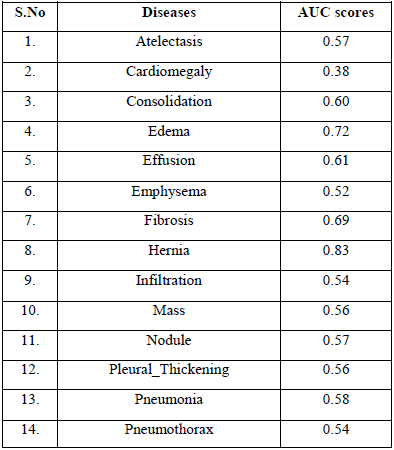

#### Table of three diseases with how much data each one has

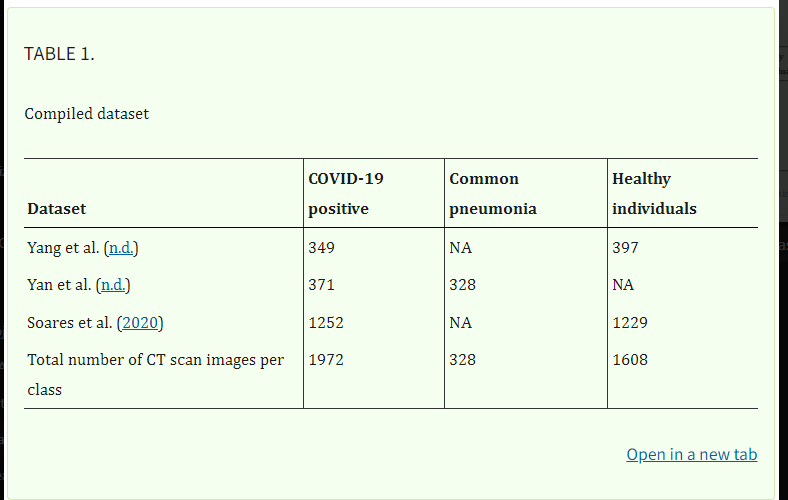

## Individual Experiment

this  overall experiemtn  model structure was taken by publicly available guidance on designing basic convolutional neural networks (Dutta, 2020). The source was used solely as a practical reference for model construction and did not influence the interpretation of the results.

In [ ]:
import kagglehub # improtation of kaggle to allow for data to be used.

# Download latest version and the downloads the chest-X ray
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
data_dir = path + "/chest_xray" # goes to the folder that has train,val,test
print(data_dir) # this confirms the data strucuter by printing its location

/kaggle/input/chest-xray-pneumonia/chest_xray


In [ ]:
data_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray"
# defines where training and validation and testing data is
train_dir = data_dir + "/train" # gets the train data and puts it on train_dir
val_dir   = data_dir + "/val"  # gets the validation data and puts it it val_dir
test_dir  = data_dir + "/test"  #gets the test data and puts it on test_dir

dataset prepration

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

unversal_batch_size = 32 # number of images processed at each epacho
unversal_seed = 42 # used to  makes sure every run is the same
#img_userversial_size = (224, 224) # defins the image size for the whole data
train_ds = image_dataset_from_directory( # takes the image from the train_dir and turns them into data to be used by the modle
    train_dir, # Loads images from the training folder
    #size = img_userversial_size,
    batch_size = unversal_batch_size, # Number of images processed at once during training
    seed =unversal_seed, # Ensures reproducible shuffling across runs
    shuffle=True # makes sure there is a random order of the image data


)

val_ds = image_dataset_from_directory( # takes the image from the val_di and turns them into data to be used by the modle
    val_dir, # Loads images from the validation
    batch_size=unversal_batch_size, # Number of images processed at once during training
    #size = img_userversial_size,
    seed=unversal_seed, # Ensures reproducible shuffling across runs
    shuffle=False # make sure there is no random order

)

test_ds = image_dataset_from_directory( # takes the image data from test_dir and turns them into data to be used by the modle
    test_dir, # Loads images from the test
    #size = img_userversial_size,
    batch_size=unversal_batch_size, # Number of images processed at once during training
    seed=unversal_seed, # Ensures reproducible shuffling across runs
    shuffle=False # make sure there is no random order
)
print("Classes:", train_ds.class_names) # showes the lables of the the images

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


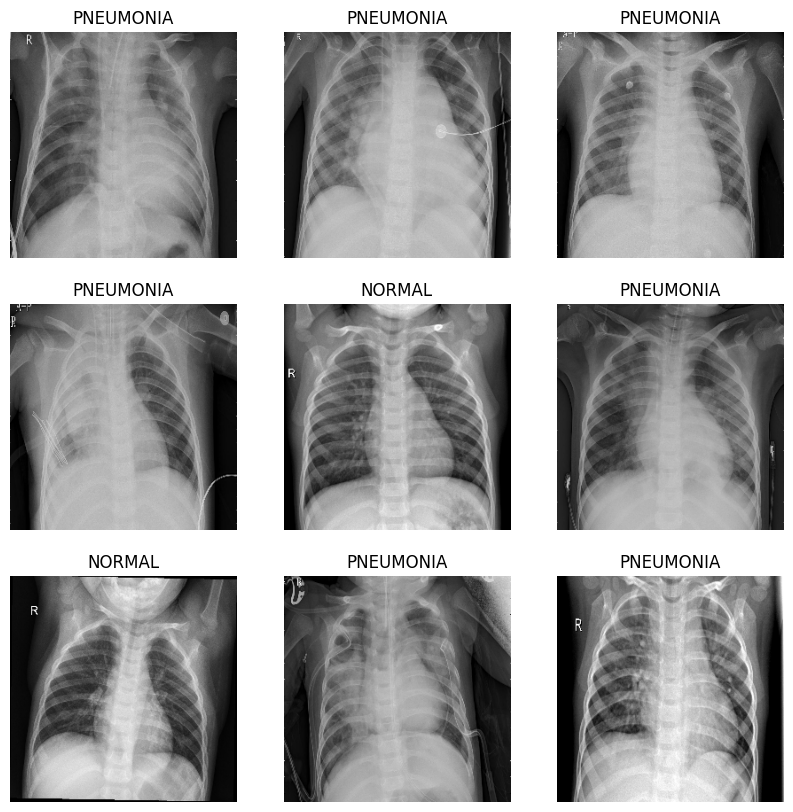

In [ ]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names # stores the class lables for plotting

plt.figure(figsize=(10, 10)) # size of the images

for images, labels in train_ds.take(1): # takes one batch only and gets that batchs images and lables
    for i in range(9): # iteriats through 9 imags of the batch
        ax = plt.subplot(3, 3, i + 1) # where creats a 3 by 3 grid and use i to place the next image
        plt.imshow(images[i].numpy().astype("uint8")) # gets the iteration of that image and displayes it
        plt.title(class_names[labels[i]]) # makes it human readable converting the 0 and 1 into normal and pmeumonia
        plt.axis("off") # removers axies lines and ticks around the image for more cleaner visualisation

plt.show() # shows the images

Modles architectur section:

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import GlobalAveragePooling2D # packeges for CNN modle

#sequential CNN architectur is defined
model = Sequential([
    Conv2D(32, (3, 3), activation='relu'),  # first layer of the modle where it learns edges and textures featuers of the images
    MaxPooling2D((2, 2)), #used to make the immage smaller and keeps the best valule from that image size which is 2x2

    Conv2D(64, (3, 3), activation='relu'), # learn more complex pattern like lung regioun and texture patterns
    MaxPooling2D((2, 2)),#used to make the immage smaller and keeps the best valule from that image size which is 2x2

    Conv2D(32, (3, 3), activation='relu'), # learns higher level feature extraction like patch or clear lungs
    GlobalAveragePooling2D(), #  summarises the features into a smaller set of numbers

    Dense(128, activation='relu'), # conbindes  all learnd feetuers from previoues layers to make a classification decison
    Dropout(0.5), # reduces overfitting by not making the modle memorise the tranning images

    Dense(1, activation='sigmoid') # output for the probitly between NORMAL and PNEUMONIA with 0 and 1
])

model.compile(optimizer='adam', # tranning method for updating weights
              loss='binary_crossentropy', # tells the modle how to measuer its mistake(for this one its binary as there are only 2 possible classes)
              metrics=['accuracy', # matrices of accuaracy
              tf.keras.metrics.AUC(name='auc'), # matrices for auc
              tf.keras.metrics.Precision(name="precision"),# matrices for precision
              tf.keras.metrics.Recall(name="recall")]) # matrices for auc# matrices for recall
model.summary() # prints architecture, shapes, and parameter counts and confirms modle strcutere and complexity


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for images, labels in train_ds.take(1):
    print("training: batch,size, channle:",images.shape)

for images, labels in test_ds.take(1):
      print("test: batch,size, channle:",images.shape)


training: batch,size, channle: (32, 256, 256, 3)
test: batch,size, channle: (32, 256, 256, 3)


Fit and evaluate section

In [ ]:
history = model.fit(  # trianing the modle with 3 epochs and showing accuacary,auc and loss for each epoch
    train_ds,
    epochs=3
)

Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 284ms/step - accuracy: 0.6835 - auc: 0.4961 - loss: 1.1467 - precision: 0.7341 - recall: 0.8877
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 202ms/step - accuracy: 0.8726 - auc: 0.9157 - loss: 0.3341 - precision: 0.9059 - recall: 0.9221
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step - accuracy: 0.9097 - auc: 0.9514 - loss: 0.2464 - precision: 0.9496 - recall: 0.9251


In [ ]:
resulte = model.evaluate(test_ds,return_dict=True)# evaluating the modle on unseen data

for metric, value in resulte.items():
    print(f"{metric}:  {round(value,4)*100}") #

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.5078 - auc: 0.5459 - loss: 1.3525 - precision: 0.3583 - recall: 0.6189
accuracy:  72.6
auc:  82.5
loss:  77.17
precision:  71.6
recall:  93.08


### Discussion of the experiment



This experiment utilised a basic three-layer CNN architecture trained on the Pneumonia Chest X-ray public dataset from Kaggle. This dataset consists of 5,856 chest X-ray images that are either normal or Pneumonia chest X-rays.

**Data preprocessing:**

Before discussing preprocessing in this experiment, we need to clarify the type of preprocessing that will be performed. The college's claim states, "We can classify the raw X-ray image data directly". This means that no preprocessing will be applied unless necessary for the model's computation.
Furthermore, this experiment utilises a tensor, which some researchers include as part of the preprocessing in a general, broad computational sense. However, in the context of image preprocessing, a tensor will not be treated as a preprocessing step as it is a "multi-dimensional array of numerical values and therefore generalises matrices to multiple dimensions"(Rabanser, Shchur and Günnemann, 2017).

With this clarification in mind, the following section outlines the minimum data preprocessing applied in the experiment. The only form of preprocessing applied was image resizing. However, resizing was applied because CNN models will not compute without a fixed image size. Additionally, in the experiment, we attempted to eliminate any manual resizing that was present in the model and dataset preparation by commenting and removing it. Despite this, removing them did not stop any form of resizing being done, as even when the manual resizing is taken out, there is automatic resizing being applied through the```from tensorflow.keras.utils import image_dataset_from_directory``` which does automatic resizing of the X-ray images to 256 x 256. This automatic resizing can be proven with this line of code:

```
for images, labels in train_ds.take(1):
 print("training: batch,size, channle:",images.shape)

for images, labels in test_ds.take(1):
 print("test: batch,size, channle:",images.shape)

```
This line of code outputs the batch size, the size (WxH) of the images, and the number of channels for both the test data and the training data. With this, we can determine that if raw, unprocessed image data were being fed even after taking out all the manual resizing, it would output this error message ```ValueError: Shapes of all inputs must match```.

**the model's architecture:**

As stated at the beginning of the discussion, this experiment was conducted on a simple 3-layer Convolutional Neural Network, where it utilised ```GlobalAveragePooling2D()``` for reducing overfitting. Prior to this, we were using ```Flatten()```, which increased overfitting due to the larger number of parameters it generated. Furthermore, ```Flatten() ``` made the model memorise the training data, which inflated the performance of the model artificially. In addition, we removed``` Rescaling(1./255, input_shape=(224, 224, 3))``` as it counts as preprocessing in a technical sense because it rescales images, which goes against the experiment.
Furthermore, the three layers of the model had different depths, where the first layer had 32 filters of size 3×3 and was tasked with learning low-level features, such as edges, contours, and basic texture patterns, that were present in the chest X-Ray. Furthermore, the second layer increases the number of filters to 64 and learns more complex patterns, such as lung regional features. The final layer reduces the filters to 32 and learns more complex layers. The next part of the architecture of the CNN includes``` Dense(128, activation='relu') ``` and ```Dropout(0.5)```. This is where the CNN model uses the ```dense()``` function to combine all the extracted features, allowing the model to make a classification based on the relationships between those features. At the same time,````Dropout()```` is used to disable 50% of the neurons, which prevents the model from memorising the training data. Another part of the architecture is ```` Dense(1, activation='sigmoid')````, which is used to do binary classification of 0 and 1 to determine how likely the image is to have pneumonia. Furthermore, there is a ````model.compile () ```` which has ````optimizer='adam' ````,`````loss='binary_crossentropy' ````` and `````metrics=['accuracy', AUC, Precision,Recall]````` inside for gradient-based optimisation, appropriateness for two-class classification and more precision and comprehensive of the image data.

**Fit and evaluation of the model:**

The CNN model was trained for three epochs and evaluated on the testing data, where it performed very well, achieving a high recall score of **93.08%**, a precision of **71.6%**, a high accuracy of **72.6%**, and an AUC of **82.5%**.

This overall independent experiment suggests that the college's claim of ***we can classify the raw x-ray image data directly; it should be possible to get improved performance, and save on staff time, without any downsides*** could be partly wrong. The reason for this is because we could not classify raw data directly, as there was automatic preprocessing being done from the ```from tensorflow.keras.utils import image_dataset_from_directory``` . In addition to this, it would mean that the claim of  ***should be possible to get improved performance*** may be wrong as well, because, as much as the Convolutional Neural Network performed well. It performed well on preprocessed data, which limits the support for this section of the claim.

### comparison of the experiment and the papers

Having evaluated the performance and limitations of the CNN model in an independent experiment. The following section will compare the experiment to reported papers that were discussed in **Performance Evidence(Paper vs Paper)** to see if the experiment aligns or goes against these papers and how it affects the college's claim in terms of validilty.

The first paper to be compared with the experiment is the CNN paper, which focused on the automatic classification of X-ray images. The objective of the experiment in the paper was to **use deep learning approach to predict 14 categories of diseases.** (Mondal, Agarwal and Rashid, 2019). The model that was being used was a **"pre-trained model called Xception, which is based on depthwise seperable convolutional layers [14]. It is a deep convolutional neural network which is trained on a popularly large dataset known as ImageNet which enables the network to classify images with good accuracies."** (Mondal, Agarwal and Rashid, 2019.). Although the model is pre-trained, the researchers stated during the implementation section that  **We didn't used weights as ImageNet for the network.**(Mondal, Agarwal and Rashid, 2019). This implies that, throughout the entire experiment, they did not utilise the ImageNet dataset, meaning they trained and tested the model from scratch on X-ray image data rather than using ImageNet weights. In addition, they used a public dataset **"NIH Clinical Centre, which is one of the largest publicly available datasets of X-rays for research purposes"**(Mondal, Agarwal, and Rashid, 2019). It consists of 112,120 X-ray images with disease labels from 30,805 unique patients, which contain various information about the patients and common thorax diseases. From this information, the researchers only utilised  5% of the data, which consists of 5,606 images, each with a size of 1024 x 1024 pixels.

The researchers in this paper applied various preprocessing steps, which included dropping the 'no finding label' as it served no purpose in the research. Additionally, one-hot encoding was used for better performance, and data augmentation was utilised to mitigate overfitting. Furthermore,  they have normalised the pixel intensities of input images instead of using raw pixel values. Additionally, resizing was performed to reduce the image size from 1024x1024 to 128x128, to allow the model to process data more efficiently. Finally, the data was split into 75:25 for testing and training, where they used AUC and an accuracy metric to evaluate the model's performance.
After evaluating the model, the highest AUC score was **0.83** and the lowest AUC score was **0.38**. Additionally, they trained the model on 28 epochs, achieving a final accuracy of **88.76%**.


When compared with the results obtained in the independent experiment, several key differences emerge in terms of preprocessing, model complexity, and reported performance. The key difference is that the individual experiment used only resizing to make the data as raw as possible. In the paper, they used several preprocessing operations to maximise model performance, such as normalising the pixel intensities, resizing and one-hot encoding. This means the paper did not use raw data and heavily relied on preprocessing to obtain a high accuracy and AUC score. Also, the dataset used in this paper was significantly larger than the individual experiment, which had only two classifications (Normal and Pneumonia), whereas the paper had 15 classifications.

Additionally, the paper achieved a high accuracy of **88.76%** and a range of  AUC values from **0.38** to **0.83**. In comparison, the individual experiment achieved an accuracy of **72.6%** and an AUC of ***82.5%**, which is considered a strong performance for a basic CNN architecture.

Furthermore, the mixed range of AUC values could be due to the large datasets contributing to the wide AUC range, as well as the complex model's multiple-label classification.
The information from the paper and the individual experiment indicates that some form of preprocessing is needed for large and small datasets, which therefore renders the college's claim of **"we can classify the raw x-ray image data directly; it should be possible to get improved performance"**, insufficient as neither the research paper or the individual experiment support high performance without using preprocessing.


In another comparison with the experiment, a paper used a manual feature extraction technique called Speed Up Robust Features(SURF) to extract features from a neural network called  Multilayer Perceptron classifier with a hyperparameter learning rate. This model was categorised on the Pneumonia disease and determined the level of accuracy. In addition, **Image preprocessing guarantees that all of the photos are in the same format and are free of noise that is irrelevant to the study**(Ula, Muhathir and Sahputra, 2022). This indicates that some form of preprocessing has been done to the images. Furthermore, they used SURF grayscale to minimise the colour space in the image by converting the RGB into a single colour space, which is then stored as a pattern model. This pattern model will then be used for the testing phase. After the pattern model is trained, it will be matched using the Multilayer Perceptron method. Furthermore, the model will be trained on 100 epochs and then classified on different learning rates. Finally, after the classification, the model produced three tables that provide values for Recall, Precision, F1-score, learning rate, and accuracy. These reusults variyed **Based on the results of the experiments, the accuracy, precision, recall, and f1-score obtained arelatively stable value, with the lowest accuracy value being 78.4% and the highest accuracy value being 82.8%, the lowest precision value being .80.5% and the highest precision value being 82.8%, the lowest recall value being 78.4% and the highest recall value being 82.8%, the lowest f1-score being 76.4% and the highest f1-score being 82.8%.**(Ula, Muhathir and Sahputra, 2022)

When compared with the results obtained in the independent experiment, some similarities and differences come up. One similarity is the dataset, as both the research paper and the individual study use the same Chest X-Ray Images (Pneumonia), but from different versions. This can be indicated by the number of images used in the paper (5,863 X-ray images) and the individual experiment (5,856 X-ray images). This slight difference will not affect the comparison, as the individual experiment had seven images fewer than the research paper. Furthermore, research papers and individual experiments used preprocessing techniques, as the paper states that **Image preprocessing guarantees that all photos are in the same format and are free of noise, irrelevant to the study**. This indicates that the paper utilised some form of image preprocessing to run the Multilayer Perceptron classifier.

On the other hand, the individual experiment used minmule preprocessing to run the model. Furthermore, as both the experiment and the research paper utilised a deep learning model with identical data. The paper obtained results for accuracy, precision, recall, and F1-score in the range of 76.4% to 82.8%. While the exerpiment used had an accuaracy of 72%, AUC of 82%, precision of 71.6% and recall of 93.08%, the comparative analysis between the experiment and the research paper suggests that the claim of **Instead of non-medical staff trying to extract relevant measurements from x-rays manually, we can classify the raw x-ray image data directly;** is insufficient, as neither the research paper nor the individual experiment supports high performance without using preprocessing.

The last comparison with the individual experiment is on Local Binary Pattern(LBP), where it was used for the detection of COVID-19 on computed tomography(CT) images. This was achieved by merging three datasets to efficiently classify pneumonia and healthy individuals for COVID-19 detection. Before the training process, the data was preprocessed by **resizing the images to 224 by 224, also, several data augmentation such as random reflection, random rotation, random rescale, random translation along X‐axis and random translation along Y‐axis was performed to increase the number of images, improves training and to reduce overfitting**(Mubarak et al., 2021).

The training of this study was conducted in stages, with the utilisation of KNN and SVM classifier models. The first stage involved extracting textural features using LBP, with which the two models are then classified. In the second stage, high-level deep features were extracted from seven pre-trained models and used to train KNN and SVM. Additionally, the last pooling layer of each of the pre-made models was utilised to train the two classifier models. The third stage involved concatenating LBP features and features from pre-made models, and then classifying them using two classifier models. The result given with the three classes of the CT scan images of COVID-19 where the data was indvidule class of pneumonia and healthy individuals were classified using the SVM classier and LBP features as inputs gave an accuracy of **97.5% sensitivity of 98.7% a specificity of 96.1%, F1 score of 97.5%, the precision of 96.4%, Yonden index of 94.8% and AUC of 97.4%.**(Mubarak et al., 2021). This model outperformed the KKN model, which used the same dataset and LBP features as input.


When compared with the results obtained in the independent experiment, some differences and similarities emerge, as the paper used two supervised learning models (SVM and KNN). Moreover, the experiment used a simple deep learning model architecture. In addition, both the experiment and the research paper used different datasets, with the research paper using three datasets that **"were merged to efficiently classify COVID-19, common pneumonia and healthy individual"**(Mubarak et al., 2021). On the other hand, the individual experiment utilised a single large image dataset. Furthermore, the individual research classified X-ray images, while the paper classified computed tomography (CT) images, which are used to detect different features in the body. However one simlialrty was that both the paper and the indivudle experimet was minmule or heavy preprocessing as the paper states **Before training, the data was preprocessed by resizing the images to 224 by 224, also, several data augmentation such as random reflection, random rotation, random rescale, random translation along X-axis and random translation along Y-axis was performed to increase
the number of images, improves training and to reduce overfitting** (Mubarak et al., 2021). This suggestion also indecates that preprocessing is need for classifaction modles and deep learning modles. This then makes the college's claim of **"Instead of non-medical staff trying to extract relevant measurements from x-rays manually, we can classify the raw x-ray image data directly;"** as insufficient, as neither the research paper nor the individual experiment supports high performance without using preprocessing.


# Computational and Workflow Costs

This section will focus on the workflow and computational cost that the individual experiment and the papers show for the college's claim of ***"Instead of non-medical staff trying to extract relevant measurements from x-rays manually, we can classify the raw x-ray image data directly; it should be possible to get improved performance, and save on staff time, without any downsides***. In addition, we shall use the evidence in the paper vs paper section and individual experiment vs paper section to justify the computational and workflow cost of the college's claim.



### Workflow cost for feature extraction and Deep Learning modles:


To assess the validity of the college's claim, it is essential to consider the computational and workflow costs associated with classifying X-ray images using deep learning models versus manual feature extraction approaches. As stated in the papers, they consistently used some form of preprocessing before classifying and evaluating the model. Additionally, preprocessing can vary depending on the researcher's objective, as well as the data and model being used. An example of this is the individual experiment where automated resizing was used to classify the CNN model, allowing it to process the classification. This demonstrates that raw image data still requires preprocessing before classification. However, the automated preprocessing for the images will save time when it comes to resizing. In contrast, if the experiment were to use more complex preprocessing, such as augmentation, then there would be a computational and workflow cost.

In the manual feature extraction papers, researchers had to use multiple steps, such as preprocessing, feature extraction, and then classification. This process is a workflow cost as feature extraction requires many steps before it can be classified. An example of this is in the Optimization of Multilayer Perceptron Hyperparameter in Classifying Pneumonia Disease Through X-Ray Images with Speeded-Up Robust Features Extraction Method paper. This paper involved preprocessing as stated in  **Image preprocessing guarantees that all photos are in the same format and are free of noise irrelevant to the study** (Ula, Muhathir, and Sahputra, 2022). Next, they had to extract the features by using SURF as stated **the first is the training process, namely the process of extracting data (grayscale to minimize the color space in the
image from three color spaces R, G, B into one color space,
namely grayscale and extracting by utilizing the SURF feature).**(Ula, Muhathir and Sahputra, 2022). The final step was classification **The classification process using a multilayer perceptron was tested with variations in the learning rate**(Ula, Muhathir and Sahputra, 2022). This indicates that there is a workflow cost due to the time-consuming process of using manual feature extraction techniques in the classification of X-ray data.

In terms of CNN, the workflow cost example will be from the Deep Learning Approach for Automatic Classification of X-Ray Images using Convolutional Neural Network, where the paper said that  **"We have run our CNN model on Tesla K80 GPU"** (Mondal, Agarwal and Rashid, 2019). This is a workflow cost, as the experiment will require external hardware(Tesla K80 GPU) that necessitates human effort for implementation. Furthermore, it will require access to GPU software, which requires implementation and configuration. Furthermore, the GPU will require hardware compatibility, which is both time-consuming and technically challenging.

Additionally, another workflow cost arose from the individual experiment, where the use of the number of epochs is a computational cost. Futheremore The training time of the model comes with a workflow cost associated with the number of epochs. This can be demonstrated by the experiment, which utilised three epochs to train 5,856 X-ray images that underwent minimal preprocessing. The total time cost to train the images on three epochs using a simple CNN architecture was 30 to 40 minutes. This training time has impacted the research cycle, resulting in a loss of research time.


### Computational cost for feature extraction and Deep Learning modles

 When it comes to computational cost for Convolutional Neural Networks, it is related to the filters. An example of this is in the experiment, where we used different filters, such as 32 and 64 filters, which increased the computational cost due to the larger number of parameters that needed to be learned, thereby consuming more computational resources, like CPU and RAM.

Furthermore, another computational cost will be the dataset. An example is in the Deep Learning Approach for Automatic Classification of X-Ray Images using Convolutional Neural Network paper. This paper used a **"112,120 X-ray images with disease labels from 30,805 unique patients."**(Mondal, Agarwal and Rashid, 2019). This use of a large dataset requires a significant amount of RAM and training time.

When it comes to computational cost, the SURF paper states that **"to determine the optimal level of accuracy on the multilayer perceptron in classifying Pneumonia with condition 100 epochs**.(Ula, Muhathir and Sahputra, 2022). This use of 100 epochs at different learning rates is significantly computational as the data will be passed through the model 100 times before evaluation, compared to a single end-to-end CNN training process with fixed hyperparameters.

The final computational cost is in the Local binary pattern and deep learning feature extraction fusion for COVID-19 detection on computed tomography images. This paper uses feature extraction in multiple stages. As stated in the paper **the first stage, textual features were extracted using LBP and were classified by KNN and SVM**(Mubarak et al., 2021).  This stage begins by extracting features using LBP. In the second stage, they start extracting features from the seven pre-trained models. This is stated in the paper, where it is noted that **in the second stage, high-level deep features were extracted from each of the seven pre-trained models**(Mubarak et al., 2021) and then in the final stage they are **"the third stage the LBP features and features extracted from each of the seven pre-trained networks are concatenated then classified using the two classifiers"** (Mubarak et al.,2021) this stage is when the feature extraction is used. This indicates that there is a computational cost, as the feature extraction LBP is done in the first stage and then reused in a later stage. The computational cost arises from concatenation, as the models will encounter longer vectors, which will then require more time to compute. The reason is that the model will need to process more values for each image, which increases the computational requirements during both training and prediction.

# Critical Analysis of the colleges Claim


In this section we will analysis the claim by braking it into parts to see each part spreatly and understanding which partes of the claim are true, partly true and false based on the evidence collected throughtout the notebook.

### Critical Analysis of the Claim of "We can classify the raw x-ray image data directly":

This section is misleading  as both manual feature extraction  papers did use some  form of preprocessing, as stated in this section of one of the papers **"Image
preprocessing guarantees that all of the photos are in the same
format and are free of noise that is irrelevant to the study"** (Ula, Muhathir, and Sahputra, 2022). Moreover, the CNN paper employed heavy preprocessing, known as data augmentation. This can be proven with this argument that was stated in **"We have implemented various data augmentation techniques on this large dataset"**(Mondal, Agarwal and Rashid, 2019). Futheremore the second feature extraction paper used heavy preprocessing as well as stated in this section **"several data augmentation such as random reflection, random rotation, random rescale, random translation along X-axis and random translation along Y-axis was performed"**(Mubarak et al., 2021). Finally, the addition of the individual experiment, which attempted to use no preprocessing to test the theory of this section of the claim, was partly unsuccessful. The reason this was unsuccessful was that preprocessing was not implemented directly or manually in the experiment. However, the use of ``from tensorflow.keras.` utils import image_dataset_from_directory` ``performed indirect automatic preprocessing by resizing to 256 x 256, allowing the simple CNN architecture to compute. If the ```from tensorflow.keras.utils import image_dataset_from_directory``` did not add the automatic preprocessing of resizing, then the console would have output this error message: ```ValueError: Shapes of all inputs must match```.

 The information that is provided and proven by the research paper and the individual CNN experiment demonstrates that this section of the claim "We can classify the raw x-ray image data directly" is misleading, as one of the papers does preprocessing to make sure that the classification is related to their study and can not hinder their results as well. On the other hand, the second paper performs preprocessing to improve training and reduce overfitting. Finally, the individual experiment proves that classification of raw image data can not be done without at least the minimum required preprocessing, such as resizing, which was applied automatically.

### Critical Analysis of the Claim of "It should be possible to get improved performance":

This section of the claim is debatable, as performance increases can vary depending on the dataset, the amount of preprocessing used, and the model's complexity. An example of this is an experiment that used minimal preprocessing on a basic CNN architecture, which gave an accuracy of **72.6%**, AUC of **82.5%**, precision of **71.6%**, and recall of **93.08%**. This performance was possible with a basic CNN and a small dataset of 5,856 chest X-ray images. On the other hand, the CNN paper used a dataset that **" is comprised of 112,120 X-ray images with disease labels from 30,805 unique patients"**(Mondal, Agarwal and Rashid, 2019). This type of dataset is large and requires heavy preprocessing( as stated in the previous critical analysis section).
Furthermore, the model used in this research paper was called Xception **"based on depthwise seperable convolutional layers [14]. It is a deep convolutional neural network"**(Mondal, Agarwal and Rashid, 2019). The Xception model achieved an accuracy of 88.76% and a varying AUC score ranging from 0.38 to 0.83.  These results indicate that performance improvements are possible, but they are not inherent to direct image classification and depend on experimental design choices.


Furthermore, the feature extraction paper yielded different results due to very different research objectives. An example is the LBP paper, which used classifier models (KNN and SVC) to classify CT images. However, they were still relying on deep learning models as stated here **"In this study, KNN and SVM classifiers were trained using handcrafted LBP extracted features and seven pre-trained deep learning (i.e., CNN) models extracted features for COVID-19 detection"**(Mubarak et al., 2021). Furthermore, they utilised three datasets with three stages for training the model, using feature extraction from LBP in the first stage and deep high-level feature extraction in the second stage. The final stage involved concatenating LBP features with those from the deep learning models. Furthermore, they also applied heavy augmentation and resizing.
Both classifiers where given the same data that was preprocessed and the same LBP featuers as it was stated here **In Table 2, SVM and KNN classifiers performance were compared to determine the best performing model with LBP features as inputs**(Mubarak et al., 2021) where the SVM gave **SVM achieves an accuracy of 97.5% sensitivity of 98.7% a specificity of 96.1%, F1 score of 97.5%, the precision of 96.4%, Yonden index of 94.8% and AUC of 97.4%. The SVM, as shown in Figure 3 outperformed the KNN in terms of accuracy, sensitivity, specificity, F1 score, precision, Yonden index and AUC**(Mubarak et al., 2021). The paper also discusses the concatenation of the LBP and deep learning features. This can be proven with this statement in the paper **" In this study, the LBP and CNN features were extracted and then concatenated, the KNN and the SVM classifiers were trained using these concatenated features. In Tables 5 and 6, the results of the SVM and KNN classifiers were presented respectively.**(Mubarak et al., 2021). For this classification, the KNN performed better than the SVM. This can be proven with this statement **the KNN classifier trained with VGG-19 + LBP features shows superiority in terms of preformance as it achieves an accuracy of 99.4%, a sensitivity of 99.3%, a specificity of 99.3%, F1 score of 99%, precision of 98.8%, Yonden Index of 98.6% and AUC of 99.3.%**(Mubarak et al., 2021).

In terms of the SURF paper, they used the Learning rate hyperparameter. Furthermore, they have used some form of image preprocessing as stated in the previous section. Furthermore, they used the publicly available chest X-ray pneumonia dataset, which comprises 5,863 X-ray images. Additionally, a Multilayer Perceptron model is used for classification. Additionally, they utilised the SURF algorithm to extract the data. this can be backed up  as it was stated in the paper by saying **"first is the training process, namely the process of extracting data (grayscale to minimize the color space in the image from three color spaces R, G, B into one color space, namely grayscale and extracting by utilizing the SURF feature) data is stored as a pattern model that will be used in the testing phase,"**(Ula, Muhathir and Sahputra, 2022). After extraction and storeg there was the  **"matching the pattern model that has been trained by utilizing the Multilayer perceptron method as a classification."** (Ula, Muhathir and Sahputra, 2022). After this the model was classifed at diffrentl leraing rate which gave **the lowest accuracy value being 78.4% and the highest accuracy value being 82.8%, the lowest precision value being .80.5% and the highest precision value being 82.8%, the lowest recall value being 78.4% and the highest recall value being 82.8%, the lowest f1-score being 76.4% and the highest f1-score being 82.8%.**(Ula, Muhathir and Sahputra, 2022).

From this information provided we can confidintly say that collges claim of **"It should be possible to get improved performance"** can be determind on what model they are using ( a deep learning modle(CNN, MLP) or a classifaction modle(KNN, SVM)), the datasize, the type of data they are using(an exmple will be the SURF paper that used X-ray images and LBP paper that used CT images), the trainng method( are they doing data extraction like in  SURF paper are they the using conctiantion of LBP feaurers and deep learning modles featuers that was used in the LBP paper). However, one thing in common with all the papers and individual experiments was the use of preprocessing to improve performance.

This section concludes that the claim is valid only when appropriate data, preprocessing strategies, and model complexity are carefully aligned with the research or experiment being carried out.

### Critical Analysis of the Claim of "Save on staff time":

The claim on **Save on staff time** can be made during the classification of models and training, as these are automatically done by the model itself without human intervention. An example of this is the individual experiment, where the model computed the training and evaluation automatically without any intervention from individuals. However, during the classification of some papers, they have to train more than one model and evaluate it on multiple models. An example is the LBP paper, which used two classifiers (KNN and SVM) for training and evaluation. This does not save time, as the workload is doubled, which means it will take twice as long to classify both models, evaluate both models, and analyse the results of both models.

However, there are many steps where staff time cannot be saved. An example of this is the training where, during the CNN paper, they stated **"We have run our CNN model on Tesla K80 GPU"** (Mondal, Agarwal, and Rashid, 2019). This is a time-consuming process, as they must ensure the hardware is compatible with the rest of the system they are using, which is also time-consuming in itself. The second example is preprocessing, which takes time, as models like deep learning models require a minimum amount of preprocessing so that they can compute. This indicates that staff time will be utilised regardless of the deep learning model used. Furthermore, staff time will be used during the tuning of hyperparameters, as seen in SURF, where they had to adjust various learning rates for the model to complete the research.

This information concludes that saving on staff time can only occur after the experiment or during the model's computation, as the model will perform learning and prediction without requiring user intervention. This is because it updates the parameters through the learning algorithm and makes predictions after training by automatically assigning labels to images. However, staff time is still required for preprocessing, hyperparameter tuning, and when training and evaluation are done on more than one classifier. Therefore, the claim that **"staff time can be saved"** is only partially supported, as it mainly applies to some sections of the experiment's cycle and not the whole experiment.


### Critical Analysis of the Claim of "Without any downsides"

This aspect of the claim is not supported when considered alongside previously analysed sections. As the previous claims have highlighted the downsides of certain sections of the whole claim, examples include the unavoidable nature of preprocessing, model configuration issues such as hyperparameter tuning, and workflows being interrupted due to hardware requirements. These factors contradict the claim that there is **"no downside"** and are not supported by the evidence collected and demonstrated in the notebook.

# Conclusion

This is where you would conclude your work on both tasks.

You should be able to get some text in place for task 1 quite quickly:

Example text for task 1: This investigation used a shuffled 60/40 train/test holdout split to evaluate the following models: [insert list of models]. It found that the ... model gave the strongest performance with a [insert name of performance metric] of ##.

You could then leave this section alone for a while as you work on adding more models to your investigation and improving your recipe. But eventually you need to come back and update it to reflect your final findings.

For task 2 you need to refer back to your earlier analysis work in order to make final judgements about each aspect of the claim. On balance, is your colleague right in what they are saying, or not? And finally, overall, do you think the claim should be pursued, versus the manual measurement process you investigated in task 1?

**If you're not able to make/conclude an analysis for task 2 you can still get a good mark for a properly concluded task 1 investigation**

## **TASK 1 CONCLUSION:**

This investigation used a shuffled 60/40 and 80/20 train/test holdout split to evaluate the following classifier models: DecisionTreeClassifier, KNeighborsClassifier, GaussianNB, RandomForestClassifier, SGDClassifier, and Support Vector Machine Classifier (SVC). Each model demonstrated both similarities and differences. A clear similarity was observed in the confusion matrices, where all models had a high number of true negative cases, indicating that they kept identifying most of the negative cases. Additionally, it suggests that the dataset is imbalanced, with a larger proportion of negative cases, which naturally results in a higher true negative score in the confusion matrix.

Ultimately, the best-performing model is RandomForest, as its base accuracy is 67.5%, which is considered one of the highest accuracies without any further improvements. However, with the added improvements of K-fold cross-validation, pipeline, clean data, and stratification, the accuracy increased to 69.2%, representing a 1.7% improvement in performance. Furthermore, the confusion matrix of the models showed a high true negative and a low true positive, indicating that the model leaned more towards the true negative class. In addition to the confusion matrix, the ROC curve demonstrated that the RandomForestClassifier can distinguish between positive and negative classes, as indicated by a ROC value of 0.77. Furthermore, the recall score of 84% and a precision score of 80% display that the model can detect most positive cases and strongly predict positive cases as actual positive cases. Compared to other models, Random Forest offers one of the best combinations of accuracy, ROC, precision, and recall, even where other models may have slightly higher values on individual metrics but lack consistency in overall performance.

The Random Forest Classifier hyperparameter tuning (n_estimators) also showed excellent results, achieving an ROC of 0.75 and the highest base accuracy of 71.4% at n_estimators of 40 and 60. In addition, the final hyperparameter version of the model, which incorporates k-fold cross-validation, pipelines, validation, stratification, shuffling, and clean data, achieves accuracy scores above 75% in fold four between n_estimators 0 and 5, resulting in a roughly 3.6% increase in performance.

Furthermore, this model's hyperparameters' performance is one of the highest when measured against other models' hyperparameters ROC values and confusion matrices, which output fewer true negatives and true positive values, alongside higher false negative and false positive values. Additionally, the n_estimators hyperparameter of the Random Forest model showed a higher precision and recall than other hyperparameter models, indicating a reduced risk of misclassification and more reliable identification of positive cases. Together, these results support the conclusion that Random Forest is the strongest model both as a base classifier and when optimised through hyperparameter tuning.

Regarding the best ensemble, it will have to be the VotingClassifier, as it demonstrated the best overall performance, even though it showed lower true negative values compared to the other ensemble (BaggingClassifier) in the confusion matrix. However, it achieved better precision and recall scores, indicating that it was more effective at identifying positive cases while maintaining control over misclassifications. Even though the votingClassifier accuracy is slightly lower, its ROC curve is the same as that of BaggingClassifiers, which indicates that both ensembles can distinguish between classes at a similar level.

The VotingClassifier with hyperparameter DecisionTreeClassifier (min_samples_split) and the RandomForestClassifier hyperparameter (n_estimators) also performed strongly, with min_samples_split achieving a recall of 92% and a precision of 74% and n_estimators achieving an 80% precision and recall score. Furthermore, the confusion matrix for min_samples_split displayed a lower true positive, which suggests that it had difficulty in identifying positive cases, as indicated by the lower positive variant in the dataset. Overall, these findings support the conclusion that the VotingClassifier is the best ensemble model.

In terms of which type of model is the best individual model and the most effective, it is the one that achieved the highest recall and precision in both hyperparameter and non-hyperparameter settings. Furthermore, the ROC is much higher in the non-hyperparameter version compared to the ensemble. However, a similar ROC value was obtained with the hyperparameter version of the individual model compared to the ensemble's two hyperparameter versions. This indicates that the individual model outperforms the ensemble model in terms of ROC values. In addition, the confusion matrix for the individual model is lower in terms of true positive cases and higher in true negative cases compared to the ensemble's final version, whereas it is the opposite. However, the hyperparameter version of the individual model is higher compared to both of the ensemble hyperparameter versions. Finally, the accuracy score for the ensemble is much higher compared to the individual model overall. Despite the high accuracy, it still had a lower or similar ROC score and lower true positive and true negative cases, which made it less reliable. This is why the individual model RandomForestClassifier should be used to make fast and reliable pneumonia diagnoses.

## **TASK 2 CONCLUSION**:

 This notebook critically analysed the college's claim that **Instead of non-medical staff trying to extract relevant measurements from x-rays manually, we can classify the raw x-ray image data directly; it should be possible to get improved performance, and save on staff time, without any downsides**. By comparing research papers, individual experiments, and analysing each section of the claim, it was found that the claim is partly supported. The reason for this is that machine learning models can classify image data, but with some restrictions. These restrictions were outlined across the research papers and individual experiments, with the requirement of a minimum level of preprocessing, such as image resizing, consistently required before classification. This necessity contradicts the claim to **classify the raw x-ray image data directly**.

Furthermore, the claim that **"It should be possible to get improved performance"** is debatable, as several factors must be considered, including data size, model type, training methods, preprocessing steps, and the type of model architecture to be used. An example of this is a complex CNN architecture, such as Xception, as described in the CNN Research paper, or a simple CNN, as seen in the individual experiment. With this understanding, "improved performance" depends on the suitability of both the model and the experimental design.

In addition, **saving on staff time** will only occur during the model's computation of training and evaluation, as the model updates its parameters through the learning algorithm and makes predictions after training by automatically assigning labels to images. However, steps such as preprocessing, model configuration, and training and evaluation of multiple models all require human intervention for the model to work. These evidence examples in the critical analysis section indicate that staff time can only be saved in certain aspects of the experiment's workflow.

Finally, the college's claim on **without any downside** is not supported by the evidence, as all the previous claims stated some form of negative aspect. An example of this negative aspect is that preprocessing is inevitable, and staff time will be required in certain aspects of the workflow. At the same time, performance outcomes are conditional on the researcher's objective and the experiment's design, rather than being guaranteed. These findings indicate that this aspect of the claim should be reconsidered in light of the evidence presented in the notebook.

Overall, the colleagues' claim is only partially supported, as automated image classification with models such as CNN can reduce manual involvement and achieve a reasonable performance output with varying degrees of preprocessing. In addition, performance improvements depend on factors such as dataset size, preprocessing, and model complexity, which cannot be guaranteed. Additionally, staff time can only be saved during certain phases of the experiment, indicating that staff time will be needed in certain aspects of the experiment, as stated in the analysis of sections of the claim. Overall, automated image classification cannot fully replace manual approaches and should be used as a complementary method, working alongside manual process aspects to improve performance and reduce staff time.    



# References

Ahmed, N.A. (2023) What is A Confusion Matrix in Machine Learning? The Model Evaluation Tool Explained, Datacamp.com. DataCamp. Available at: https://www.datacamp.com/tutorial/what-is-a-confusion-matrix-in-machine-learning (Accessed: 2 December 2025).Babu, A. (2025) Why Accuracy Isn’t Enough: A Guide to AI/ML Model Evaluation, Medium. Available at: https://medium.com/@aditib259/why-accuracy-isnt-enough-a-guide-to-ai-ml-model-evaluation-f97c0c394375 (Accessed: 2 December 2025).Banerjee, I. (2023) Imbalanced Data: is it all bad?, Medium. CodeX. Available at: https://medium.com/codex/imbalanced-data-is-it-all-bad-69e3d33f604d (Accessed: 17 November 2025).Brems, M. (2025) How to Handle Unbalanced Classes: 5 Strategies, Roboflow Blog. Available at: https://blog.roboflow.com/handling-unbalanced-classes/#:~:text=Dealing%20with%20unbalance%20classes%20is,biased%2C%20leading%20to%20inaccurate%20predictions. (Accessed: 3 December 2025).Evidently AI (2025) Accuracy vs. precision vs. recall in machine learning: what’s the difference?, Evidentlyai.com. Available at: https://www.evidentlyai.com/classification-metrics/accuracy-precision-recall#:~:text=Accuracy%20shows%20how%20often%20a,objects%20of%20the%20target%20class. (Accessed: 3 December 2025).Evidently AI Team (2025) How to Interpret a Confusion Matrix for a Machine Learning Model, Evidentlyai.com. Available at: https://www.evidentlyai.com/classification-metrics/confusion-matrix#:~:text=positives%20is%20600.-,True%20Negative%20(TN),correctly%20predicted%20it%20as%20negative. (Accessed: 14 November 2025).Fiddler (2025) Is accuracy a good measure of model performance? | Fiddler AI, Fiddler.ai. Available at: https://www.fiddler.ai/model-accuracy-vs-model-performance/is-accuracy-a-good-measure-of-model-performance#:~:text=In%20short%2C%20while%20its%20simplicity,of%20the%20model's%20true%20dependability. (Accessed: 3 December 2025).GeeksforGeeks (2017) Understanding the Confusion Matrix in Machine Learning, GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/ (Accessed: 15 November 2025).GeeksforGeeks (2020) Precision and Recall in Machine Learning, GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/precision-and-recall-in-machine-learning/ (Accessed: 9 December 2025).GeeksforGeeks (2024) Stratified Sampling in Machine Learning, GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/stratified-sampling-in-machine-learning/ (Accessed: 9 December 2025).Jain, A. (2024) Understanding Cross-Validation: Enhancing Model Evaluation, Medium. Available at: https://medium.com/@abhishekjainindore24/understanding-cross-validation-enhancing-model-evaluation-ccad3e19cde0 (Accessed: 9 December 2025).Kashyap, P. (2024) Understanding Precision, Recall, and F1 Score Metrics, Medium. Available at: https://medium.com/@piyushkashyap045/understanding-precision-recall-and-f1-score-metrics-ea219b908093 (Accessed: 3 December 2025).Kofo Orogun (2023) USING PIPELINES TO BUILD A MACHINE LEARNING MODEL, Medium. Available at: https://medium.com/@kofoorogun/using-pipelines-in-your-machine-learning-model-c89078d03d67 (Accessed: 2 December 2025).Kolli, A. (2024) The Power of Scikit-learn Pipelines: Streamlining Your Machine Learning Workflow, Medium. Available at: https://aravindkolli.medium.com/the-power-of-scikit-learn-pipelines-streamlining-your-machine-learning-workflow-8f4cb2e8e1df (Accessed: 2 December 2025).Shai Samana (2024) The Silent Killer of Predictive Models: Data Leakage, Pecan AI. Available at: https://www.pecan.ai/blog/predictive-models-data-leakage/ (Accessed: 9 December 2025).Staff, C. (2025) What Is ROC Curve in Machine Learning?, Coursera. Available at: https://www.coursera.org/articles/what-is-roc-curve (Accessed: 3 December 2025).Svitlana Glibova (2021) Avoiding Leakage with Pipelines, Medium. Analytics Vidhya. Available at: https://medium.com/analytics-vidhya/what-is-a-pipeline-anyways-e6a814d4888 (Accessed: 9 December 2025).

AI, J. (2025) Julius AI | AI for Data Analysis, Julius.ai. Julius AI | AI for Data Analysis. Available at: https://julius.ai/glossary/feature-engineering (Accessed: 25 November 2025).AnswerDotAi, I. (2020) Use Raw (image) Data Always Better for training?, fast.ai Course Forums. Available at: https://forums.fast.ai/t/use-raw-image-data-always-better-for-training/74277 (Accessed: 27 November 2025).Deep (2019) Introduction to SURF (Speeded-Up Robust Features), Medium. Available at: https://medium.com/@deepanshut041/introduction-to-surf-speeded-up-robust-features-c7396d6e7c4e (Accessed: 1 December 2025).Domino (2025) What is Feature Extraction? Feature Extraction Techniques Explained, Domino.ai. Available at: https://domino.ai/data-science-dictionary/feature-extraction (Accessed: 26 November 2025).Dremio (2024) Raw Data, Dremio. Available at: https://www.dremio.com/wiki/raw-data/#:~:text=Despite%20its%20advantages%2C%20raw%20data,refine%20and%20extract%20useful%20information (Accessed: 27 November 2025).GeeksforGeeks (2024) Managing HighDimensional Data in Machine Learning, GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/managing-high-dimensional-data-in-machine-learning/ (Accessed: 21 December 2025).GeeksforGeeks (2025) Manual vs Automated feature engineering, GeeksforGeeks. Available at: https://www.geeksforgeeks.org/data-science/manual-vs-automated-feature-engineering/ (Accessed: 25 November 2025).Guest Posts (2025) Turning Raw Image Data into Usable Inputs for AI Workflow - Aya Data, Ayadata. Available at: https://www.ayadata.ai/turning-raw-image-data-into-usable-inputs-for-ai-workflow/ (Accessed: 27 November 2025).Histogram Of Oriented Gradient - an overview | ScienceDirect Topics (2020) Sciencedirect.com. Available at: https://www.sciencedirect.com/topics/computer-science/histogram-of-oriented-gradient (Accessed: 1 December 2025).Ibomoiye Domor Mienye and Swart, T.G. (2024a) ‘A Comprehensive Review of Deep Learning: Architectures, Recent Advances, and Applications’, Information, 15(12), pp. 755–755. Available at: https://doi.org/10.3390/info15120755.Jaiswal, S. (2024) Multilayer Perceptrons in Machine Learning: A Comprehensive Guide, Datacamp.com. DataCamp. Available at: https://www.datacamp.com/tutorial/multilayer-perceptrons-in-machine-learning (Accessed: 15 December 2025).Kumar, R. (2025) Feature Extraction in Machine Learning: A Complete Guide, Datacamp.com. DataCamp. Available at: https://www.datacamp.com/tutorial/feature-extraction-machine-learning (Accessed: 22 November 2025).Mall, P.K. et al. (2023) ‘A comprehensive review of deep neural networks for medical image processing: Recent developments and future opportunities’, Healthcare Analytics, 4, pp. 100216–100216. Available at: https://doi.org/10.1016/j.health.2023.100216.manual) (2019) Is (manual) feature extraction outdated?, Data Science Stack Exchange. Available at: https://datascience.stackexchange.com/questions/62409/is-manual-feature-extraction-outdated (Accessed: 22 November 2025).Mienye, I.D. and Swart, T.G. (2024b) ‘A Comprehensive Review of Deep Learning: Architectures, Recent Advances, and Applications’, Information, 15(12), p. 755. Available at: https://doi.org/10.3390/info15120755.Milvus (2025a) Do deep learning algorithms automatically extract features?, Milvus.io. Available at: https://milvus.io/ai-quick-reference/do-deep-learning-algorithms-automatically-extract-features (Accessed: 21 December 2025).Milvus (2025b) Why is image preprocessing required?, Milvus.io. Available at: https://milvus.io/ai-quick-reference/why-is-image-preprocessing-required (Accessed: 23 December 2025).Mind Foundry (2023) How Machine Learning Models Fail, Mindfoundry.ai. Available at: https://www.mindfoundry.ai/blog/how-machine-learning-models-fail (Accessed: 29 November 2025).MOONEY, P. (2024) Checking your browser – reCAPTCHA, Kaggle.com. Available at: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data (Accessed: 3 January 2026).Mubarak, A.S. et al. (2021) ‘Local binary pattern and deep learning feature extraction fusion for COVID‐19 detection on computed tomography images’, Expert Systems, 39(3), pp. e12842–e12842. Available at: https://doi.org/10.1111/exsy.12842.Mustafa, Z. and Heba Nsour (2023) ‘Using Computer Vision Techniques to Automatically Detect Abnormalities in Chest X-rays’, Diagnostics, 13(18), pp. 2979–2979. Available at: https://doi.org/10.3390/diagnostics13182979.Mutlag, W.K. et al. (2020) ‘Feature Extraction Methods: a Review’, Journal of Physics: Conference Series, 1591(1591 012028), p. 012028. Available at: https://doi.org/10.1088/1742-6596/1591/1/012028.Nair, A. (2022) 3 Things You Need To Know Before Working With Images In Machine Learning | Towards Data Science, Towards Data Science. Available at: https://towardsdatascience.com/3-things-you-need-to-know-before-working-with-images-in-machine-learning-6a2ab6f6b822/ (Accessed: 28 November 2025).Olugbara, O.O., Adetiba, E. and Oyewole, S.A. (2015) ‘Pixel Intensity Clustering Algorithm for Multilevel Image Segmentation’, Mathematical Problems in Engineering, 2015, pp. 1–19. Available at: https://doi.org/10.1155/2015/649802.Rabanser, S., Shchur, O. and Günnemann, S. (2017) Introduction to Tensor Decompositions and their Applications in Machine Learning, arXiv.org. Available at: https://arxiv.org/abs/1711.10781 (Accessed: 3 January 2026).Sedaghatijoo, Z., Hosseinzadeh, H. and Sadeghi Bigham, B. (2025) Local Binary Pattern (LBP) Optimization for Feature Extraction, Arxiv.org. Available at: https://arxiv.org/html/2407.18665v1 (Accessed: 18 December 2025).Staff, C. (2025a) What Are Deep Learning Models? Types, Uses, and More, Coursera. Available at: https://www.coursera.org/articles/deep-learning-models (Accessed: 20 December 2025).Staff, C. (2025b) What Are Deep Learning Models? Types, Uses, and More, Coursera. Available at: https://www.coursera.org/articles/deep-learning-models (Accessed: 21 December 2025).team, N. (2025) Epochs vs iterations in machine learning: what’s the difference, Nebius.com. Available at: https://nebius.com/blog/posts/epochs-vs-iterations-in-machine-learning (Accessed: 15 December 2025).Ula, M., Muhathir and Sahputra, I. (2022) ‘Optimization of Multilayer Perceptron Hyperparameter in Classifying Pneumonia Disease Through X-Ray Images with Speeded-Up Robust Features Extraction Method’, International Journal of Advanced Computer Science and Applications, 13(10). Available at: https://doi.org/10.14569/ijacsa.2022.0131025.UNITX (2025) Explaining the Role of Hidden Layers in Machine Vision, UnitX. Available at: https://www.unitxlabs.com/layer-hidden-layer-machine-vision-system-role-explained/ (Accessed: 27 November 2025).Vikram Ramanarayanan et al. (2018) ‘Analysis of speech production real-time MRI’, Computer Speech & Language, 52, pp. 1–22. Available at: https://doi.org/10.1016/j.csl.2018.04.002.Wijesinghe, W.O.K.A.S. (210AD) Wijesinghe, A. (2016) Speed up Robust Features in Computer , Researchgate. Available at: https://www.researchgate.net/profile/Asiri-Wijesinghe/publication/311713532_Speed_up_Robust_Features_in_Computer_Vision_Systems/links/5856c1d908ae77ec37094154/Speed-up-Robust-Features-in-Computer-Vision-Systems.pdf.Wolfram (2026) Data Preprocessing - Introduction to Machine Learning, Wolfram.com. Available at: https://www.wolfram.com/language/introduction-machine-learning/data-preprocessing/ (Accessed: 2 January 2026).

Dutta, S. (2024) Designing Your Own Convolutional Neural Network (CNN) Model: A Step-by-Step Guide for Beginners, Medium. Available at: https://medium.com/@sanjay_dutta/designing-your-own-convolutional-neural-network-cnn-model-a-step-by-step-guide-for-beginners-4e8b57836c81 (Accessed: 31 December 2025).GeeksforGeeks (2020) An introduction to MultiLabel classification, GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/an-introduction-to-multilabel-classification/ (Accessed: 24 December 2025).Johns Hopkins Medicine (2025) CT Scan Versus MRI Versus X-Ray: What Type of Imaging Do I Need?, Hopkinsmedicine.org. Available at: https://www.hopkinsmedicine.org/health/treatment-tests-and-therapies/ct-vs-mri-vs-xray (Accessed: 9 January 2026).Mondal, S., Agarwal, K. and Rashid, M. (2019) ‘Deep Learning Approach for Automatic Classification of X-Ray Images using Convolutional Neural Network’, 2019 Fifth International Conference on Image Information Processing (ICIIP), pp. 326–331. Available at: https://doi.org/10.1109/iciip47207.2019.8985687.Mooney, P. (2018) Chest X-Ray Images (Pneumonia), Kaggle.com. Available at: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data (Accessed: 1 January 2026).Wolfram (2026) Data Preprocessing - Introduction to Machine Learning, Wolfram.com. Available at: https://www.wolfram.com/language/introduction-machine-learning/data-preprocessing/ (Accessed: 3 January 2026).

# Submission

Once you're ready to submit, you need to compress the whole of your 1CWK100 folder as a .zip file (no other compression formats), and upload it to Moodle. There are several ways to do this, but the instructions below offer a simple step-by-step guide:

*    **Make sure the output from any code cells you have added is showing (you can select 'Runtime' -> 'Run all' if you need to)**
*    Save your notebook (select 'File' -> 'Save')
*    Find your /1CWK100/ folder via the Google Drive web interface ([https://drive.google.com/](https://https://drive.google.com/))
*    Right-click on the /1CWK100/ folder, and select 'Download'. This will cause the folder to be compressed into a .zip file and then downloaded to your local machine.
*    Upload the resulting .zip file to the 1CWK100 submission point on Moodle.
*    (If the .zip is too large for Moodle, upload it to your University OneDrive instead, and upload a link to that copy on Moodle)

**We recommend testing these steps, and asking any questions you might have, well before the final deadline.**